In [ ]:
import numpy as np
import pandas as pd
import torch
import joblib
import os
import itertools
from tqdm.notebook import tqdm
import math
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm

import torchvision
from torchvision import transforms
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score
from train_cmnist_models import ImageColorizerUNet

from matplotlib import pyplot as plt
from operations import Intervention

In [ ]:
# Load the generated ColorMNIST data
data_dir = 'data/cmnist'

# Load the data
Dll_samples  = torch.load(f'{data_dir}/dll_samples.pkl')
Dhl_samples  = torch.load(f'{data_dir}/dhl_samples.pkl')
omega        = torch.load(f'{data_dir}/intervention_mapping.pkl')
Ill_relevant = list(omega.keys())
Ihl_relevant = list(omega.values())

# Load low-level U-Net model
ll_model_state = torch.load(f'{data_dir}/ll_model_unet.pth')
ll_model       = ImageColorizerUNet()
ll_model.load_state_dict(ll_model_state)
ll_model.eval()

U_ll_hat = torch.load(f'{data_dir}/U_ll_hat.pkl')

# Load high-level linear model
# hl_model = torch.load(f'{data_dir}/hl_model.pkl')
hl_model = joblib.load(f'{data_dir}/hl_model.joblib')  # ✅ Correct!
# hl_model = joblib.load(f'{data_dir}/hl_model.joblib') # Correct loading for sklearn

U_hl_hat = torch.load(f'{data_dir}/U_hl_hat.pkl')

print("Data loaded successfully!")
print(f"  - Low-level noise shape: {U_ll_hat.shape}")
print(f"  - High-level noise shape: {U_hl_hat.shape}")

# Add these at the top
D_LL, C_LL, P_LL = 'Digit', 'Color', 'Pixels'
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

Data loaded successfully!
  - Low-level noise shape: torch.Size([1000, 3, 32, 32])
  - High-level noise shape: torch.Size([1000, 1])


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


=== U_ll_hat Analysis ===
Shape: torch.Size([1000, 3, 32, 32])
Data type: torch.float32
Min value: -1.534301
Max value: 1.907977
Mean value: 0.000558
Std value: 0.114866


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9134457..1.324736].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8997711..1.2403109].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45708194..1.3963091].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85011697..1.5134566].


Non-zero elements: 3071992/3072000 (100.00%)

=== U_hl_hat Analysis ===
Shape: torch.Size([1000, 1])
Data type: torch.float32
Min value: -0.037578
Max value: 0.035715
Mean value: 0.000000
Std value: 0.009037
Non-zero elements: 1000/1000 (100.00%)


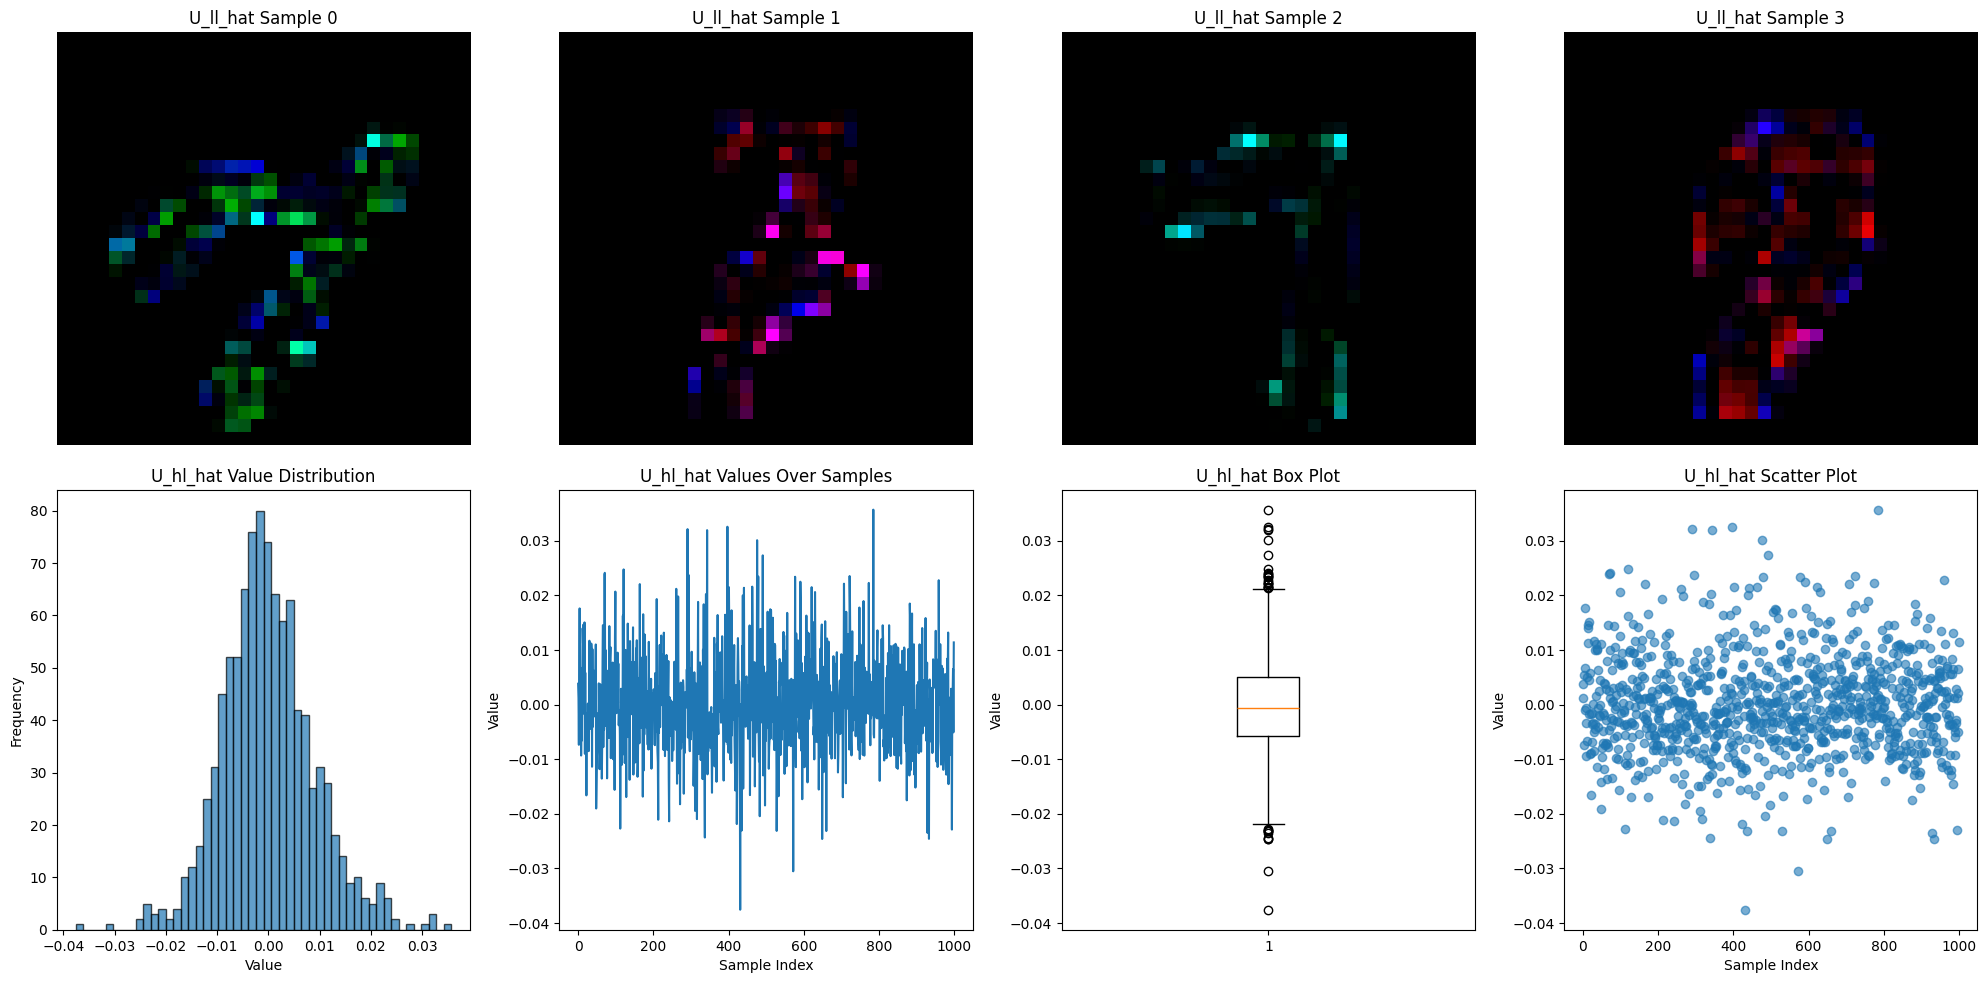


=== U_ll_hat Detailed Analysis ===
Per-channel statistics:
  Channel 0: mean=0.000991, std=0.125864
  Channel 1: mean=-0.001045, std=0.109210
  Channel 2: mean=0.001728, std=0.108673

U_ll_hat spatial statistics:
  Mean per pixel: 0.000558
  Std per pixel: 0.007610
  Zero percentage: 0.00%

=== U_hl_hat Detailed Analysis ===
Value range: [-0.037578, 0.035715]
Magnitude range: 0.037578
  Outliers (1.5*IQR): 33/1000 (3.30%)
  Near zero (<0.001): 98/1000 (9.80%)


In [ ]:
# Analyze U_ll_hat and U_hl_hat
print("=== U_ll_hat Analysis ===")
print(f"Shape: {U_ll_hat.shape}")
print(f"Data type: {U_ll_hat.dtype}")
print(f"Min value: {U_ll_hat.min().item():.6f}")
print(f"Max value: {U_ll_hat.max().item():.6f}")
print(f"Mean value: {U_ll_hat.mean().item():.6f}")
print(f"Std value: {U_ll_hat.std().item():.6f}")
print(f"Non-zero elements: {(U_ll_hat != 0).sum().item()}/{U_ll_hat.numel()} ({(U_ll_hat != 0).sum().item()/U_ll_hat.numel()*100:.2f}%)")

print("\n=== U_hl_hat Analysis ===")
print(f"Shape: {U_hl_hat.shape}")
print(f"Data type: {U_hl_hat.dtype}")
print(f"Min value: {U_hl_hat.min().item():.6f}")
print(f"Max value: {U_hl_hat.max().item():.6f}")
print(f"Mean value: {U_hl_hat.mean().item():.6f}")
print(f"Std value: {U_hl_hat.std().item():.6f}")
print(f"Non-zero elements: {(U_hl_hat != 0).sum().item()}/{U_hl_hat.numel()} ({(U_hl_hat != 0).sum().item()/U_hl_hat.numel()*100:.2f}%)")

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# U_ll_hat visualizations
# 1. Sample images from U_ll_hat
for i in range(min(4, U_ll_hat.shape[0])):
    ax = axes[0, i]
    img = U_ll_hat[i].permute(1, 2, 0).numpy()
    if img.shape[2] == 1:
        img = img.squeeze(2)
        ax.imshow(img, cmap='RdBu_r', vmin=-0.02, vmax=0.02)
    else:
        ax.imshow(img)
    ax.set_title(f'U_ll_hat Sample {i}')
    ax.axis('off')

# U_hl_hat visualizations
# 2. Histogram of U_hl_hat values
axes[1, 0].hist(U_hl_hat.numpy().flatten(), bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('U_hl_hat Value Distribution')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')

# 3. Line plot of U_hl_hat values
axes[1, 1].plot(U_hl_hat.numpy().flatten())
axes[1, 1].set_title('U_hl_hat Values Over Samples')
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Value')

# 4. Box plot of U_hl_hat
axes[1, 2].boxplot(U_hl_hat.numpy().flatten())
axes[1, 2].set_title('U_hl_hat Box Plot')
axes[1, 2].set_ylabel('Value')

# 5. Scatter plot of U_hl_hat
axes[1, 3].scatter(range(len(U_hl_hat)), U_hl_hat.numpy().flatten(), alpha=0.6)
axes[1, 3].set_title('U_hl_hat Scatter Plot')
axes[1, 3].set_xlabel('Sample Index')
axes[1, 3].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Additional analysis for U_ll_hat
print("\n=== U_ll_hat Detailed Analysis ===")
print(f"Per-channel statistics:")
for i in range(U_ll_hat.shape[1]):
    channel_data = U_ll_hat[:, i, :, :]
    print(f"  Channel {i}: mean={channel_data.mean().item():.6f}, std={channel_data.std().item():.6f}")

# Check for patterns in U_ll_hat
print(f"\nU_ll_hat spatial statistics:")
print(f"  Mean per pixel: {U_ll_hat.mean(dim=0).mean().item():.6f}")
print(f"  Std per pixel: {U_ll_hat.mean(dim=0).std().item():.6f}")

# Check if U_ll_hat is mostly zeros (like the Dll_samples)
zero_percentage = (U_ll_hat == 0).sum().item() / U_ll_hat.numel() * 100
print(f"  Zero percentage: {zero_percentage:.2f}%")

# Additional analysis for U_hl_hat
print("\n=== U_hl_hat Detailed Analysis ===")
print(f"Value range: [{U_hl_hat.min().item():.6f}, {U_hl_hat.max().item():.6f}]")
print(f"Magnitude range: {abs(U_hl_hat).max().item():.6f}")

# Check for outliers
q25, q75 = torch.quantile(U_hl_hat, 0.25), torch.quantile(U_hl_hat, 0.75)
iqr = q75 - q25
outlier_threshold = 1.5 * iqr
outliers = ((U_hl_hat < q25 - outlier_threshold) | (U_hl_hat > q75 + outlier_threshold)).sum().item()
print(f"  Outliers (1.5*IQR): {outliers}/{len(U_hl_hat)} ({outliers/len(U_hl_hat)*100:.2f}%)")

# Check if values are close to zero
near_zero = (abs(U_hl_hat) < 0.001).sum().item()
print(f"  Near zero (<0.001): {near_zero}/{len(U_hl_hat)} ({near_zero/len(U_hl_hat)*100:.2f}%)")


=== Background Pixel Analysis in U_ll_hat ===
Background threshold: 0.01
Background pixels found: 2441510/3072000 (79.48%)
Background pixel statistics:
  Min: -0.010000
  Max: 0.010000
  Mean: -0.004834
  Std: 0.001872

Edge pixels analysis:
  Edge pixels found: 384000
  Min: -0.169011
  Max: 1.777884
  Mean: -0.005203
  Std: 0.013686

Center vs Edge comparison:
  Center region (16x16): mean=0.008990, std=0.183216
  Top edge: mean=-0.002400, std=0.075973
  Bottom edge: mean=-0.001909, std=0.090650
  Left edge: mean=-0.002720, std=0.062369
  Right edge: mean=-0.002178, std=0.079740
  Overall edge: mean=-0.002302, std=0.077183


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9134457..1.324736].


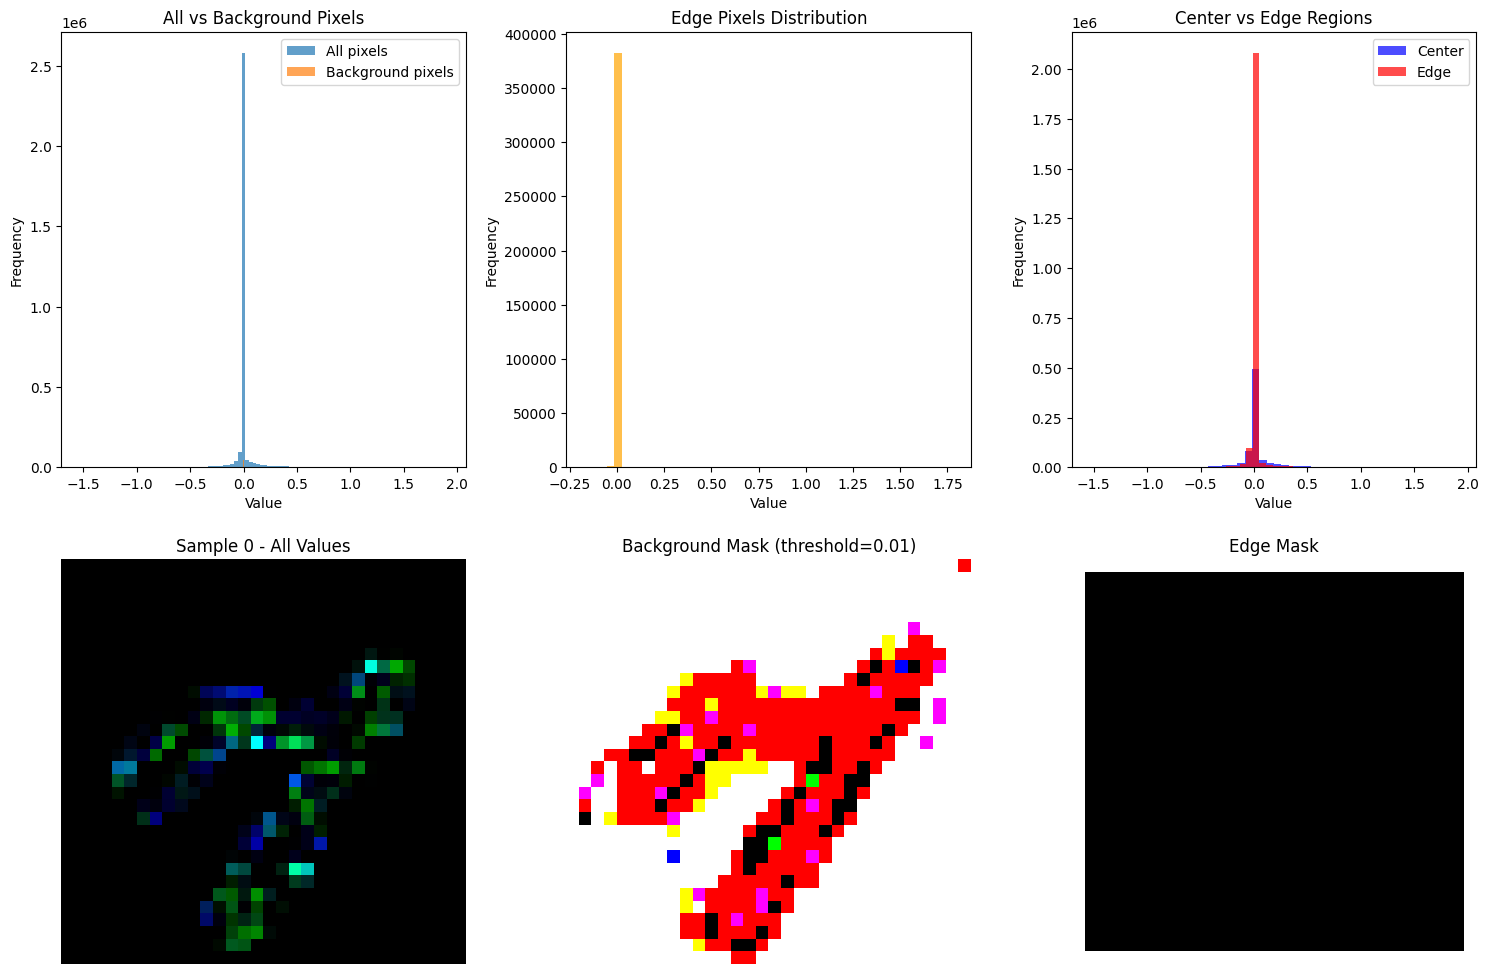


=== Detailed Background Analysis ===
Pixels with exactly zero value: 8
Pixels with |value| < 0.001: 82542
Pixels with |value| < 0.01: 2441510
Pixels with |value| < 0.1: 2813816

Samples with zero pixels: 4/1000
Max zeros in a single sample: 3
Min zeros in a single sample: 0


In [ ]:
# Analyze background pixels in U_ll_hat
print("=== Background Pixel Analysis in U_ll_hat ===")

# Method 1: Analyze pixels that are close to zero (likely background)
background_threshold = 0.01  # Adjust this threshold as needed
background_mask = (torch.abs(U_ll_hat) < background_threshold)
background_pixels = U_ll_hat[background_mask]

print(f"Background threshold: {background_threshold}")
print(f"Background pixels found: {len(background_pixels)}/{U_ll_hat.numel()} ({len(background_pixels)/U_ll_hat.numel()*100:.2f}%)")
print(f"Background pixel statistics:")
print(f"  Min: {background_pixels.min().item():.6f}")
print(f"  Max: {background_pixels.max().item():.6f}")
print(f"  Mean: {background_pixels.mean().item():.6f}")
print(f"  Std: {background_pixels.std().item():.6f}")

# Method 2: Analyze edge pixels (likely background)
edge_pixels = []
for i in range(U_ll_hat.shape[0]):  # For each sample
    for c in range(U_ll_hat.shape[1]):  # For each channel
        # Get edge pixels (first and last rows/columns)
        edge_pixels.append(U_ll_hat[i, c, 0, :])  # Top edge
        edge_pixels.append(U_ll_hat[i, c, -1, :])  # Bottom edge
        edge_pixels.append(U_ll_hat[i, c, :, 0])   # Left edge
        edge_pixels.append(U_ll_hat[i, c, :, -1]) # Right edge

edge_pixels = torch.cat(edge_pixels)
print(f"\nEdge pixels analysis:")
print(f"  Edge pixels found: {len(edge_pixels)}")
print(f"  Min: {edge_pixels.min().item():.6f}")
print(f"  Max: {edge_pixels.max().item():.6f}")
print(f"  Mean: {edge_pixels.mean().item():.6f}")
print(f"  Std: {edge_pixels.std().item():.6f}")

# Method 3: Analyze center vs edge regions
center_region = U_ll_hat[:, :, 8:24, 8:24]  # Center 16x16 region

# Analyze edge regions separately
top_edge = U_ll_hat[:, :, :8, :]      # Top 8 rows
bottom_edge = U_ll_hat[:, :, 24:, :]  # Bottom 8 rows  
left_edge = U_ll_hat[:, :, 8:24, :8]  # Left 8 columns
right_edge = U_ll_hat[:, :, 8:24, 24:] # Right 8 columns

print(f"\nCenter vs Edge comparison:")
print(f"  Center region (16x16): mean={center_region.mean().item():.6f}, std={center_region.std().item():.6f}")
print(f"  Top edge: mean={top_edge.mean().item():.6f}, std={top_edge.std().item():.6f}")
print(f"  Bottom edge: mean={bottom_edge.mean().item():.6f}, std={bottom_edge.std().item():.6f}")
print(f"  Left edge: mean={left_edge.mean().item():.6f}, std={left_edge.std().item():.6f}")
print(f"  Right edge: mean={right_edge.mean().item():.6f}, std={right_edge.std().item():.6f}")

# Combine all edge regions for overall edge analysis
edge_regions = [top_edge, bottom_edge, left_edge, right_edge]
edge_means = [region.mean().item() for region in edge_regions]
edge_stds = [region.std().item() for region in edge_regions]
print(f"  Overall edge: mean={np.mean(edge_means):.6f}, std={np.mean(edge_stds):.6f}")

# Visualize background pixels
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Histogram of all U_ll_hat values
axes[0, 0].hist(U_ll_hat.numpy().flatten(), bins=100, alpha=0.7, label='All pixels')
axes[0, 0].hist(background_pixels.numpy(), bins=50, alpha=0.7, label='Background pixels')
axes[0, 0].set_title('All vs Background Pixels')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# 2. Histogram of edge pixels
axes[0, 1].hist(edge_pixels.numpy(), bins=50, alpha=0.7, color='orange')
axes[0, 1].set_title('Edge Pixels Distribution')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')

# 3. Center vs Edge comparison
axes[0, 2].hist(center_region.numpy().flatten(), bins=50, alpha=0.7, label='Center', color='blue')
# Combine all edge regions for visualization
all_edge_pixels = torch.cat([region.flatten() for region in edge_regions])
axes[0, 2].hist(all_edge_pixels.numpy(), bins=50, alpha=0.7, label='Edge', color='red')
axes[0, 2].set_title('Center vs Edge Regions')
axes[0, 2].set_xlabel('Value')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()

# 4. Sample image with background highlighted
sample_idx = 0
sample_img = U_ll_hat[sample_idx].permute(1, 2, 0).numpy().astype(np.float32)
if sample_img.shape[2] == 1:
    sample_img = sample_img.squeeze(2)
    axes[1, 0].imshow(sample_img, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
else:
    axes[1, 0].imshow(sample_img)
axes[1, 0].set_title(f'Sample {sample_idx} - All Values')
axes[1, 0].axis('off')

# 5. Background mask visualization
background_mask_sample = (torch.abs(U_ll_hat[sample_idx]) < background_threshold)
background_mask_vis = background_mask_sample.permute(1, 2, 0).numpy().astype(np.float32)
if background_mask_vis.shape[2] == 1:
    background_mask_vis = background_mask_vis.squeeze(2)
axes[1, 1].imshow(background_mask_vis, cmap='gray')
axes[1, 1].set_title(f'Background Mask (threshold={background_threshold})')
axes[1, 1].axis('off')

# 6. Edge mask visualization
edge_mask = torch.zeros_like(U_ll_hat[sample_idx])
edge_mask[:, 0, :] = 1  # Top edge
edge_mask[:, -1, :] = 1  # Bottom edge
edge_mask[:, :, 0] = 1  # Left edge
edge_mask[:, :, -1] = 1  # Right edge
edge_mask_vis = edge_mask.permute(1, 2, 0).numpy().astype(np.float32)
if edge_mask_vis.shape[2] == 1:
    edge_mask_vis = edge_mask_vis.squeeze(2)
axes[1, 2].imshow(edge_mask_vis, cmap='gray')
axes[1, 2].set_title('Edge Mask')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Additional analysis: Check if background pixels are truly zero or just small
print(f"\n=== Detailed Background Analysis ===")
print(f"Pixels with exactly zero value: {(U_ll_hat == 0).sum().item()}")
print(f"Pixels with |value| < 0.001: {(torch.abs(U_ll_hat) < 0.001).sum().item()}")
print(f"Pixels with |value| < 0.01: {(torch.abs(U_ll_hat) < 0.01).sum().item()}")
print(f"Pixels with |value| < 0.1: {(torch.abs(U_ll_hat) < 0.1).sum().item()}")

# Check if there are any truly zero regions
zero_regions = (U_ll_hat == 0).sum(dim=(1, 2, 3))  # Count zeros per sample
print(f"\nSamples with zero pixels: {(zero_regions > 0).sum().item()}/{len(zero_regions)}")
print(f"Max zeros in a single sample: {zero_regions.max().item()}")
print(f"Min zeros in a single sample: {zero_regions.min().item()}")


In [ ]:
def det_hl_func(hl_model, parent_info_hl, intervention):
    """
    Returns full high-level vectors (one-hot labels + image features)
    """
    features = parent_info_hl.copy()
    
    # Apply intervention if specified
    if intervention is not None:
        iv_dict = intervention.vv()
        if 'D_HL' in globals() and D_HL in iv_dict:
            new_digits = np.zeros_like(features[:, :10])
            new_digits[:, iv_dict[D_HL]] = 1
            features[:, :10] = new_digits
        if 'C_HL' in globals() and C_HL in iv_dict:
            new_colors = np.zeros_like(features[:, 10:])
            new_colors[:, iv_dict[C_HL]] = 1
            features[:, 10:] = new_colors
    
    # Get image features from the model
    image_features = hl_model.predict(features)
    
    # Ensure image_features is 2D
    if image_features.ndim == 1:
        image_features = image_features.reshape(-1, 1)
    
    # Return full vector: [one-hot digits, one-hot colors, image features]
    full_vector = np.concatenate([features, image_features], axis=1)  # Shape: (N, 21)
    return torch.tensor(full_vector, dtype=torch.float32)

def det_ll_func(ll_model, parent_info_ll_tuple, intervention):
    """
    Returns full low-level vectors (flattened images + one-hot labels)
    """
    # Unpack data
    _, img_shapes, digits, colors = parent_info_ll_tuple
    n_samples = digits.shape[0]

    # Apply intervention to labels if specified
    if intervention is not None:
        iv_dict = intervention.vv()
        if 'D_LL' in globals() and D_LL in iv_dict:
            digits = torch.full_like(digits, iv_dict[D_LL])
        if 'C_LL' in globals() and C_LL in iv_dict:
            colors = torch.full_like(colors, iv_dict[C_LL])

    # Forward pass through U-Net
    ll_model.eval()
    device = next(ll_model.parameters()).device
    img_shapes = img_shapes.to(device)
    digits = digits.to(device).long()
    colors = colors.to(device).long()

    with torch.no_grad():
        predicted_images = ll_model(img_shapes, digits, colors)

    # Flatten images
    flattened_images = predicted_images.cpu().view(n_samples, -1)  # Shape: (N, 3072)
    
    # Create one-hot labels
    digits_onehot = F.one_hot(digits.cpu(), num_classes=10).float()  # Shape: (N, 10)
    colors_onehot = F.one_hot(colors.cpu(), num_classes=10).float()  # Shape: (N, 10)
    
    # Return full vector: [flattened images, one-hot digits, one-hot colors]
    full_vector = torch.cat([flattened_images, digits_onehot, colors_onehot], dim=1)  # Shape: (N, 3092)
    return full_vector


# Low-level parent info (observational data)
parent_info_ll_tuple = (
    Dll_samples[None][0],  # final_images (unused)
    Dll_samples[None][1],  # img_shapes
    Dll_samples[None][2],  # digits
    Dll_samples[None][3],  # colors
)

# High-level parent info (observational data)
parent_info_hl = Dhl_samples[None][:, :-1].numpy()  # All features except last column

# Low-level (U-Net)
det_ll_dict = {}
for iota in tqdm(Ill_relevant, desc="Computing Low-Level deterministic outputs (U-Net)"):
    det_ll_dict[iota] = det_ll_func(ll_model, parent_info_ll_tuple, iota)

# High-level (Linear Regression)
det_hl_dict = {}
for eta in tqdm(Ihl_relevant, desc="Computing High-Level deterministic outputs (Linear)"):
    det_hl_dict[eta] = det_hl_func(hl_model, parent_info_hl, eta)

print(f"   - Low-level shape: {det_ll_dict[None].shape}")
print(f"   - High-level shape: {det_hl_dict[None].shape}")

Computing Low-Level deterministic outputs (U-Net): 100%|██████████| 10/10 [00:20<00:00,  2.09s/it]
Computing High-Level deterministic outputs (Linear): 100%|██████████| 10/10 [00:00<00:00, 1544.64it/s]

   - Low-level shape: torch.Size([1000, 3092])
   - High-level shape: torch.Size([1000, 21])


In [ ]:
print("\n" + "="*20 + " Diagnostic Test for hl_model " + "="*20)

# --- 1. Define the intervention objects (needed for the test) ---
# (You can skip this if eta_do_digit_8 and eta_do_color_0 are still in memory)
eta_do_digit_8 = None
eta_do_color_0 = None
for eta_key in det_hl_dict.keys(): # Use keys from dict we just built
     if eta_key is not None and hasattr(eta_key, 'vv'):
         iv_dict = eta_key.vv()
         if iv_dict == {D_HL: 8}: eta_do_digit_8 = eta_key
         elif iv_dict == {C_HL: 0}: eta_do_color_0 = eta_key

if (eta_do_digit_8 is None) or (eta_do_color_0 is None):
    print("Error: Could not find intervention objects. Cannot run diagnostic.")
else:
    # --- 2. Calculate Deterministic Predictions (D_h) ---
    # We use det_hl_func, which internally uses hl_model.predict()
    
    # D_h for Observational
    D_h_obs = det_hl_func(hl_model, parent_info_hl, None)
    
    # D_h for do(Digit=8)
    D_h_digit8 = det_hl_func(hl_model, parent_info_hl, eta_do_digit_8)
    
    # D_h for do(Color=0)
    D_h_color0 = det_hl_func(hl_model, parent_info_hl, eta_do_color_0)

    # --- 3. Compare the Mean of the Predicted Feature (Column 21) ---
    # We are checking if hl_model.predict() output (the last column) changes
    
    mean_obs = D_h_obs[:, -1].mean().item()
    mean_digit8 = D_h_digit8[:, -1].mean().item()
    mean_color0 = D_h_color0[:, -1].mean().item()

    print(f"Mean predicted 'Image_' feature (Observational): {mean_obs:.6f}")
    print(f"Mean predicted 'Image_' feature (do(Digit=8)):   {mean_digit8:.6f}")
    print(f"Mean predicted 'Image_' feature (do(Color=0)):   {mean_color0:.6f}")

    # --- 4. Conclusion ---
    if np.isclose(mean_obs, mean_digit8) and np.isclose(mean_obs, mean_color0):
        print("\n*** DIAGNOSIS: PROBLEM CONFIRMED ***")
        print("Your hl_model is returning the same mean prediction for all interventions.")
        print("This breaks the training objective for DiRoCA, GradCA, and BaryCA.")
        print("SOLUTION: You must re-run the 'updated' train_models.py to generate a new, correctly trained 'hl_model.joblib' file.")
    else:
        print("\n*** DIAGNOSIS: OK ***")
        print("Your hl_model seems to be responding to interventions correctly.")
        print("If results are still strange, the problem may be elsewhere.")


==================== Diagnostic Test for hl_model ====================
Mean predicted 'Image_' feature (Observational): 0.046775
Mean predicted 'Image_' feature (do(Digit=8)):   0.053900
Mean predicted 'Image_' feature (do(Color=0)):   0.017411

*** DIAGNOSIS: OK ***
Your hl_model seems to be responding to interventions correctly.
If results are still strange, the problem may be elsewhere.


In [ ]:
print("="*60)
print("HL IMAGE VARIABLE DISTRIBUTION ANALYSIS")
print("="*60)

# Define HL variable names
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

# Extract image features (last column) for different interventions
interventions_to_plot = {
    "Observational": None,
    "do(Digit=8)": None, 
    "do(Color=0)": None,
    "do(Digit=8, Color=0)": None
}

# Find intervention objects
for eta in Dhl_samples.keys():
    if eta is not None and hasattr(eta, 'vv'):
        iv_dict = eta.vv()
        if iv_dict == {D_HL: 8}:
            interventions_to_plot["do(Digit=8)"] = eta
        elif iv_dict == {C_HL: 0}:
            interventions_to_plot["do(Color=0)"] = eta
        elif iv_dict == {D_HL: 8, C_HL: 0}:
            interventions_to_plot["do(Digit=8, Color=0)"] = eta

# Extract image features for each intervention
hl_feature_values = {}
for name, eta in interventions_to_plot.items():
    if eta is None:
        # Observational data
        data = Dhl_samples[None]
    else:
        data = Dhl_samples[eta]
    
    # Extract image features (last column)
    image_features = data[:, -1].numpy()
    hl_feature_values[name] = image_features
    
    print(f"{name}:")
    print(f"  Mean: {image_features.mean():.6f}")
    print(f"  Std:  {image_features.std():.6f}")
    print(f"  Min:  {image_features.min():.6f}")
    print(f"  Max:  {image_features.max():.6f}")

# Create the plot
plt.figure(figsize=(12, 8))
colors = ['blue', 'orange', 'green', 'purple']

for i, (name, values) in enumerate(hl_feature_values.items()):
    plt.hist(values, bins=50, alpha=0.6, label=name, density=True, color=colors[i])

plt.title('HL Image Variable Distribution for Different Interventions', fontsize=16)
plt.xlabel('Mean Pixel Intensity (HL Image_ variable)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print comparison statistics
print("\n" + "="*60)
print("INTERVENTION RESPONSE ANALYSIS")
print("="*60)

obs_mean = hl_feature_values["Observational"].mean()
for name, values in hl_feature_values.items():
    if name != "Observational":
        diff = values.mean() - obs_mean
        print(f"{name}: Mean difference = {diff:+.6f}")

In [ ]:
# Setup cross-validation
K_FOLDS = 5
SEED = 23

def setup_cv_folds(data_tuple, n_splits=K_FOLDS, seed=SEED):
    """Create k-fold splits using the first tensor's length."""
    print(f"Setting up {n_splits}-fold cross-validation...")
    num_samples = data_tuple[0].shape[0]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for train_idx, test_idx in kf.split(np.arange(num_samples)):
        folds.append({'train': train_idx, 'test': test_idx})
    print(f"✓ CV folds created. Each fold will have ~{len(folds[0]['train'])} training samples.")
    return folds

# Create CV folds
cv_folds = setup_cv_folds(Dll_samples[None])
print(f"Created {len(cv_folds)} CV folds")

Setting up 5-fold cross-validation...
✓ CV folds created. Each fold will have ~800 training samples.
Created 5 CV folds


In [ ]:
# Fix the noise data to have correct dimensions
def fix_noise_data(U_ll_hat, U_hl_hat):
    """Fix noise data to have correct dimensions."""
    
    # U_ll_hat is (1000, 3, 32, 32) - need to flatten to (1000, 3072)
    if U_ll_hat.shape == (1000, 3, 32, 32):
        U_ll_hat_fixed = U_ll_hat.view(1000, -1)  # Flatten to (1000, 3072)
        print(f"Flattened U_ll_hat from {U_ll_hat.shape} to {U_ll_hat_fixed.shape}")
    else:
        U_ll_hat_fixed = U_ll_hat
        print(f"U_ll_hat already has shape: {U_ll_hat_fixed.shape}")
    
    # U_hl_hat is (1000, 1) - this is correct
    if U_hl_hat.shape == (1000, 1):
        U_hl_hat_fixed = U_hl_hat
        print(f"U_hl_hat already has correct shape: {U_hl_hat_fixed.shape}")
    else:
        U_hl_hat_fixed = U_hl_hat
        print(f"U_hl_hat has shape: {U_hl_hat_fixed.shape}")
    
    return U_ll_hat_fixed, U_hl_hat_fixed

# Fix the noise data
U_ll_hat_fixed, U_hl_hat_fixed = fix_noise_data(U_ll_hat, U_hl_hat)

print(f"Fixed U_ll_hat shape: {U_ll_hat_fixed.shape}")
print(f"Fixed U_hl_hat shape: {U_hl_hat_fixed.shape}")

Flattened U_ll_hat from torch.Size([1000, 3, 32, 32]) to torch.Size([1000, 3072])
U_hl_hat already has correct shape: torch.Size([1000, 1])
Fixed U_ll_hat shape: torch.Size([1000, 3072])
Fixed U_hl_hat shape: torch.Size([1000, 1])


In [ ]:
# --- Projection and Radius ---
def project_onto_frobenius_ball(tensor, radius_limit):
    """Project tensor onto Frobenius norm ball ||X||_F <= radius_limit."""
    # Note: radius_limit here is the TOTAL norm limit (e.g., sqrt(N)*epsilon)
    with torch.no_grad():
        current_norm = torch.norm(tensor, p='fro')
        if current_norm > radius_limit:
            # Scale down to lie on the boundary
            tensor.mul_(radius_limit / (current_norm + 1e-12)) 
    return tensor

def compute_empirical_radius(N, eta=0.05, c1=1000.0, c2=1.0, alpha=2.0, m=1):
    """Compute empirical radius based on formula."""
    # Ensure N is large enough for log
    if N <= 1: return 0.0 
    term1 = c1 * (np.log(N) / N) ** (1 / alpha)
    term2 = c2 * np.sqrt(m * np.log(1 / eta) / N)
    return term1 + term2

# --- Abs-LiNGAM Core Functions (Ensure these are correct for your setup) ---
def perfect_abstraction(px_samples, py_samples, tau_threshold=1e-2):
    """
    Fits an abstraction function assumed to be perfect.
    Returns T_raw with shape (D_ll, D_hl).
    """
    # Solves px_samples @ T_raw ≈ py_samples
    T_raw = np.linalg.pinv(px_samples) @ py_samples 
    T_raw_mask = np.abs(T_raw) > tau_threshold
    T_raw = T_raw * T_raw_mask
    return T_raw

import numpy as np # Ensure numpy is imported

def noisy_abstraction(px_samples, py_samples, tau_threshold=1e-1, refit_coeff=False):
    """
    Fits an abstraction function assumed to be noisy, using argmax masking.
    (Based on the provided reference code)
    Returns T_raw with shape (D_ll, D_hl).
    """
    try:
        # Reconstruct T using pseudo-inverse
        T_raw_hat = np.linalg.pinv(px_samples) @ py_samples # Shape (D_ll, D_hl)

        # Masking based on max absolute entry per LL variable (row)
        # Find the index of the HL variable that each LL variable maps most strongly to
        tau_mask_indices = np.argmax(np.abs(T_raw_hat), axis=1) # Shape (D_ll,)

        # Convert indices to a one-hot mask matrix
        abs_nodes = py_samples.shape[1] # Number of HL variables (D_hl)
        # Create an identity matrix (D_hl x D_hl) and index rows by tau_mask_indices
        tau_mask_hat = np.eye(abs_nodes)[tau_mask_indices] # Shape (D_ll, D_hl)

        # Filter the one-hot mask based on the absolute value threshold
        # Only keep the '1' in the mask if the corresponding T_raw_hat value exceeds the threshold
        tau_mask_hat *= np.array(np.abs(T_raw_hat) > tau_threshold, dtype=np.int32)

        # Apply the final combined mask to the initially computed T
        T_masked = tau_mask_hat * T_raw_hat # Shape (D_ll, D_hl)

        # Optional: Refit coefficients (use with caution, logic might need verification)
        if refit_coeff:
            print("Warning: refit_coeff=True in noisy_abstraction is not fully implemented/verified.")
            # Original code's refit logic (needs careful checking):
            T_refit = T_masked.copy() # Start with the masked T
            for y in range(tau_mask_hat.shape[1]): # For each HL variable
                # Find LL variables that map to it (non-zero in the mask)
                block = np.where(tau_mask_hat[:, y] == 1)[0]
                if len(block) > 0:
                    # Refit the coefficients for this block using least squares
                    try:
                        # Solve px_samples[:, block] @ T_block ≈ py_samples[:, y]
                        T_block = np.linalg.pinv(px_samples[:, block]) @ py_samples[:, y]
                        T_refit[block, y] = T_block # Update the coefficients in T_refit
                    except np.linalg.LinAlgError as e:
                        print(f"Warning: pinv failed during refit for HL var {y}: {e}. Skipping refit for this block.")
            return T_refit
        else:
            # Return the masked T without refitting
            return T_masked

    except np.linalg.LinAlgError as e:
         print(f"Error during pinv in noisy_abstraction: {e}")
         return np.zeros((px_samples.shape[1], py_samples.shape[1]), dtype=px_samples.dtype)
    except Exception as e:
        print(f"Error in noisy_abstraction: {e}")
        return np.zeros((px_samples.shape[1], py_samples.shape[1]), dtype=px_samples.dtype)

print("Helper functions defined.")

Helper functions defined.


In [ ]:
def empirical_objective_cmnist_full(T, U_ll, U_hl, Theta_ll, Phi_hl, det_ll_dict, det_hl_dict, parent_info, omega):
    """Computes objective for DiRoCA/GradCA using full ANM structure."""
    total_loss = 0.0
    device = T.device
    
    # Move tensors to device once
    U_ll = U_ll.to(device)
    U_hl = U_hl.to(device)
    Theta_ll = Theta_ll.to(device)
    Phi_hl = Phi_hl.to(device)
    
    num_interventions = 0
    for iota, eta in omega.items():
        if iota not in det_ll_dict or eta not in det_hl_dict:
            continue
            
        det_ll_full = det_ll_dict[iota].to(device)
        det_hl_full = det_hl_dict[eta].to(device)
        
        # Check batch size
        N = U_ll.shape[0]
        if det_ll_full.shape[0] != N or det_hl_full.shape[0] != N:
            continue
            
        # Reconstruct noisy vectors
        image_part = det_ll_full[:, :3072]
        label_part_ll = det_ll_full[:, 3072:]
        image_part_noisy = image_part + U_ll + Theta_ll
        endo_ll_full = torch.cat([image_part_noisy, label_part_ll], dim=1)
        
        label_part_hl = det_hl_full[:, :20]
        feature_part = det_hl_full[:, 20:]
        feature_part_noisy = feature_part + U_hl + Phi_hl
        endo_hl_full = torch.cat([label_part_hl, feature_part_noisy], dim=1)
        
        # Apply abstraction and compute loss
        mapped_ll = (T @ endo_ll_full.T).T
        diff = mapped_ll - endo_hl_full
        loss = torch.norm(diff, p='fro')**2 / N  # Normalize by N
        total_loss += loss
        num_interventions += 1
    
    return total_loss / max(1, num_interventions)  # Average over interventions


# --- Objective for BaryCA ---
def barycentric_objective_cmnist(T, U_ll, U_hl, det_ll_dict, det_hl_dict, omega):
    """BaryCA objective: Minimize error between T(Avg LL) and Avg HL."""
    num_interventions = 0
    device = T.device

    # Move noise to device
    U_ll = U_ll.to(device)
    U_hl = U_hl.to(device)

    # Calculate average deterministic components across interventions
    ll_tensors = []
    hl_tensors = []
    for iota, eta in omega.items():
        if iota in det_ll_dict and eta in det_hl_dict:
             ll_tensors.append(det_ll_dict[iota].to(device))
             hl_tensors.append(det_hl_dict[eta].to(device))
             num_interventions += 1

    if num_interventions == 0: return torch.tensor(0.0, device=device)

    avg_det_ll = torch.mean(torch.stack(ll_tensors), dim=0) #(N, 3092)
    avg_det_hl = torch.mean(torch.stack(hl_tensors), dim=0) #(N, 21)
    N = avg_det_ll.shape[0] # Get N from averaged tensor

    # Reconstruct average "noisy" vectors
    avg_det_ll_pixels = avg_det_ll[:, :3072]
    avg_det_ll_labels = avg_det_ll[:, 3072:]
    avg_noisy_ll = torch.cat([avg_det_ll_pixels + U_ll, avg_det_ll_labels], dim=1)

    avg_det_hl_labels = avg_det_hl[:, :20]
    avg_det_hl_feature = avg_det_hl[:, 20:]
    avg_noisy_hl = torch.cat([avg_det_hl_labels, avg_det_hl_feature + U_hl], dim=1)

    # Calculate error
    mapped_avg_ll = (T @ avg_noisy_ll.T).T
    diff = mapped_avg_ll - avg_noisy_hl
    loss = torch.norm(diff, p='fro')**2 / max(1, N) # Normalize by N

    return loss

print("Objective functions defined.")

Objective functions defined.


In [ ]:
# --- Empirical Training Monitor ---
class EmpiricalMonitor:
    """Tracks metrics during empirical optimization."""
    def __init__(self):
        self.iteration_history = []

    def track_iteration(self, iteration, T_objective, T_matrix, T_matrix_prev,
                        adv_objective=None, Theta=None, Phi=None, epsilon=None, delta=None):
        metrics = {
            'iteration': iteration,
            'T_objective': T_objective.item() if isinstance(T_objective, torch.Tensor) else T_objective,
            'delta_T_norm': torch.norm(T_matrix - T_matrix_prev, p='fro').item() if T_matrix_prev is not None else 0.0,
        }
        # Check if adv_objective is valid before adding
        if adv_objective is not None and not (isinstance(adv_objective, float) and np.isnan(adv_objective)):
            metrics['adv_objective'] = adv_objective.item() if isinstance(adv_objective, torch.Tensor) else adv_objective
        if Theta is not None:
            metrics['theta_norm'] = torch.norm(Theta, p='fro').item()
            if epsilon is not None and Theta.shape[0] > 0: # Need N > 0 for sqrt(N)
                 metrics['epsilon_boundary'] = epsilon * np.sqrt(Theta.shape[0])
            else: metrics['epsilon_boundary'] = np.nan
        if Phi is not None:
            metrics['phi_norm'] = torch.norm(Phi, p='fro').item()
            if delta is not None and Phi.shape[0] > 0:
                 metrics['delta_boundary'] = delta * np.sqrt(Phi.shape[0])
            else: metrics['delta_boundary'] = np.nan

        self.iteration_history.append(metrics)

    def plot_summary(self, title_prefix=""):
        if not self.iteration_history:
            print("No history to plot.")
            return

        df = pd.DataFrame(self.iteration_history).set_index('iteration') # Use iteration as index

        num_plots = 2
        # Check if columns exist and have non-NaN values
        has_adv = 'adv_objective' in df.columns and not df['adv_objective'].isnull().all()
        has_pert = 'theta_norm' in df.columns and not df['theta_norm'].isnull().all()

        if has_adv: num_plots += 1
        if has_pert: num_plots += 1

        fig, axes = plt.subplots(num_plots, 1, figsize=(12, 4 * num_plots), sharex=True)
        if num_plots == 1: axes = [axes] # Ensure axes is iterable
        fig.suptitle(f'{title_prefix} Optimization Convergence Summary', fontsize=16, y=1.02)
        plot_idx = 0

        # 1. T Objective
        axes[plot_idx].plot(df.index, df['T_objective'], marker='.', linestyle='-', label='T Objective (Minimize)')
        axes[plot_idx].set_ylabel("Objective Value")
        axes[plot_idx].set_title("Objective vs. Iteration")
        axes[plot_idx].grid(True, alpha=0.5)

        # 2. Adversary Objective (if DiRoCA)
        if has_adv:
            # Plot on same axis as T objective
            axes[plot_idx].plot(df.index, df['adv_objective'], marker='.', linestyle='-', color='orange', label='Adv. Objective (Maximize)')
            axes[plot_idx].legend() # Add legend here

            # Plot on separate axis below T objective
            plot_idx += 1
            axes[plot_idx].plot(df.index, df['adv_objective'], marker='.', linestyle='-', color='orange')
            axes[plot_idx].set_ylabel("Objective Value")
            axes[plot_idx].set_title("Adversary Objective vs. Iteration")
            axes[plot_idx].grid(True, alpha=0.5)
        else:
             axes[plot_idx].legend() # Add legend for T objective if no adversary

        # 3. Delta T Norm
        plot_idx += 1
        axes[plot_idx].plot(df.index, df['delta_T_norm'], marker='.', linestyle='-')
        axes[plot_idx].set_ylabel("Frobenius Norm")
        axes[plot_idx].set_title("Change in T (||T_t - T_{t-1}||_F)")
        axes[plot_idx].set_yscale('log')
        axes[plot_idx].grid(True, alpha=0.5)

        # 4. Perturbation Norms (if DiRoCA)
        if has_pert:
            plot_idx += 1
            axes[plot_idx].plot(df.index, df['theta_norm'], marker='.', linestyle='-', label='||Theta||_F (Low Level)')
            axes[plot_idx].plot(df.index, df['phi_norm'], marker='.', linestyle='-', label='||Phi||_F (High Level)')

            # Plot boundaries if they exist and are not NaN
            if 'epsilon_boundary' in df.columns and not df['epsilon_boundary'].isnull().all():
                 boundary_val = df['epsilon_boundary'].dropna().iloc[0] # Get first non-NaN boundary
                 axes[plot_idx].axhline(boundary_val, color='blue', linestyle='--', alpha=0.7, label=f'Epsilon Boundary ({boundary_val:.1f})')
            if 'delta_boundary' in df.columns and not df['delta_boundary'].isnull().all():
                 boundary_val = df['delta_boundary'].dropna().iloc[0]
                 axes[plot_idx].axhline(boundary_val, color='orange', linestyle='--', alpha=0.7, label=f'Delta Boundary ({boundary_val:.1f})')

            axes[plot_idx].set_ylabel("Frobenius Norm")
            axes[plot_idx].set_title("Perturbation Norms vs. Iteration")
            axes[plot_idx].legend()
            axes[plot_idx].grid(True, alpha=0.5)

        axes[-1].set_xlabel("Iteration")
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()

print("EmpiricalMonitor class defined.")

EmpiricalMonitor class defined.


In [ ]:
import torch
import numpy as np
from tqdm import tqdm
import torch.optim as optim
import torch.nn.init as init # For Xavier init

# --- Core DiRoCA / GradCA Optimizer ---
def run_empirical_erica_optimization_fixed(U_L, U_H, det_ll_dict, det_hl_dict, omega, epsilon, delta,
                                         eta_min, eta_max, num_steps_min, num_steps_max,
                                         max_iter, tol, seed, robust_L, robust_H,
                                         initialization, experiment, gain, optimizers,
                                         monitor=None):
    """Core optimization loop for DiRoCA (robust=True) and GradCA (robust=False)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    # --- Device Setup ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    Ill = list(det_ll_dict.keys()) # Assuming keys are intervention objects or None
    method = 'erica' if robust_L or robust_H else 'enrico'

    # --- Data Prep ---
    U_L = torch.as_tensor(U_L, dtype=torch.float32).to(device) # Move to device
    U_H = torch.as_tensor(U_H, dtype=torch.float32).to(device) # Move to device
    if U_L.ndim > 2: U_L = U_L.view(U_L.shape[0], -1)
    if U_H.ndim > 2: U_H = U_H.view(U_H.shape[0], -1)

    N, l = U_L.shape # l=3072
    _, h = U_H.shape # h=1
    l_full, h_full = 3092, 21

    # Move det_dicts to device once
    det_ll_dict_dev = {k: v.to(device) for k, v in det_ll_dict.items()}
    det_hl_dict_dev = {k: v.to(device) for k, v in det_hl_dict.items()}


    # --- Initialization ---
    T = torch.randn(h_full, l_full, requires_grad=True, device=device) # Init on device
    if gain > 0: init.xavier_normal_(T, gain=gain)

    # Init Theta/Phi on device, requires_grad only if robust
    if initialization == 'zeros':
        Theta = torch.zeros(N, l, requires_grad=(method=='erica'), device=device)
        Phi   = torch.zeros(N, h, requires_grad=(method=='erica'), device=device)
    elif initialization == 'random':
        Theta = torch.randn(N, l, requires_grad=(method=='erica'), device=device)
        Phi   = torch.randn(N, h, requires_grad=(method=='erica'), device=device)
    else: raise ValueError(f"Unknown initialization: {initialization}")

    # --- Optimizers ---
    optimizer_T_params = [T]
    optimizer_max_params = [Theta, Phi] if method == 'erica' else []

    if optimizers == 'adam':
        optimizer_T = optim.Adam(optimizer_T_params, lr=eta_min)
        if optimizer_max_params: optimizer_max = optim.Adam(optimizer_max_params, lr=eta_max)
    elif optimizers == 'adam_betas':
        optimizer_T  = optim.Adam(optimizer_T_params, lr=eta_min, betas=(0.9,0.999), eps=1e-8, amsgrad=True)
        if optimizer_max_params: optimizer_max = optim.Adam(optimizer_max_params, lr=eta_max, betas=(0.9,0.999), eps=1e-8, amsgrad=True)
    else: raise ValueError(f"Unknown optimizer: {optimizers}")

    prev_T_objective = float('inf')
    T_prev = None
    if monitor is None: monitor = EmpiricalMonitor()

    # --- Optimization Loop ---
    for iteration in tqdm(range(max_iter), desc=f"{method.upper()} Optimization"):
        T_prev = T.detach().clone()
        final_T_objective_in_iter = torch.tensor(np.nan, device=device) # Init as NaN tensor
        final_adv_objective_in_iter = torch.tensor(np.nan, device=device)


        # --- Step 1: Minimize T ---
        for _ in range(num_steps_min):
            optimizer_T.zero_grad()
            # Pass device dictionaries
            T_objective = empirical_objective_cmnist_full(T, U_L, U_H, Theta.detach(), Phi.detach(), # Detach Theta/Phi for T update
                                                          det_ll_dict_dev, det_hl_dict_dev, None, omega)
            if torch.isnan(T_objective):
                 print(f"\nNaN encountered in T objective at iter {iteration+1}. Stopping.")
                 # Return previous state or handle error
                 T_final = T_prev.cpu().numpy() # Return last valid T
                 paramsL = {'pert_U': Theta.detach().cpu().numpy(),
                            'radius_worst': epsilon if method=='erica' else 0,
                            'pert_hat': U_L.cpu().numpy(), # Use U_L available here
                            'radius': epsilon if method=='erica' else 0}
                 paramsH = {'pert_U': Phi.detach().cpu().numpy(),
                            'radius_worst': delta if method=='erica' else 0,
                            'pert_hat': U_H.cpu().numpy(), # Use U_H available here
                            'radius': delta if method=='erica' else 0}
                 opt_params = {'L': paramsL, 'H': paramsH}
                 return opt_params, T_final, Theta.detach().cpu().numpy(), Phi.detach().cpu().numpy(), monitor

            T_objective.backward()
            optimizer_T.step()
            final_T_objective_in_iter = T_objective # Keep track

        # --- Step 2: Maximize Theta, Phi (if robust) ---
        if method == 'erica':
            for _ in range(num_steps_max):
                optimizer_max.zero_grad()
                # Detach T for adversary update
                max_objective = -empirical_objective_cmnist_full(T.detach(), U_L, U_H, Theta, Phi,
                                                                 det_ll_dict_dev, det_hl_dict_dev, None, omega)
                if torch.isnan(max_objective):
                     print(f"\nNaN encountered in Max objective at iter {iteration+1}. Using previous Theta/Phi.")
                     # Reset Theta/Phi gradients and skip optimizer step?
                     optimizer_max.zero_grad() # Clear potential NaN gradients
                     break # Skip rest of max steps for this iteration

                max_objective.backward()
                optimizer_max.step()

                # Project onto constraint sets
                with torch.no_grad():
                    max_norm_theta = epsilon * np.sqrt(N) if epsilon > 0 else 0
                    max_norm_phi = delta * np.sqrt(N) if delta > 0 else 0
                    # Ensure projection happens only if radius > 0
                    if max_norm_theta > 0: Theta.data = project_onto_frobenius_ball(Theta, max_norm_theta)
                    if max_norm_phi > 0: Phi.data   = project_onto_frobenius_ball(Phi, max_norm_phi)


            # Calculate final adversary objective value AFTER projection
            with torch.no_grad():
                 final_adv_objective_in_iter = empirical_objective_cmnist_full(T, U_L, U_H, Theta, Phi,
                                                                              det_ll_dict_dev, det_hl_dict_dev, None, omega)
        else: # GradCA case
             final_adv_objective_in_iter = final_T_objective_in_iter # Adv obj = T obj
             # Ensure Theta and Phi remain zero (they don't require grad anyway)
             Theta.zero_()
             Phi.zero_()

        # --- Track metrics ---
        # Ensure objectives are valid scalars before tracking
        t_obj_item = final_T_objective_in_iter.item() if torch.isfinite(final_T_objective_in_iter) else np.nan
        adv_obj_item = final_adv_objective_in_iter.item() if torch.isfinite(final_adv_objective_in_iter) else np.nan
        
        monitor.track_iteration(
            iteration=iteration + 1,
            T_objective=t_obj_item,
            T_matrix=T, T_matrix_prev=T_prev,
            adv_objective=adv_obj_item if method == 'erica' else None,
            Theta=Theta if method == 'erica' else None,
            Phi=Phi if method == 'erica' else None,
            epsilon=epsilon if method == 'erica' else None,
            delta=delta if method == 'erica' else None
        )

        # --- Convergence Check ---
        if not np.isnan(t_obj_item): # Only check convergence if objective is valid
            if abs(prev_T_objective - t_obj_item) < tol:
                print(f"\nConverged at iteration {iteration + 1} (delta_obj < {tol})")
                break
            prev_T_objective = t_obj_item
        elif iteration > 0: # If NaN, stop early after first iteration
             print(f"\nStopping early due to NaN objective at iteration {iteration + 1}")
             break


    # --- Final Steps ---
    T_final = T.detach().cpu().numpy() # Move T to CPU before converting to numpy

    monitor.plot_summary(title_prefix=f"{method.upper()} Fold (Seed {seed})")

    # Move final perturbations to CPU for saving
    Theta_final_np = Theta.detach().cpu().numpy()
    Phi_final_np = Phi.detach().cpu().numpy()

    paramsL = {'pert_U': Theta_final_np, 'radius_worst': epsilon if method=='erica' else 0,
               'pert_hat': U_L.cpu().numpy(), 'radius': epsilon if method=='erica' else 0}
    paramsH = {'pert_U': Phi_final_np, 'radius_worst': delta if method=='erica' else 0,
               'pert_hat': U_H.cpu().numpy(), 'radius': delta if method=='erica' else 0}
    opt_params = {'L': paramsL, 'H': paramsH}

    return opt_params, T_final, Theta_final_np, Phi_final_np, monitor


# --- Core BaryCA Optimizer ---
def run_empirical_bary_optim_cmnist(U_ll_hat, U_hl_hat, det_ll_dict, det_hl_dict, omega,
                                    lr=1e-3, max_iter=5000, tol=1e-5, seed=42,
                                    monitor=None):
    """Core optimization loop for BaryCA with monitoring."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    # --- Device Setup ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Data Prep ---
    U_ll_hat = torch.as_tensor(U_ll_hat, dtype=torch.float32).to(device)
    U_hl_hat = torch.as_tensor(U_hl_hat, dtype=torch.float32).to(device)
    if U_ll_hat.ndim > 2: U_ll_hat = U_ll_hat.view(U_ll_hat.shape[0], -1)
    if U_hl_hat.ndim > 2: U_hl_hat = U_hl_hat.view(U_hl_hat.shape[0], -1)
    l_full, h_full = 3092, 21

    # Move det_dicts to device once
    det_ll_dict_dev = {k: v.to(device) for k, v in det_ll_dict.items()}
    det_hl_dict_dev = {k: v.to(device) for k, v in det_hl_dict.items()}

    # --- Initialization ---
    T = torch.randn(h_full, l_full, requires_grad=True, device=device)
    optimizer = optim.Adam([T], lr=lr)
    prev_loss = float('inf')
    T_prev = None
    if monitor is None: monitor = EmpiricalMonitor()

    # --- Optimization Loop ---
    for iteration in tqdm(range(max_iter), desc="BaryCA Optimization"):
        T_prev = T.detach().clone()

        optimizer.zero_grad()
        # Pass device dictionaries
        loss = barycentric_objective_cmnist(T, U_ll_hat, U_hl_hat, det_ll_dict_dev, det_hl_dict_dev, omega)
        if torch.isnan(loss):
             print(f"NaN loss encountered at iteration {iteration}. Stopping.")
             break
        loss.backward()
        optimizer.step()

        current_loss_item = loss.item()

        # --- Track Iteration ---
        monitor.track_iteration(
            iteration=iteration + 1,
            T_objective=current_loss_item,
            T_matrix=T, T_matrix_prev=T_prev,
        )

        if iteration % 200 == 0:
            tqdm.write(f"Iter {iteration}, Loss: {current_loss_item:.6f}")
        if abs(prev_loss - current_loss_item) < tol:
            print(f"Converged at iteration {iteration}")
            break
        prev_loss = current_loss_item

    print(f"Final BaryCA loss: {current_loss_item:.6f}")
    monitor.plot_summary(title_prefix=f"BaryCA Fold (Seed {seed})")

    # Move T to CPU before numpy conversion
    return T.detach().cpu().numpy(), monitor


# --- Core Abs-LiNGAM Calculation ---
def run_abs_lingam_cmnist(Dll_obs_full, Dhl_obs_full, tau_perfect=1e-2, tau_noisy=1e-1):
    """Runs Abs-LiNGAM assuming full vectors are passed."""
    if isinstance(Dll_obs_full, torch.Tensor): Dll_obs_full = Dll_obs_full.cpu().numpy() # Move to CPU if needed
    if isinstance(Dhl_obs_full, torch.Tensor): Dhl_obs_full = Dhl_obs_full.cpu().numpy()

    try:
         # Ensure shapes are (N, D) before pinv
         if Dll_obs_full.shape[1] != 3092: raise ValueError(f"Expected Dll_obs_full to have 3092 columns, got {Dll_obs_full.shape[1]}")
         if Dhl_obs_full.shape[1] != 21: raise ValueError(f"Expected Dhl_obs_full to have 21 columns, got {Dhl_obs_full.shape[1]}")

         T_perfect_raw = perfect_abstraction(Dll_obs_full, Dhl_obs_full, tau_threshold=tau_perfect)
         T_noisy_raw = noisy_abstraction(Dll_obs_full, Dhl_obs_full, tau_threshold=tau_noisy, refit_coeff=False)

         T_perfect = T_perfect_raw.T.astype(np.float32) # Transpose
         T_noisy = T_noisy_raw.T.astype(np.float32)   # Transpose

         return {'Perfect': {'T': T_perfect}, 'Noisy': {'T': T_noisy}}
    except Exception as e:
         print(f"ERROR during Abs-LiNGAM: {e}")
         return {'Perfect': {'T': None}, 'Noisy': {'T': None}}


print("Core optimization functions defined.")

Core optimization functions defined.


In [ ]:
import torch
import numpy as np
import os
import gc
import torch.nn.functional as F # Needed for Abs-LiNGAM wrapper

# --- Wrapper for DiRoCA ---
def train_diroca_single_run(cv_folds, U_ll_hat, U_hl_hat, det_ll_dict, det_hl_dict,
                           omega, run_hyperparams, fixed_params, epsilon, delta):
    """Wrapper to train DiRoCA for all folds with monitoring."""
    print(f"Starting DiRoCA Training Run: eps={epsilon}, del={delta}")
    print(f"Hyperparameters: {run_hyperparams}")
    diroca_training_results = {}
    monitors = {}

    for i, fold_info in enumerate(cv_folds):
        fold_key = f'fold_{i}'
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info['train'], fold_info['test']

        # Ensure correct device and shape for noise
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2: U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2: U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        # Slice det_dicts for training (these are already tensors)
        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        current_run_params = {**fixed_params, **run_hyperparams}
        fold_monitor = EmpiricalMonitor()

        run_args = {'U_L': U_ll_train, 'U_H': U_hl_train, 'det_ll_dict': det_ll_train,
                    'det_hl_dict': det_hl_train, 'omega': omega, 'epsilon': epsilon,
                    'delta': delta, **current_run_params, 'monitor': fold_monitor}
        try:
            opt_params, trained_T, final_Theta, final_Phi, trained_monitor = run_empirical_erica_optimization_fixed(**run_args)
            method_key = f'eps_{epsilon}_delta_{delta}'
            diroca_training_results[fold_key] = {
                 method_key: {'T_matrix': torch.tensor(trained_T, dtype=torch.float32), # Store as tensor
                              'optimization_params': opt_params, 'test_indices': test_indices,
                              'epsilon': epsilon, 'delta': delta,
                              'final_Theta_ll': final_Theta, 'final_Phi_hl': final_Phi}}
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            diroca_training_results[fold_key] = {'error': str(e)}
            monitors[fold_key] = None
        # remove break after debugging
        break 

    print("\nDiRoCA Training complete.")
    return {'diroca': diroca_training_results}, monitors


# --- Wrapper for GradCA ---
def train_gradca_single_run(cv_folds, U_ll_hat, U_hl_hat, det_ll_dict, det_hl_dict,
                            omega, run_hyperparams, fixed_params):
    """Wrapper to train GradCA for all folds with monitoring."""
    print("Starting GradCA Training...")
    print(f"Hyperparameters: {run_hyperparams}")
    gradca_training_results = {}
    monitors = {}
    gradca_hyperparams = run_hyperparams.copy()

    for i, fold_info in enumerate(cv_folds):
        fold_key = f'fold_{i}'
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info['train'], fold_info['test']

        # Ensure correct device and shape for noise
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2: U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2: U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        current_run_params = {**fixed_params, **gradca_hyperparams,
                              'eta_max': gradca_hyperparams.get('eta_max', 0),
                              'num_steps_max': gradca_hyperparams.get('num_steps_max', 0)}
        fold_monitor = EmpiricalMonitor()

        run_args = {'U_L': U_ll_train, 'U_H': U_hl_train, 'det_ll_dict': det_ll_train,
                    'det_hl_dict': det_hl_train, 'omega': omega,
                    'epsilon': 0.0, 'delta': 0.0, 'robust_L': False, 'robust_H': False,
                     **current_run_params, 'monitor': fold_monitor}
        try:
            opt_params, trained_T, _, _, trained_monitor = run_empirical_erica_optimization_fixed(**run_args)
            method_key = 'gradca_run'
            gradca_training_results[fold_key] = {
                 method_key: {'T_matrix': torch.tensor(trained_T, dtype=torch.float32),
                              'optimization_params': opt_params, 'test_indices': test_indices}}
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            gradca_training_results[fold_key] = {'error': str(e)}
            monitors[fold_key] = None
        # remove break after debugging
        break
    print("\nGradCA Training complete.")
    return {'gradca': gradca_training_results}, monitors


# --- Wrapper for BaryCA ---
def train_baryca_single_run(cv_folds, U_ll_hat, U_hl_hat, det_ll_dict, det_hl_dict,
                            omega, run_hyperparams, fixed_params):
    """Wrapper to train BaryCA for all folds with monitoring."""
    print("Starting BaryCA Training...")
    print(f"Hyperparameters: {run_hyperparams}")
    baryca_training_results = {}
    monitors = {}
    baryca_hyperparams = run_hyperparams

    for i, fold_info in enumerate(cv_folds):
        fold_key = f'fold_{i}'
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info['train'], fold_info['test']

        # Ensure correct device and shape for noise
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2: U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2: U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        fold_monitor = EmpiricalMonitor()
        run_args = {'U_ll_hat': U_ll_train, 'U_hl_hat': U_hl_train,
                    'det_ll_dict': det_ll_train, 'det_hl_dict': det_hl_train,
                    'omega': omega, 'seed': fixed_params['seed'],
                    **baryca_hyperparams, 'monitor': fold_monitor}
        try:
            trained_T, trained_monitor = run_empirical_bary_optim_cmnist(**run_args)
            method_key = 'baryca_run'
            baryca_training_results[fold_key] = {
                 method_key: {'T_matrix': torch.tensor(trained_T, dtype=torch.float32),
                              'test_indices': test_indices}}
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            baryca_training_results[fold_key] = {'error': str(e)}
            monitors[fold_key] = None
        # remove break after debugging
        break 
    print("\nBaryCA Training complete.")
    return {'baryca': baryca_training_results}, monitors


# --- Wrapper for Abs-LiNGAM ---
def train_abslingam_single_run(cv_folds, Dll_samples, Dhl_samples, run_hyperparams):
    """Wrapper to compute Abs-LiNGAM for all folds."""
    print("Starting Abs-LiNGAM Training...")
    print(f"Hyperparameters: {run_hyperparams}") # Thresholds mainly
    abslingam_training_results = {}
    tau_p = run_hyperparams.get('tau_perfect', 1e-2)
    tau_n = run_hyperparams.get('tau_noisy', 1e-1)

    for i, fold_info in enumerate(cv_folds):
        fold_key = f'fold_{i}'
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info['train'], fold_info['test']

        # Get OBSERVATIONAL training data
        # Ensure data is loaded correctly and accessible
        try:
             final_images = Dll_samples[None][0][train_indices]
             digits = Dll_samples[None][2][train_indices]
             colors = Dll_samples[None][3][train_indices]
             Dhl_obs_full = Dhl_samples[None][train_indices]
        except KeyError:
             print(f"  ✗ ERROR: Observational data (key=None) not found in Dll_samples or Dhl_samples for Fold {i+1}.")
             abslingam_training_results[fold_key] = {'error': 'Observational data key missing'}
             continue # Skip this fold
        except Exception as e:
            print(f"  ✗ ERROR accessing observational data for Fold {i+1}: {e}")
            abslingam_training_results[fold_key] = {'error': str(e)}
            continue


        # Reconstruct full LL vector
        images_flat = final_images.view(final_images.shape[0], -1)
        digits_onehot = F.one_hot(digits, num_classes=10).float()
        colors_onehot = F.one_hot(colors, num_classes=10).float()
        Dll_obs_full = torch.cat([images_flat, digits_onehot, colors_onehot], dim=1)

        try:
            # Run Abs-LiNGAM calculation
            abslingam_run_result = run_abs_lingam_cmnist(Dll_obs_full, Dhl_obs_full, tau_p, tau_n)

            # Store results
            abslingam_training_results[fold_key] = {}
            if abslingam_run_result['Perfect']['T'] is not None:
                 abslingam_training_results[fold_key]['Abs-LiNGAM (Perfect)'] = {
                     'T_matrix': torch.tensor(abslingam_run_result['Perfect']['T'], dtype=torch.float32),
                     'test_indices': test_indices
                 }
            else: abslingam_training_results[fold_key]['Abs-LiNGAM (Perfect)'] = {'error': 'Calculation Failed'}

            if abslingam_run_result['Noisy']['T'] is not None:
                 abslingam_training_results[fold_key]['Abs-LiNGAM (Noisy)'] = {
                     'T_matrix': torch.tensor(abslingam_run_result['Noisy']['T'], dtype=torch.float32),
                     'test_indices': test_indices
                 }
            else: abslingam_training_results[fold_key]['Abs-LiNGAM (Noisy)'] = {'error': 'Calculation Failed'}

            print(f"  ✓ Computation completed for Fold {i+1}")

        except Exception as e:
            print(f"  ✗ ERROR during computation for Fold {i+1}: {e}")
            abslingam_training_results[fold_key] = {'error': str(e)}
        # remove break after debugging
        break
    print("\nAbs-LiNGAM Computation complete.")
    # No monitor returned
    return {'abslingam': abslingam_training_results}


print("All optimization and wrapper functions defined.")

All optimization and wrapper functions defined.



==================== Training DiRoCA ====================
Starting DiRoCA Training Run: eps=200.0, del=200.0
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization: 100%|██████████| 10/10 [00:12<00:00,  1.21s/it]


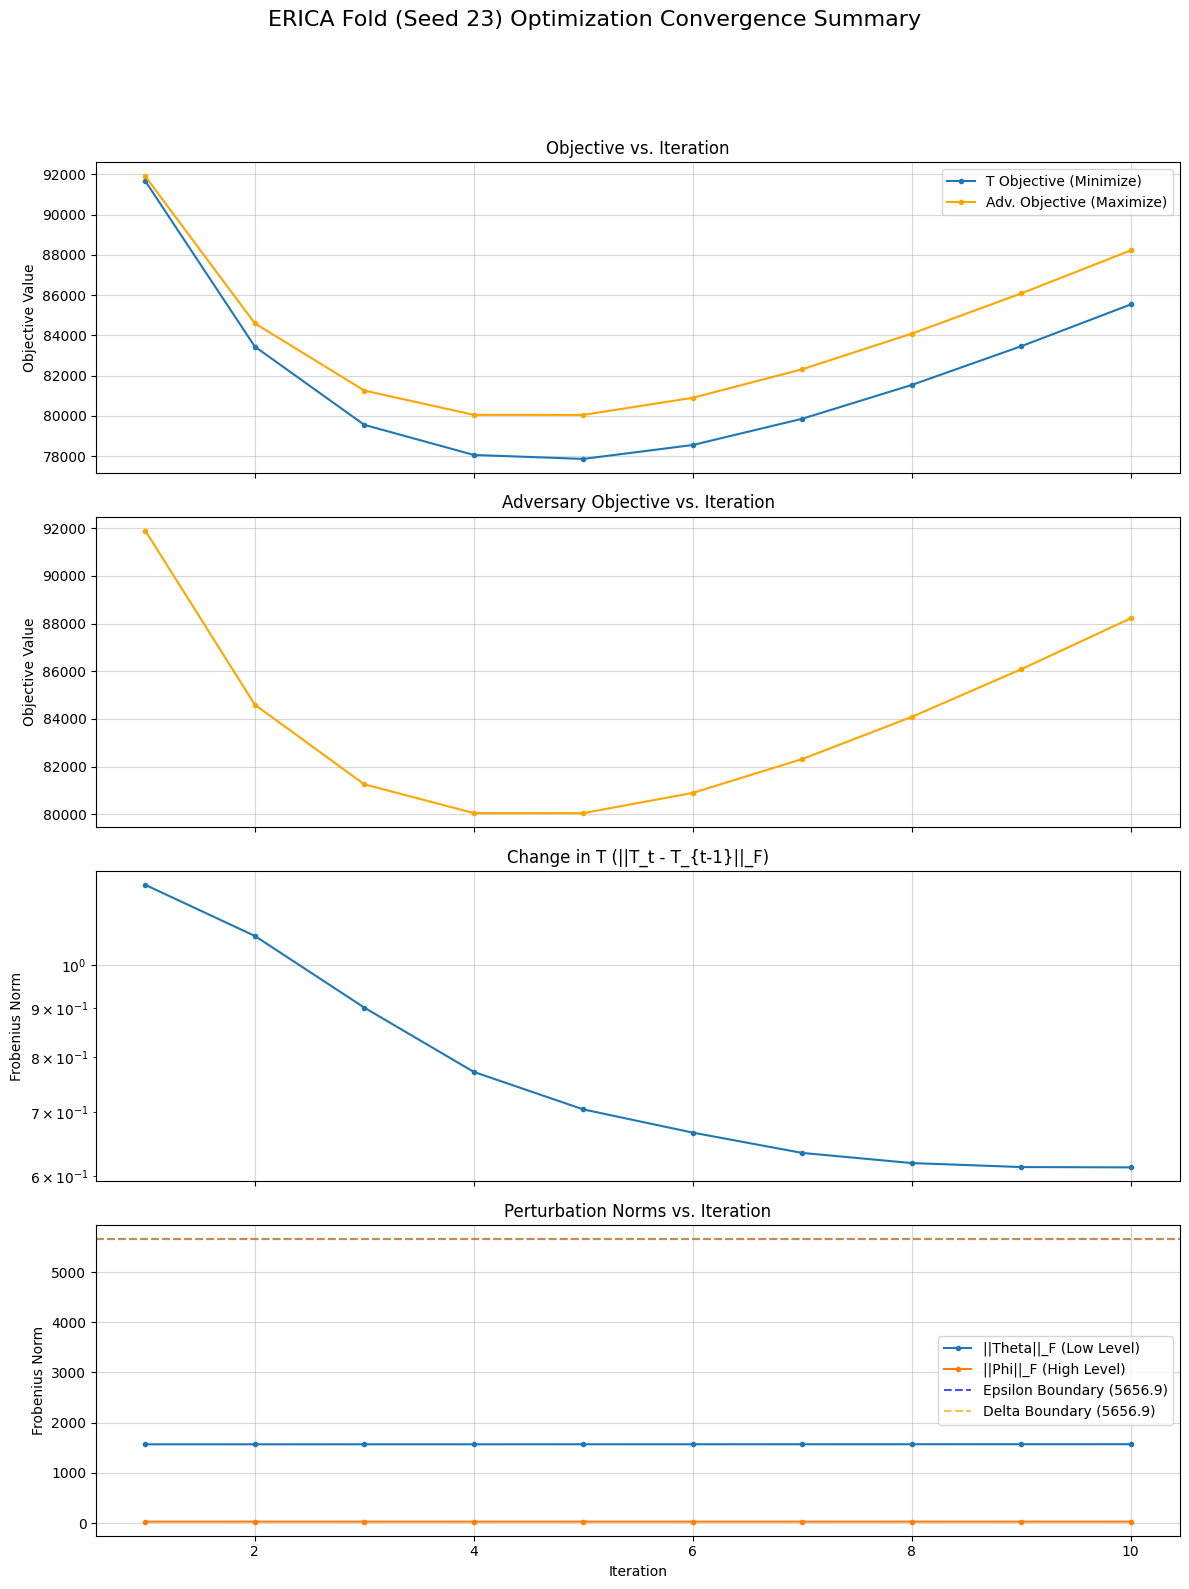

  ✓ Training completed for Fold 1

DiRoCA Training complete.
DiRoCA Training finished.


In [ ]:
import torch
import numpy as np
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

print("\n" + "="*20 + " Training DiRoCA Multiple Radii " + "="*20)

# --- Hyperparameters for DiRoCA ---
diroca_hyperparams = {
    'eta_min': 1e-3,
    'eta_max': 1e-3,
    'max_iter': 10000,
    'num_steps_min': 5,
    'num_steps_max': 2,
    'initialization': 'random',
    'optimizers': 'adam'
}

fixed_params_diroca = {
    'tol': 1e-4,
    'seed': 23,
    'robust_L': True,
    'robust_H': True,
    'experiment': 'cmnist',
    'gain': 0.0
}

# --- Multiple Radii for DiRoCA ---
radius_combinations = [(5.0, 5.0), (10.0, 10.0), (1.0, 1.0), (0.5, 0.5)]

# --- Execute Training for Multiple Radii ---
# Ensure noise tensors have the correct shape before passing
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

# Store results for each radius combination
all_results_diroca = {}
all_monitors_diroca = {}

print(f"Running DiRoCA for {len(radius_combinations)} radius combinations...")

for i, (epsilon, delta) in enumerate(radius_combinations):
    print(f"\n--- Running DiRoCA {i+1}/{len(radius_combinations)}: ε={epsilon}, δ={delta} ---")
    
    try:
        results_diroca, monitors_diroca = train_diroca_single_run(
            cv_folds, U_ll_hat_run, U_hl_hat_run, det_ll_dict, det_hl_dict,
            omega, diroca_hyperparams, fixed_params_diroca, epsilon, delta
        )
        
        # Store results with radius key
        radius_key = f"eps_{epsilon}_delta_{delta}"
        all_results_diroca[radius_key] = results_diroca
        all_monitors_diroca[radius_key] = monitors_diroca
        
        print(f"✓ Completed {radius_key}")
        
    except Exception as e:
        print(f"✗ Failed {radius_key}: {str(e)}")
        all_results_diroca[radius_key] = None
        all_monitors_diroca[radius_key] = None

print("\n" + "="*50)
print("DiRoCA Multi-Radius Training Complete!")
print("="*50)

# --- Summary of Results ---
print("\nResults Summary:")
for radius_key, results in all_results_diroca.items():
    if results is not None:
        print(f"  ✓ {radius_key}: Success")
    else:
        print(f"  ✗ {radius_key}: Failed")

# --- Access Individual Results ---
# Example: Access results for epsilon=200, delta=200
# results_200_200 = all_results_diroca['eps_200.0_delta_200.0']
# monitors_200_200 = all_monitors_diroca['eps_200.0_delta_200.0']


==================== Training GradCA ====================
Starting GradCA Training...
Hyperparameters: {'eta_min': 0.001, 'max_iter': 1000, 'num_steps_min': 5, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ENRICO Optimization: 100%|██████████| 1000/1000 [14:12<00:00,  1.17it/s]


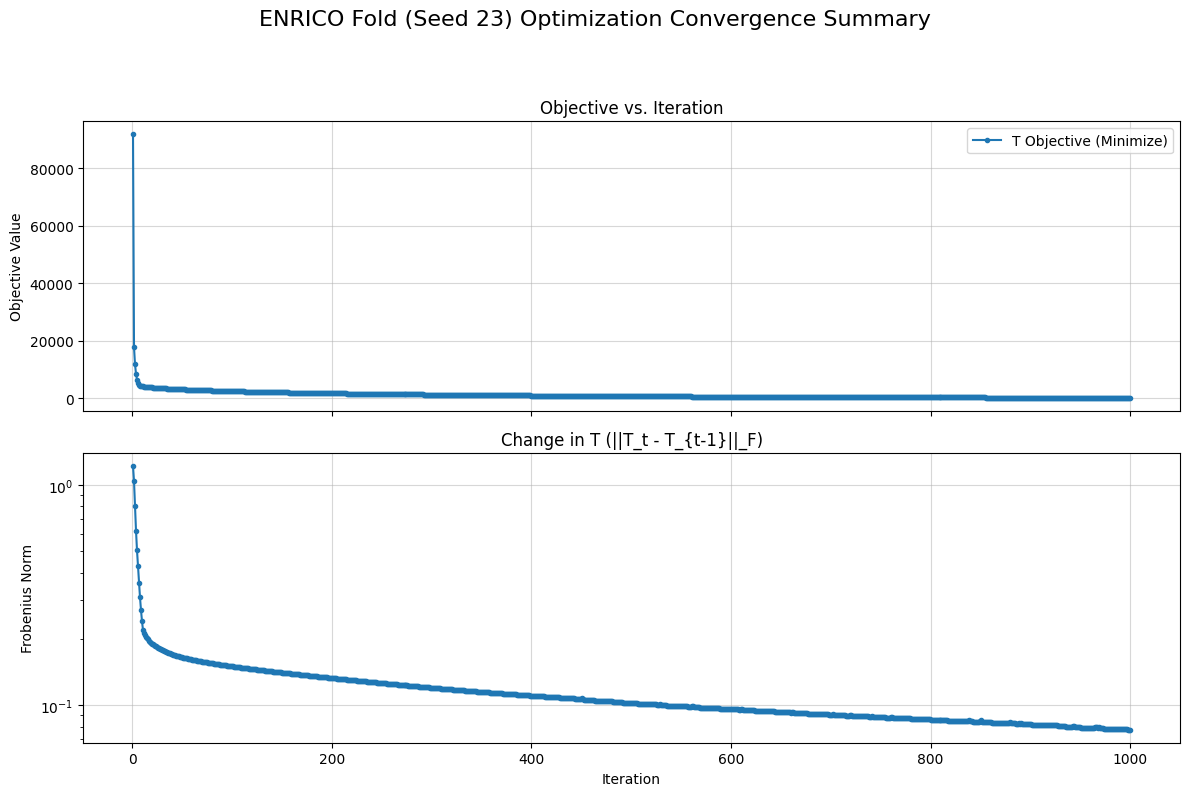

  ✓ Training completed for Fold 1

GradCA Training complete.
GradCA Training finished.


In [ ]:
import torch
import numpy as np
import os
import gc
import pandas as pd # Needed for monitor plots
import matplotlib.pyplot as plt # Needed for monitor plots
from tqdm import tqdm # Needed by monitor and optimizers

print("\n" + "="*20 + " Training GradCA " + "="*20)

# --- Hyperparameters for GradCA ---
gradca_hyperparams = {
    'eta_min': 1e-3,
    'max_iter': 1000, # Match DiRoCA's iterations
    'num_steps_min': 5, # Match DiRoCA's T steps
    'initialization': 'random', # Match DiRoCA's init
    'optimizers': 'adam'
}

fixed_params_gradca = {
    'tol': 1e-4, # Convergence tolerance
    'seed': 23,
    'experiment': 'cmnist',
    'gain': 0.0
}

# --- Execute Training ---
# Ensure noise tensors have the correct shape before passing
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

results_gradca, monitors_gradca = train_gradca_single_run(
    cv_folds, U_ll_hat_run, U_hl_hat_run, det_ll_dict, det_hl_dict,
    omega, gradca_hyperparams, fixed_params_gradca
)
print("GradCA Training finished.")
# Plots are generated by the monitor inside the training function


==================== Training BaryCA ====================
Starting BaryCA Training...
Hyperparameters: {'lr': 0.001, 'max_iter': 1000, 'tol': 1e-05}

--- Processing Fold 1/5 ---
Using device: cpu


BaryCA Optimization:   0%|          | 3/1000 [00:00<00:37, 26.49it/s]

Iter 0, Loss: 41864.683594


BaryCA Optimization:  20%|██        | 205/1000 [00:04<00:16, 48.82it/s]

Iter 200, Loss: 3289.708984


...

Iter 600, Loss: 2296.499512


BaryCA Optimization:  81%|████████  | 808/1000 [00:17<00:03, 51.16it/s]

Iter 800, Loss: 1990.863892


BaryCA Optimization: 100%|██████████| 1000/1000 [00:21<00:00, 46.04it/s]


Final BaryCA loss: 1745.835815


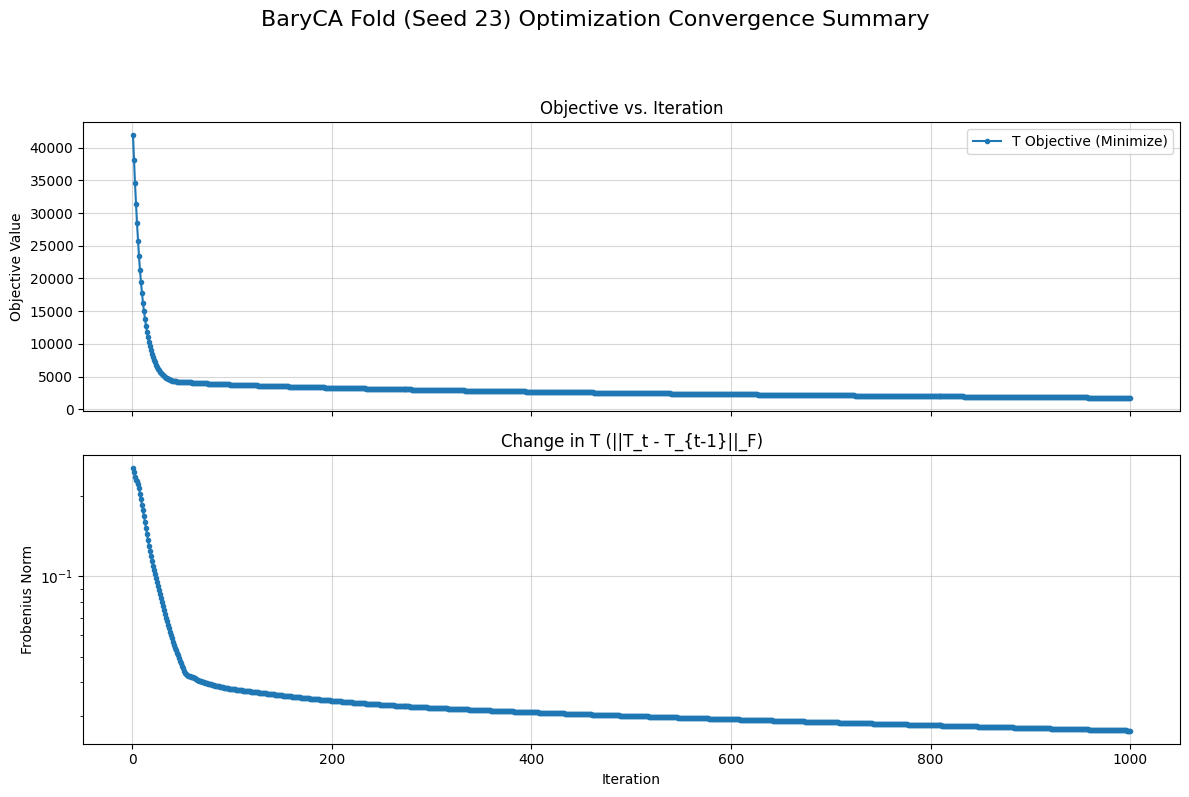

  ✓ Training completed for Fold 1

BaryCA Training complete.
BaryCA Training finished.


In [ ]:
import torch
import numpy as np
import os
import gc
import pandas as pd # Needed for monitor plots
import matplotlib.pyplot as plt # Needed for monitor plots
from tqdm import tqdm # Needed by monitor and optimizers

print("\n" + "="*20 + " Training BaryCA " + "="*20)

# --- Hyperparameters for BaryCA ---
baryca_hyperparams = {
    'lr': 1e-3,
    'max_iter': 1000, # Match DiRoCA's iterations
    'tol': 1e-5 # Use a potentially stricter tolerance
}

fixed_params_baryca = {
    'seed': 23
}

# --- Execute Training ---
# Ensure noise tensors have the correct shape before passing
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

results_baryca, monitors_baryca = train_baryca_single_run(
    cv_folds, U_ll_hat_run, U_hl_hat_run, det_ll_dict, det_hl_dict,
    omega, baryca_hyperparams, fixed_params_baryca
)
print("BaryCA Training finished.")
# Plots are generated by the monitor inside the training function

In [ ]:
import torch
import torch.nn.functional as F # Needed by wrapper
import numpy as np
import os
import gc

# --- Assume these are defined/loaded: ---
# cv_folds, Dll_samples, Dhl_samples
# train_abslingam_single_run (defined in Cell 1)
# perfect_abstraction, noisy_abstraction (defined or imported in Cell 1)
# ---------------------------------------------


print("\n" + "="*20 + " Training Abs-LiNGAM " + "="*20)

# --- Hyperparameters for Abs-LiNGAM ---
abslingam_hyperparams = {
    'tau_perfect': 1e-2,
    'tau_noisy': 1e-1
}

# Fixed parameters not really used, included for potential wrapper consistency
fixed_params_abslingam = {
    'seed': 23
}

# --- Execute Training ---
# Note: Needs Dll_samples and Dhl_samples
results_abslingam = train_abslingam_single_run(
    cv_folds, Dll_samples, Dhl_samples, abslingam_hyperparams
)
print("Abs-LiNGAM Training finished.")
# No plots generated for Abs-LiNGAM training


==================== Training Abs-LiNGAM ====================
Starting Abs-LiNGAM Training...
Hyperparameters: {'tau_perfect': 0.01, 'tau_noisy': 0.1}

--- Processing Fold 1/5 ---
  ✓ Computation completed for Fold 1

Abs-LiNGAM Computation complete.
Abs-LiNGAM Training finished.


In [ ]:
# --- Merge results from individual training runs (CORRECTED) ---
print("Merging results from all training runs...")

# Start with an empty dictionary
all_results = {}

# Add DiRoCA results (handle multiple radii)
if 'all_results_diroca' in locals() and isinstance(all_results_diroca, dict):
    # all_results_diroca has structure: {radius_key: {'diroca': {fold_key: ...}}}
    for radius_key, results_outer in all_results_diroca.items():
        if results_outer is not None and 'diroca' in results_outer:
            # Create method name like 'diroca_eps_20.0_delta_20.0'
            method_name = f"diroca_{radius_key}"
            # *** FIX: Store the INNER dictionary {fold_key: ...} ***
            all_results[method_name] = results_outer['diroca'] 
            print(f"  ✓ Added DiRoCA results for {radius_key}.")
        else:
            print(f"  ✗ Skipped DiRoCA results for {radius_key} (failed or invalid).")
else:
    print("  ✗ Warning: DiRoCA results ('all_results_diroca') not found.")

# Add GradCA results
# results_gradca has structure: {'gradca': {fold_key: ...}}
if 'results_gradca' in locals() and isinstance(results_gradca, dict) and 'gradca' in results_gradca:
    # *** FIX: Store the INNER dictionary {fold_key: ...} ***
    all_results['gradca'] = results_gradca['gradca']
    print("  ✓ Added GradCA results (single run).")
else:
    print("  ✗ Warning: GradCA results not found or invalid.")

# Add BaryCA results
# results_baryca has structure: {'baryca': {fold_key: ...}}
if 'results_baryca' in locals() and isinstance(results_baryca, dict) and 'baryca' in results_baryca:
    # *** FIX: Store the INNER dictionary {fold_key: ...} ***
    all_results['baryca'] = results_baryca['baryca']
    print("  ✓ Added BaryCA results (single run).")
else:
    print("  ✗ Warning: BaryCA results not found or invalid.")

# Add Abs-LiNGAM results
# results_abslingam has structure: {'abslingam': {fold_key: {'Perfect':..., 'Noisy':...}}}
if 'results_abslingam' in locals() and isinstance(results_abslingam, dict) and 'abslingam' in results_abslingam:
    # *** FIX: Store the INNER dictionary {fold_key: ...} ***
    all_results['abslingam'] = results_abslingam['abslingam']
    print("  ✓ Added Abs-LiNGAM results (single run).")
else:
    print("  ✗ Warning: Abs-LiNGAM results not found or invalid.")


# Verify the structure (This loop will now work correctly)
print("\nStructure of merged 'all_results':")
if not all_results:
    print("  'all_results' is empty. Cannot proceed with evaluation.")
else:
    # Top-level keys are now method names (e.g., 'diroca_eps_...', 'gradca', 'abslingam')
    # Values are dictionaries keyed by fold ('fold_0', 'fold_1', ...)
    for method_name, fold_dict in all_results.items():
        if isinstance(fold_dict, dict):
             valid_folds = sum(1 for fold_data in fold_dict.values()
                               if isinstance(fold_data, dict) and 'error' not in fold_data)
             total_folds = len(fold_dict)
             print(f"  - {method_name}: Contains results for {valid_folds}/{total_folds} folds.")
             # Check for AbsLin variants
             if method_name == 'abslingam' and valid_folds > 0:
                 first_fold_keys = list(fold_dict[list(fold_dict.keys())[0]].keys())
                 print(f"    (Contains Abs-LiNGAM variants: {first_fold_keys})")
        else:
             print(f"  - {method_name}: Entry is not a dictionary - Invalid structure.")

print("\nMerging complete.")

In [ ]:
# --- Fixed Visualization Cell ---
import matplotlib.pyplot as plt
import torch
import numpy as np
import re

print("\n" + "="*20 + " Visualizing Adversarial Perturbations (Fixed) " + "="*20)

# --- 1. Select DiRoCA Run and Fold ---
fold_key_to_show = 'fold_0'
diroca_key_toplevel = next((k for k in all_results if k.startswith('diroca_eps_')), None)

if diroca_key_toplevel is None:
    print("Error: No DiRoCA results found.")
else:
    print(f"Using DiRoCA results: {diroca_key_toplevel}")
    
    # --- FIXED: Direct access to DiRoCA results ---
    # all_results structure: {'diroca_eps_20.0_delta_20.0': {'fold_0': {'eps_20.0_delta_20.0': {...}}}}
    if fold_key_to_show not in all_results[diroca_key_toplevel]:
        print(f"Error: Fold {fold_key_to_show} not found in {diroca_key_toplevel}")
        run_result = None
    else:
        fold_data = all_results[diroca_key_toplevel][fold_key_to_show]
        
        # Find the run key (should be 'eps_20.0_delta_20.0' or similar)
        run_keys = [k for k in fold_data.keys() if k.startswith('eps_')]
        if not run_keys:
            print(f"Error: No run keys found in fold data. Available keys: {list(fold_data.keys())}")
            run_result = None
        else:
            run_key = run_keys[0]  # Use first run key
            run_result = fold_data[run_key]
            
            if 'error' in run_result:
                print(f"Error in run result: {run_result['error']}")
                run_result = None
            else:
                print(f"Using run key: {run_key}")

    if run_result is not None:
        # --- 2. Extract Data ---
        final_Theta_ll = run_result.get('final_Theta_ll')
        if final_Theta_ll is None: 
            print("Theta not found.")
        else:
            if not isinstance(final_Theta_ll, torch.Tensor): 
                final_Theta_ll = torch.tensor(final_Theta_ll, dtype=torch.float32)
            
            epsilon_run = run_result.get('epsilon', 'Unknown')
            fold_index = int(fold_key_to_show.split('_')[-1])
            train_indices = cv_folds[fold_index]['train']

            U_ll_train_img = U_ll_hat[train_indices]
            U_ll_train = U_ll_train_img.view(U_ll_train_img.shape[0], -1)
            det_ll_train_obs = det_ll_dict[None][train_indices]

            # --- 3. Calculate Images ---
            det_pixels_train = det_ll_train_obs[:, :3072]
            clean_recon_pixels = det_pixels_train + U_ll_train
            worst_case_pixels = clean_recon_pixels + final_Theta_ll

            # --- 4. Select Samples ---
            num_samples_to_show = 4
            N_train = U_ll_train.shape[0]
            if num_samples_to_show > N_train: 
                num_samples_to_show = N_train
            np.random.seed(fold_index + 42)
            sample_indices = np.random.choice(N_train, num_samples_to_show, replace=False)

            # --- 5. Reshape Function ---
            def reshape_and_rescale_for_plot(pixel_vector_neg1_1):
                """Reshapes and rescales from [-1, 1] to [0, 1] for imshow."""
                try:
                    if not isinstance(pixel_vector_neg1_1, torch.Tensor):
                        pixel_vector_neg1_1 = torch.tensor(pixel_vector_neg1_1)
                    pixel_vector_neg1_1 = pixel_vector_neg1_1.cpu()
                    
                    expected_elements = 3 * 32 * 32
                    if pixel_vector_neg1_1.numel() != expected_elements:
                        print(f"Warning: Unexpected numel {pixel_vector_neg1_1.numel()} in reshape. Expected {expected_elements}. Returning zeros.")
                        return np.zeros((32, 32, 3))
                    
                    img_chw = pixel_vector_neg1_1.view(3, 32, 32) 
                    img_hwc = img_chw.permute(1, 2, 0)
                    img_np = img_hwc.numpy()
                    img_rescaled = (img_np + 1.0) / 2.0
                    return np.clip(img_rescaled, 0.0, 1.0) 
                except Exception as e:
                    print(f"Error in reshape_and_rescale: {e}. Input shape: {pixel_vector_neg1_1.shape}")
                    return np.zeros((32, 32, 3))

            def reshape_for_plot(pixel_vector):
                """Reshapes for noise visualization."""
                try:
                    if not isinstance(pixel_vector, torch.Tensor):
                        pixel_vector = torch.tensor(pixel_vector)
                    pixel_vector = pixel_vector.cpu()
                    if pixel_vector.numel() != 3072: 
                        return np.zeros((32, 32, 3))
                    img_chw = pixel_vector.view(3, 32, 32)
                    img_hwc = img_chw.permute(1, 2, 0)
                    return img_hwc.numpy()
                except Exception as e: 
                    return np.zeros((32, 32, 3))

            # --- 6. Plotting ---
            fig, axes = plt.subplots(num_samples_to_show, 5, figsize=(20, 4 * num_samples_to_show))
            if num_samples_to_show == 1: 
                axes = np.array([axes])
            fig.suptitle(f'Visualizing Adversarial Perturbations ({diroca_key_toplevel}, Fold {fold_index})', fontsize=16, y=1.02)

            for i, idx in enumerate(sample_indices):
                # Col 1: Deterministic D (Rescaled)
                ax = axes[i, 0]
                img = reshape_and_rescale_for_plot(det_pixels_train[idx])
                ax.imshow(img)
                ax.set_title(f'Sample {idx}: D (Rescaled)')
                ax.axis('off')
                
                # Col 2: Abduced Noise U (Diverging map)
                ax = axes[i, 1]
                img_noise_vec = U_ll_train[idx]
                img = reshape_for_plot(img_noise_vec)
                norm = np.max(np.abs(img)) if img.size > 0 else 0.1
                ax.imshow(img, cmap='RdBu_r', vmin=-norm-1e-6, vmax=norm+1e-6)
                ax.set_title(f'Sample {idx}: U')
                ax.axis('off')
                
                # Col 3: Adversary Theta (Diverging map)
                ax = axes[i, 2]
                img_pert_vec = final_Theta_ll[idx]
                img = reshape_for_plot(img_pert_vec)
                norm = np.max(np.abs(img)) if img.size > 0 else 0.1
                ax.imshow(img, cmap='RdBu_r', vmin=-norm-1e-6, vmax=norm+1e-6)
                ax.set_title(f'Sample {idx}: Θ')
                ax.axis('off')

                # Col 4: Clean Reconstructed D+U (Rescaled)
                ax = axes[i, 3]
                img = reshape_and_rescale_for_plot(clean_recon_pixels[idx])
                ax.imshow(img)
                ax.set_title(f'Sample {idx}: Clean (D+U)')
                ax.axis('off')
                
                # Col 5: Worst-Case D+U+Theta (Rescaled)
                ax = axes[i, 4]
                img = reshape_and_rescale_for_plot(worst_case_pixels[idx])
                ax.imshow(img)
                ax.set_title(f'Sample {idx}: Worst (D+U+Θ)')
                ax.axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.98])
            plt.show()

            print("✓ Visualization completed successfully!")

    else:
        print("✗ Could not access DiRoCA results for visualization")

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import re

print("\n" + "="*20 + " Plotting HL Distributions (Original vs. Recon vs. Worst) " + "="*20)

# --- 1. Select DiRoCA Run and Fold ---
fold_to_show = 0
fold_key = f'fold_{fold_to_show}'

# Use the first DiRoCA key found in all_results
diroca_key_toplevel = next((k for k in all_results if k.startswith('diroca_eps_')), None)

if diroca_key_toplevel is None:
    print("Error: No DiRoCA results found in 'all_results'.")
else:
    print(f"Using DiRoCA results: {diroca_key_toplevel}")
    
    # --- FIXED: Direct access to DiRoCA results ---
    if fold_key not in all_results[diroca_key_toplevel]:
        print(f"Error: Fold {fold_key} not found in {diroca_key_toplevel}")
        run_result = None
    else:
        fold_data = all_results[diroca_key_toplevel][fold_key]
        
        # Find the run key (should be 'eps_20.0_delta_20.0' or similar)
        run_keys = [k for k in fold_data.keys() if k.startswith('eps_')]
        if not run_keys:
            print(f"Error: No run keys found in fold data. Available keys: {list(fold_data.keys())}")
            run_result = None
        else:
            run_key = run_keys[0]  # Use first run key
            run_result = fold_data[run_key]
            
            if 'error' in run_result:
                print(f"Error in run result: {run_result['error']}")
                run_result = None
            else:
                print(f"Using run key: {run_key}")

    # --- Check if run_result is valid before proceeding ---
    if run_result is not None:
        # --- Ensure final_Phi_hl is a tensor ---
        final_Phi_hl = run_result.get('final_Phi_hl')
        if final_Phi_hl is None:
            print("Error: final_Phi_hl not found in run result")
        else:
            if not isinstance(final_Phi_hl, torch.Tensor):
                final_Phi_hl = torch.tensor(final_Phi_hl, dtype=torch.float32)

            train_indices = cv_folds[fold_to_show]['train']
            
            # Ensure U_hl_hat exists and has correct shape
            if 'U_hl_hat' not in locals() or U_hl_hat.ndim < 2:
                print("Error: U_hl_hat not defined or has unexpected shape.")
            else:
                U_hl_train = U_hl_hat[train_indices]  # Shape (N_train, 1)
                det_hl_train_dict = {k: v[train_indices] for k, v in det_hl_dict.items()}

                # --- Find intervention objects ---
                eta_do_digit_8 = None
                eta_do_color_0 = None
                eta_do_digit_8_color_0 = None
                
                # Use det_hl_dict keys (which should be intervention objects)
                for eta_key in det_hl_dict.keys():
                    if eta_key is not None and hasattr(eta_key, 'vv'):
                        iv_dict = eta_key.vv()
                        if iv_dict == {D_HL: 8}: 
                            eta_do_digit_8 = eta_key
                        elif iv_dict == {C_HL: 0}: 
                            eta_do_color_0 = eta_key
                        elif iv_dict == {D_HL: 8, C_HL: 0}: 
                            eta_do_digit_8_color_0 = eta_key

                if None in [eta_do_digit_8, eta_do_color_0, eta_do_digit_8_color_0]:
                    print("Warning: Could not find all required intervention objects in det_hl_dict keys.")
                else:
                    # --- Calculate Values ---
                    hl_feature_values = {}
                    interventions_to_plot = {
                        "Observational": None, 
                        "do(Digit=8)": eta_do_digit_8,
                        "do(Color=0)": eta_do_color_0, 
                        "do(Digit=8, Color=0)": eta_do_digit_8_color_0
                    }
                    
                    print("Calculating feature values...")
                    for name, eta_key in tqdm(interventions_to_plot.items()):
                        if eta_key not in det_hl_train_dict or eta_key not in Dhl_samples:
                            print(f"Skipping {name}: Key {eta_key} missing in data.")
                            continue
                            
                        det_hl_full = det_hl_train_dict[eta_key]
                        det_hl_feature = det_hl_full[:, 20:]  # Last column (Image_ feature)
                        original_hl_full = Dhl_samples[eta_key][train_indices]
                        original_hl_feature = original_hl_full[:, 20:]
                        
                        device = det_hl_feature.device
                        U_hl_train_dev = U_hl_train.to(device)
                        final_Phi_hl_dev = final_Phi_hl.to(device)
                        
                        clean_feature = det_hl_feature + U_hl_train_dev
                        worst_case_feature = det_hl_feature + U_hl_train_dev + final_Phi_hl_dev
                        
                        hl_feature_values[name] = {
                            'original': original_hl_feature.cpu().numpy().flatten(),
                            'clean_recon': clean_feature.cpu().numpy().flatten(),
                            'worst_recon': worst_case_feature.cpu().numpy().flatten()
                        }

                    # --- Plot Histograms ---
                    if not hl_feature_values: 
                        print("No values calculated.")
                    else:
                        print("Generating comparison plots...")
                        num_valid_plots = len(hl_feature_values)
                        fig, axes = plt.subplots(num_valid_plots, 1, figsize=(10, 5 * num_valid_plots), sharex=True)
                        if num_valid_plots == 1: 
                            axes = [axes]
                        fig.suptitle(f'Original vs. Reconstructed HL Feature Distributions ({diroca_key_toplevel}, Fold {fold_to_show})', fontsize=16, y=1.01)
                        
                        plot_idx = 0
                        for name, values in hl_feature_values.items():
                            ax = axes[plot_idx]
                            ax.hist(values['original'], bins=50, alpha=0.5, label='Original Data', density=True, color='blue')
                            ax.hist(values['clean_recon'], bins=50, alpha=0.7, label='Clean Recon (D+U)', density=True, color='green')
                            ax.hist(values['worst_recon'], bins=50, alpha=0.5, label='Worst-Case (D+U+Φ)', density=True, color='red')
                            ax.set_title(name)
                            ax.set_ylabel('Density')
                            ax.legend()
                            ax.grid(True, linestyle='--', alpha=0.6)
                            plot_idx += 1
                        
                        axes[-1].set_xlabel('Mean Pixel Intensity (the HL Image_ variable)')
                        plt.tight_layout(rect=[0, 0.03, 1, 0.99])
                        plt.show()

                        # --- Print Statistics ---
                        print("\n--- Statistics Comparison (Original vs. Clean Recon vs. Worst-Case) ---")
                        for name, values in hl_feature_values.items():
                            print(f"\n{name}:")
                            mean_orig, std_orig = np.mean(values['original']), np.std(values['original'])
                            mean_clean, std_clean = np.mean(values['clean_recon']), np.std(values['clean_recon'])
                            mean_worst, std_worst = np.mean(values['worst_recon']), np.std(values['worst_recon'])
                            
                            print(f"  Original Data    : Mean={mean_orig:+.4f}, Std={std_orig:.4f}")
                            print(f"  Clean Recon (D+U): Mean={mean_clean:+.4f}, Std={std_clean:.4f} (vs Orig: M diff {mean_clean-mean_orig:+.4f}, Std diff {std_clean-std_orig:+.4f})")
                            print(f"  Worst-Case(D+U+Φ): Mean={mean_worst:+.4f}, Std={std_worst:.4f}")
                            print(f"    => Adversary Shift (Worst - Clean Recon): Mean Shift {mean_worst-mean_clean:+.4f}, Std Change {std_worst-std_clean:+.4f}")

    else:
        print("✗ Could not access DiRoCA results for high-level distribution analysis")

# Evaluation

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

# --- Contamination Function (Noise on specific dims, Corrected loc=0.0) ---
def apply_huber_contamination_cmnist(clean_data, alpha, noise_scale, noise_dims, seed=None, loc=0.0):
    """Contaminates only specific dimensions (pixels or features) with zero-mean noise."""
    if alpha == 0 or noise_scale == 0:
        return clean_data if isinstance(clean_data, torch.Tensor) else torch.tensor(clean_data, dtype=torch.float32)

    data_tensor = clean_data if isinstance(clean_data, torch.Tensor) else torch.tensor(clean_data, dtype=torch.float32)
    data_cont = data_tensor.clone().to(torch.float32)
    data_to_noise = data_cont[:, noise_dims].data

    rng = np.random.default_rng(seed)
    # --- CORRECTED: Use loc=0.0 for zero-mean noise ---
    #noise = rng.normal(loc=0.0, scale=noise_scale, size=data_to_noise.shape).astype(np.float32)
    noise = rng.normal(loc=loc, scale=noise_scale, size=data_to_noise.shape).astype(np.float32)
    noise_tensor = torch.tensor(noise, dtype=torch.float32, device=data_tensor.device)
    noisy_slice = data_to_noise + noise_tensor

    if alpha >= 1.0:
        data_cont[:, noise_dims] = noisy_slice
        return data_cont

    n_samples = data_tensor.shape[0]
    n_contaminate = int(alpha * n_samples)
    if n_contaminate == 0: return data_cont

    idx_to_contaminate = rng.choice(n_samples, size=n_contaminate, replace=False)
    data_cont[idx_to_contaminate, noise_dims] = noisy_slice[idx_to_contaminate]
    return data_cont

# --- Error Calculation ---
def calculate_empirical_error_flat(T_matrix, Dll_test_flat, Dhl_test):
    """Calculates abstraction error for the linear T matrix on flattened data."""
    try:
        T_matrix = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        Dll_test_flat = Dll_test_flat if isinstance(Dll_test_flat, torch.Tensor) else torch.tensor(Dll_test_flat, dtype=torch.float32)
        Dhl_test = Dhl_test if isinstance(Dhl_test, torch.Tensor) else torch.tensor(Dhl_test, dtype=torch.float32)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T_matrix = T_matrix.to(device)
        Dll_test_flat = Dll_test_flat.to(device)
        Dhl_test = Dhl_test.to(device)

        if T_matrix.shape[1] != Dll_test_flat.shape[1]: 
            # print(f"Eval Error - Dim mismatch T vs LL: T={T_matrix.shape}, LL={Dll_test_flat.shape}")
            return float('inf')
        if T_matrix.shape[0] != Dhl_test.shape[1]: 
            # print(f"Eval Error - Dim mismatch T vs HL: T={T_matrix.shape}, HL={Dhl_test.shape}")
            return float('inf')

        with torch.no_grad():
            Dhl_pred = Dll_test_flat @ T_matrix.T
            diff = Dhl_pred - Dhl_test
            err = torch.norm(diff, p='fro')**2 / max(1, diff.shape[0])
        return float(err.item())

    except Exception as e:
        print(f"Error in calculate_empirical_error_flat: {e}")
        return float('inf')

print("Evaluation functions defined.")

Evaluation functions defined.


In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
import gc
import re # Make sure re is imported

# --- Assume these are defined/loaded: ---
# cv_folds, omega, Dll_samples, Dhl_samples
# all_results (Created in the corrected Merge Cell above)
# apply_huber_contamination_cmnist, calculate_empirical_error_flat (defined in Cell 2)
# output_dir
# ---------------------------------------------

# --- Ensure output_dir exists ---
if 'output_dir' not in locals():
    output_dir = 'data/cmnist/results_empirical'
    print(f"Warning: 'output_dir' not set, using default: {output_dir}")
os.makedirs(output_dir, exist_ok=True)

print("\n--- Starting Simplified Evaluation for ALL Methods (alpha=0 & alpha=1) ---")

# --- Define Evaluation Parameters ---
N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 1.0 # Or 0.2 as in your last output
ALPHA_VALUES_TO_TEST = [0.0, 1.0]

evaluation_records = []

# --- Determine Total Runs for Progress Bar ---
total_methods_trained = 0
for method_group_key in all_results: # e.g., 'diroca_eps_...', 'gradca', 'abslingam'
    method_data_inner = all_results[method_group_key]
    if isinstance(method_data_inner, dict):
        for fold_key in method_data_inner:
            fold_data = method_data_inner[fold_key]
            if isinstance(fold_data, dict) and 'error' not in fold_data:
                total_methods_trained += len(fold_data)
total_configs = total_methods_trained * len(ALPHA_VALUES_TO_TEST) * N_TRIALS

if total_configs == 0:
     print("Error: No valid training results found in 'all_results'. Cannot run evaluation.")
else:
    pbar_eval = tqdm(total=total_configs, desc="Evaluating All Methods (alpha=0 & 1)")

    LL_PIXEL_DIMS = slice(0, 3072)
    HL_FEATURE_DIM = slice(20, None)

    # --- Evaluation Loop for ALL Methods (CORRECTED) ---
    # method_group_key examples: 'diroca_eps_...', 'gradca', 'baryca', 'abslingam'
    for method_group_key, method_results_inner in all_results.items():
        
        # method_results_inner NOW contains {fold_key: ...}
        if not isinstance(method_results_inner, dict):
             print(f"Skipping invalid entry structure for {method_group_key}")
             continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                 print(f"Warning: Unexpected key '{fold_key}' instead of fold key under '{method_group_key}'. Skipping.")
                 continue

            if 'error' in fold_data: # Skip failed folds
                 method_runs_per_fold = len(fold_data) if isinstance(fold_data, dict) else 1
                 # pbar_eval.update(method_runs_per_fold * len(ALPHA_VALUES_TO_TEST) * N_TRIALS) # Update pbar for skipped
                 continue

            i = int(fold_key.split('_')[-1]) # Get fold index

            # run_key examples: 'eps_...', 'gradca_run', 'baryca_run', 'Abs-LiNGAM (Perfect)'
            for run_key, run_result in fold_data.items():
                 if 'error' in run_result or run_result.get('T_matrix') is None: # Skip failed runs
                      pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                      continue

                 T_matrix = run_result['T_matrix']
                 test_idx = run_result['test_indices']
                 if test_idx is None: # Skip if no test indices
                     pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                     continue

                 # --- Construct Method Name (Corrected) ---
                 if method_group_key.startswith('diroca_'):
                     eval_method_name = f"DiRoCA ({run_key})"
                 elif method_group_key == 'gradca': eval_method_name = "GradCA"
                 elif method_group_key == 'baryca': eval_method_name = "BaryCA"
                 elif method_group_key == 'abslingam':
                     eval_method_name = run_key # This is now 'Abs-LiNGAM (Perfect)' or 'Abs-LiNGAM (Noisy)'
                 else: eval_method_name = f"{method_group_key}_{run_key}"
                 # --- End Name Correction ---

                 # --- Inner Evaluation Loop ---
                 for alpha in ALPHA_VALUES_TO_TEST:
                     noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                     loc_ll = 10000.0  # e.g., Add a bias of 1.0 to pixels
                     loc_hl = 0.0  # e.g., Add NO bias to the feature
                     for trial in range(N_TRIALS):
                         trial_errors = []
                         for iota, eta in list(omega.items()): # Use list
                             try:
                                 if iota not in Dll_samples or eta not in Dhl_samples: continue
                                 ll_images, _, ll_digits, ll_colors = Dll_samples[iota]
                                 max_idx = max(test_idx) if len(test_idx)>0 else -1
                                 if max_idx >= len(ll_images): continue
                                 ll_images_test=ll_images[test_idx]; ll_digits_test=ll_digits[test_idx]; ll_colors_test=ll_colors[test_idx];
                                 Dhl_test_clean = Dhl_samples[eta][test_idx]

                                 seed = hash((i, run_key, float(alpha), float(noise_scale), trial, str(iota))) % (2**32)
                                 ll_images_test_flat = ll_images_test.view(ll_images_test.shape[0], -1)
                                 ll_images_cont_flat = apply_huber_contamination_cmnist(ll_images_test_flat, alpha, noise_scale, LL_PIXEL_DIMS, seed=seed, loc=loc_ll)
                                 Dhl_test_cont = apply_huber_contamination_cmnist(Dhl_test_clean, alpha, noise_scale, HL_FEATURE_DIM, seed=seed, loc=loc_hl)

                                 ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                                 ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()
                                 device = ll_images_cont_flat.device
                                 Dll_test_cont_flat_full = torch.cat([ll_images_cont_flat, ll_digits_onehot.to(device), ll_colors_onehot.to(device)], dim=1)

                                 error = calculate_empirical_error_flat(T_matrix, Dll_test_cont_flat_full, Dhl_test_cont)
                                 if not np.isnan(error) and error != float('inf'): trial_errors.append(error)
                             except Exception as e:
                                 print(f"ERROR inner loop: {e} | Context: M{eval_method_name}, F{i}, R{run_key}, A{alpha}, N{noise_scale}, T{trial}, Iota{iota}")
                                 trial_errors.append(np.nan)

                         record = {
                             'method': eval_method_name, 'fold': i, 'alpha': float(alpha),
                             'noise_scale': float(noise_scale), 'trial': trial,
                             'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan }
                         if method_group_key.startswith('diroca_'):
                             record['train_epsilon'] = run_result.get('epsilon', np.nan)
                             record['train_delta'] = run_result.get('delta', np.nan)
                         evaluation_records.append(record)
                         pbar_eval.update(1)
                         del ll_images_test, ll_digits_test, ll_colors_test, Dhl_test_clean, ll_images_test_flat, ll_images_cont_flat, Dhl_test_cont, ll_digits_onehot, ll_colors_onehot, Dll_test_cont_flat_full
                         if 'error' in locals(): del error
                         if 'trial_errors' in locals(): del trial_errors[:]

    pbar_eval.close()
    full_results_df = pd.DataFrame(evaluation_records)

    # --- Save Full DataFrame ---
    eval_output_path = os.path.join(output_dir, "all_methods_evaluation_results.pkl")
    full_results_df.to_pickle(eval_output_path)
    print(f"\nEvaluation results for all methods saved to {eval_output_path}")

    # --- Basic Analysis (No Plotting) ---
    print("\n--- Evaluation Complete. Analyzing results... ---")
    if full_results_df.empty:
        print("No evaluation results generated.")
    else:
        pd.set_option('display.max_rows', None); pd.set_option('display.width', 1000)

        df_clean = full_results_df[np.isclose(full_results_df['alpha'], 0.0)]
        summary_clean = df_clean.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')
        print("\n--- Results on Clean Data (α = 0.0, σ = 0.0) ---")
        print(summary_clean)

        df_noisy = full_results_df[np.isclose(full_results_df['alpha'], 1.0)]
        summary_noisy = df_noisy.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')
        print(f"\n--- Results on Fully Noisy Data (α = 1.0, σ = {NOISE_SCALE_FOR_ALPHA1:.1f}) ---")
        print(summary_noisy)

        pd.reset_option('display.max_rows'); pd.reset_option('display.width')

    print("\n✅ Simplified Evaluation for All Methods Complete.")


--- Starting Simplified Evaluation for ALL Methods (alpha=0 & alpha=1) ---


Evaluating All Methods (alpha=0 & 1): 100%|██████████| 50/50 [00:03<00:00, 14.45it/s]


Evaluation results for all methods saved to data/cmnist/results_empirical/all_methods_evaluation_results.pkl

--- Evaluation Complete. Analyzing results... ---

--- Results on Clean Data (α = 0.0, σ = 0.0) ---
                                    mean  std
method                                       
Abs-LiNGAM (Perfect)            0.050363  0.0
Abs-LiNGAM (Noisy)              0.075431  0.0
DiRoCA (eps_20.0_delta_20.0)   17.385292  0.0
GradCA                        226.749556  0.0
BaryCA                        553.502686  0.0

--- Results on Fully Noisy Data (α = 1.0, σ = 1.0) ---
                                      mean            std
method                                                   
Abs-LiNGAM (Noisy)            1.093678e+00       0.037694
Abs-LiNGAM (Perfect)          4.407474e+08     381.502545
DiRoCA (eps_20.0_delta_20.0)  9.083275e+08    6707.941028
GradCA                        1.961009e+09   48645.009089
BaryCA                        9.296288e+09  221490.968026

✅ Si

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.70274..0.98225164].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7625273..0.6545694].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7051952..0.77228695].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7570253..0.6700643].



==================== Visualizing Contaminated Evaluation Samples ====================


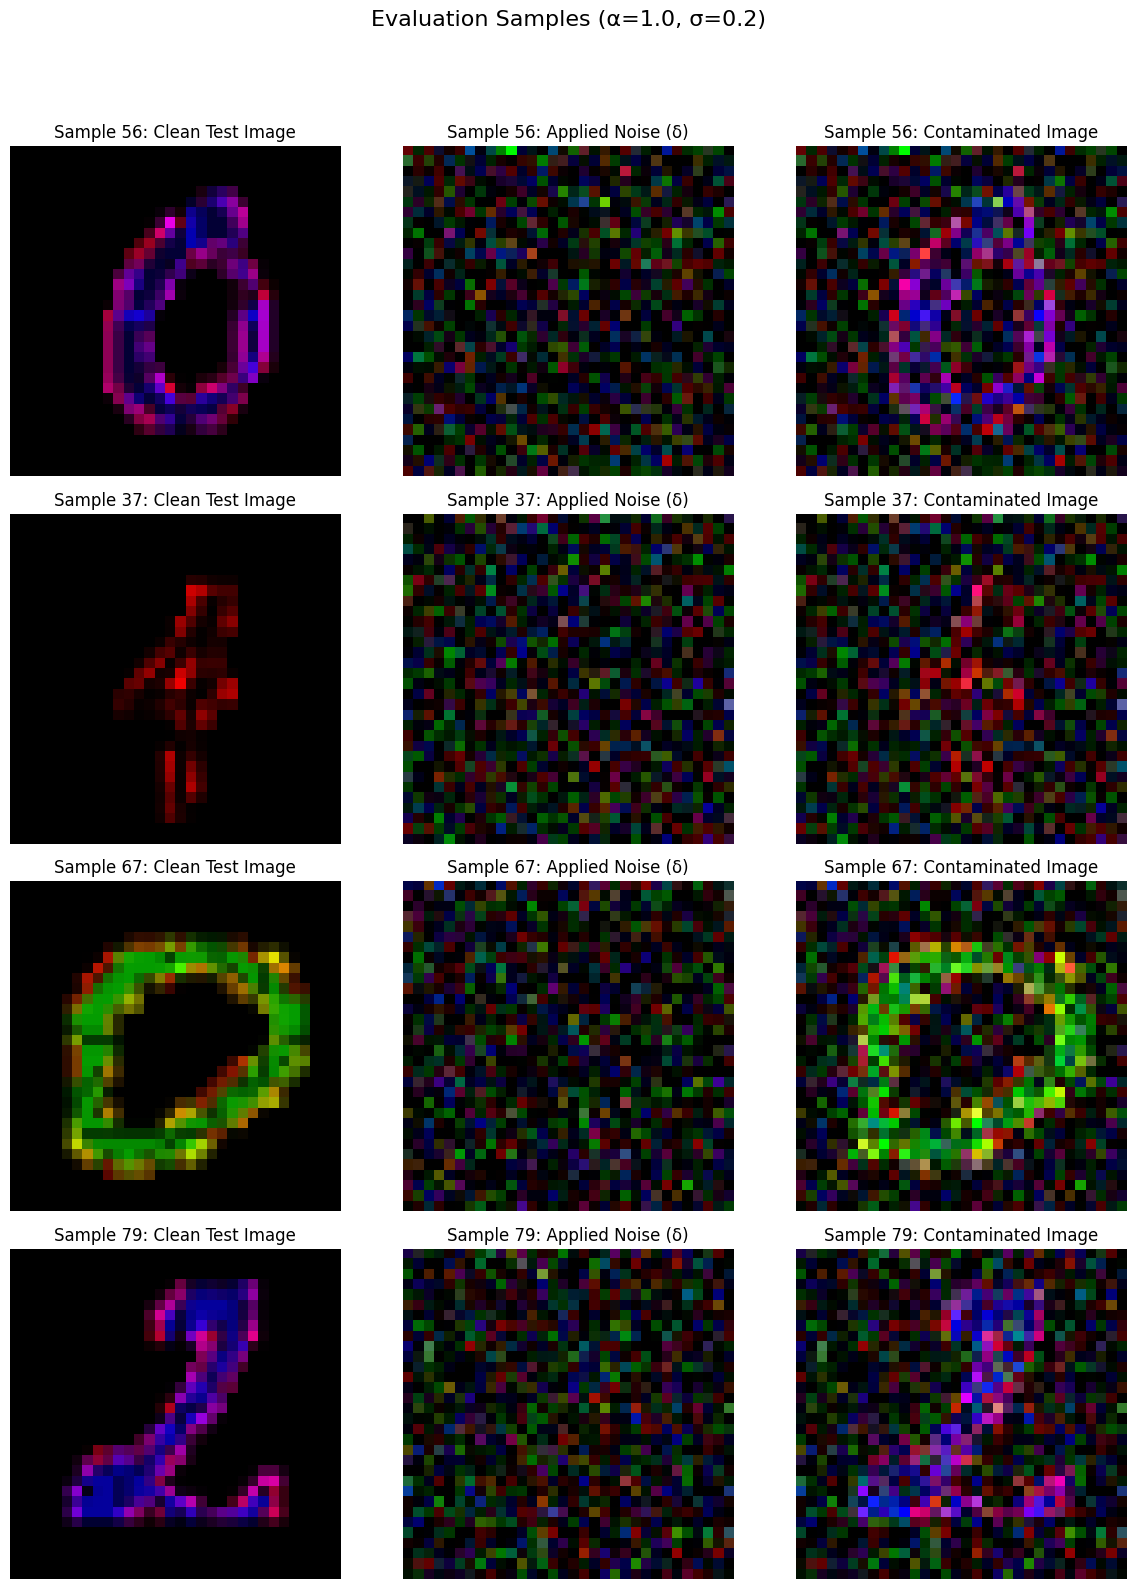

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import re # Added

# --- Assume these are defined/loaded: ---
# cv_folds, omega, Dll_samples, Dhl_samples
# apply_huber_contamination_cmnist (defined previously)
# LL_PIXEL_DIMS (defined previously, slice(0, 3072))
# ---------------------------------------------

print("\n" + "="*20 + " Visualizing Contaminated Evaluation Samples " + "="*20)

# --- Parameters for Visualization ---
fold_to_show = 0
fold_key = f'fold_{fold_to_show}'
# Use observational data for simplicity, or choose a specific intervention key
intervention_key = None # or list(omega.keys())[1]
alpha_eval = 1.0 # Simulate the fully noisy condition
noise_scale_eval = 0.2 # Noise scale used in evaluation
num_samples_to_show = 4
fixed_seed = 42 # Use a seed for reproducibility of noise

# --- Get Clean Test Data ---
test_idx = cv_folds[fold_to_show]['test']

try:
    if intervention_key not in Dll_samples:
        raise KeyError(f"Intervention key {intervention_key} not found in Dll_samples.")

    ll_images, _, ll_digits, ll_colors = Dll_samples[intervention_key]
    ll_images_test = ll_images[test_idx] # Shape (N_test, 3, 32, 32)
    ll_digits_test = ll_digits[test_idx]
    ll_colors_test = ll_colors[test_idx]
    N_test = ll_images_test.shape[0]

except KeyError as e:
    print(f"Error accessing data for evaluation visualization: {e}")
    # Set dummy value to prevent crash, error message printed
    ll_images_test = torch.zeros(num_samples_to_show, 3, 32, 32) 
    N_test = 0

if N_test > 0 :
    # --- Flatten Clean Images ---
    ll_images_test_flat = ll_images_test.view(N_test, -1) # Shape (N_test, 3072)

    # --- Apply Contamination to get Noisy Images ---
    # Note: apply_huber... returns the full contaminated image X_ll + delta_ll
    ll_images_cont_flat = apply_huber_contamination_cmnist(
        ll_images_test_flat, alpha_eval, noise_scale_eval, LL_PIXEL_DIMS, seed=fixed_seed
    )

    # --- Calculate the Applied Noise (delta_ll) ---
    # delta_ll = (X_ll + delta_ll) - X_ll
    applied_noise_flat = ll_images_cont_flat - ll_images_test_flat # Shape (N_test, 3072)

    # --- Select Samples ---
    if num_samples_to_show > N_test: num_samples_to_show = N_test
    np.random.seed(fixed_seed + 1) # Use a different seed for sample selection
    sample_indices = np.random.choice(N_test, num_samples_to_show, replace=False)

    # --- Reshape Function (Rescales [0,1] range, assuming Dll_samples are 0-1) ---
    def reshape_eval_for_plot(pixel_vector):
        """Reshapes and ensures data is [0, 1] for imshow."""
        try:
            if not isinstance(pixel_vector, torch.Tensor): pixel_vector = torch.tensor(pixel_vector)
            pixel_vector = pixel_vector.cpu()
            if pixel_vector.numel() != 3072: return np.zeros((32, 32, 3))
            img_chw = pixel_vector.view(3, 32, 32)
            img_hwc = img_chw.permute(1, 2, 0)
            img_np = img_hwc.numpy()
            # Clip to [0, 1] as original MNIST/generated images should be in this range
            return np.clip(img_np, 0.0, 1.0)
        except Exception as e: return np.zeros((32, 32, 3))

    # --- Plotting ---
    fig, axes = plt.subplots(num_samples_to_show, 3, figsize=(12, 4 * num_samples_to_show)) # 3 columns
    if num_samples_to_show == 1: axes = np.array([axes])
    fig.suptitle(f'Evaluation Samples (α={alpha_eval:.1f}, σ={noise_scale_eval:.1f})', fontsize=16, y=1.02)

    for i, idx in enumerate(sample_indices):
        # Col 1: Clean Test Image (X_ll)
        ax = axes[i, 0]
        img_clean = reshape_eval_for_plot(ll_images_test_flat[idx])
        ax.imshow(img_clean)
        ax.set_title(f'Sample {idx}: Clean Test Image')
        ax.axis('off')

        # Col 2: Applied Evaluation Noise (δ_ll)
        ax = axes[i, 1]
        img_noise_vec = applied_noise_flat[idx]
        # Use reshape_for_plot from previous cells (handles view/permute/numpy)
        img_noise = reshape_for_plot(img_noise_vec) 
        norm = np.max(np.abs(img_noise)) if img_noise.size > 0 else 0.1
        ax.imshow(img_noise, cmap='RdBu_r', vmin=-norm-1e-6, vmax=norm+1e-6) # Use diverging map
        ax.set_title(f'Sample {idx}: Applied Noise (δ)')
        ax.axis('off')

        # Col 3: Contaminated Test Image (X_ll + δ_ll)
        ax = axes[i, 2]
        img_cont = reshape_eval_for_plot(ll_images_cont_flat[idx])
        ax.imshow(img_cont)
        ax.set_title(f'Sample {idx}: Contaminated Image')
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

else:
    print("Could not load test images for visualization.")

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
import gc

print("\n" + "="*20 + " Starting 'DiRoCA Challenge' Evaluation (Corrected Access) " + "="*20)

# --- Parameters ---
N_TRIALS = 5
ALPHA_TO_TEST = 1.0
evaluation_records_adv = []

# --- 1. Get the Adversarial Noise from the DiRoCA run ---
fold_to_show = 0
fold_key = f'fold_{fold_to_show}'
diroca_key_toplevel = 'diroca_eps_20.0_delta_20.0' # Or the key for the run you want to test against
diroca_run_key_internal = 'eps_20.0_delta_20.0'

# --- CORRECTED ACCESS PATH ---
# Removed the extra ['diroca'] from the path
if (diroca_key_toplevel in all_results and
    fold_key in all_results[diroca_key_toplevel] and
    diroca_run_key_internal in all_results[diroca_key_toplevel][fold_key]):
    
    # Access the specific run result directly
    run_result_diroca = all_results[diroca_key_toplevel][fold_key][diroca_run_key_internal]
    final_Theta_ll = torch.tensor(run_result_diroca['final_Theta_ll'], dtype=torch.float32)
    final_Phi_hl = torch.tensor(run_result_diroca['final_Phi_hl'], dtype=torch.float32)
    train_indices = cv_folds[fold_to_show]['train'] # Use train indices matching the fold
    
    # Get the corresponding TRAINING data splits (since Theta/Phi match N_train)
    U_ll_train = U_ll_hat_fixed[train_indices] # Use fixed/flattened noise
    U_hl_train = U_hl_hat_fixed[train_indices]
    det_ll_train_dict = {k: v[train_indices] for k, v in det_ll_dict.items()}
    det_hl_train_dict = {k: v[train_indices] for k, v in det_hl_dict.items()}

    print(f"Loaded adversarial noise Θ ({final_Theta_ll.shape}) and Φ ({final_Phi_hl.shape}) from {diroca_key_toplevel}")

    # --- 2. Evaluation Loop (using TRAINING data, as Θ/Φ match it) ---
    # Estimate total runs
    total_runs_adv = 0
    for method_group_key in all_results:
         if fold_key in all_results[method_group_key]:
             total_runs_adv += len(all_results[method_group_key][fold_key])
    
    pbar_eval_adv = tqdm(total=total_runs_adv * N_TRIALS * len(omega), desc="DiRoCA Challenge Eval")

    # Iterate through all methods in all_results to compare them
    for method_group_key, method_results_inner in all_results.items():
        # method_results_inner is {fold_key: ...}
        if fold_key not in method_results_inner: # Check if this method has results for the fold
             print(f"Skipping {method_group_key}: No results for {fold_key}")
             continue
             
        fold_data = method_results_inner[fold_key]
        if 'error' in fold_data: continue # Skip failed fold

        # Iterate through runs in the fold (e.g., 'gradca_run', 'Abs-LiNGAM (Perfect)')
        for run_key, run_result in fold_data.items():
            if 'error' in run_result or run_result.get('T_matrix') is None: continue
                 
            T_matrix = run_result['T_matrix']
                 
            # Construct method name
            if method_group_key.startswith('diroca_'): eval_method_name = f"DiRoCA ({run_key})"
            elif method_group_key == 'gradca': eval_method_name = "GradCA"
            elif method_group_key == 'baryca': eval_method_name = "BaryCA"
            elif method_group_key == 'abslingam': eval_method_name = run_key # Is 'Abs-LiNGAM (Perfect)' etc.
            else: eval_method_name = f"{method_group_key}_{run_key}"

            for trial in range(N_TRIALS): # Trials are redundant here as noise is fixed, but keep for structure
                trial_errors = []
                for iota, eta in list(omega.items()):
                    try:
                        # Get Deterministic D and Abduced U (from TRAINING set)
                        if iota not in det_ll_train_dict or eta not in det_hl_train_dict: continue
                        det_ll_full = det_ll_train_dict[iota]
                        det_hl_full = det_hl_train_dict[eta]
                             
                        # Reconstruct LL: D_ll + U_ll + Θ_ll
                        image_part_ll = det_ll_full[:, :3072]; label_part_ll = det_ll_full[:, 3072:]
                        # Ensure all tensors are on the same device
                        device = det_ll_full.device
                        image_part_noisy = image_part_ll + U_ll_train.to(device) + final_Theta_ll.to(device)
                        Dll_test_adv = torch.cat([image_part_noisy, label_part_ll], dim=1)

                        # Reconstruct HL: D_h + U_h + Φ_h
                        label_part_hl = det_hl_full[:, :20]; feature_part_hl = det_hl_full[:, 20:]
                        feature_part_noisy = feature_part_hl + U_hl_train.to(device) + final_Phi_hl.to(device)
                        Dhl_test_adv = torch.cat([label_part_hl, feature_part_noisy], dim=1)
                             
                        # Calculate Error
                        error = calculate_empirical_error_flat(T_matrix, Dll_test_adv, Dhl_test_adv)
                        if not np.isnan(error) and error != float('inf'): trial_errors.append(error)
                             
                    except Exception as e:
                        print(f"ERROR adv eval: {e} | M{eval_method_name}, F{fold_key}, R{run_key}, T{trial}, I{iota}")
                        trial_errors.append(np.nan)
                    pbar_eval_adv.update(1)

                evaluation_records_adv.append({
                    'method': eval_method_name, 'fold': fold_to_show, 'alpha': ALPHA_TO_TEST,
                    'noise_scale': f'Adversarial(eps={epsilon})', 'trial': trial,
                    'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan
                })
    
    # Adjust pbar if total was overestimated (e.g. loops skipped)
    pbar_eval_adv.close()
    
    # --- 3. Print Results ---
    adv_results_df = pd.DataFrame(evaluation_records_adv)
    print("\n--- Evaluation Complete: 'DiRoCA Challenge' (Noise = DiRoCA's Adversary) ---")
    if adv_results_df.empty:
        print("No adversarial evaluation results generated.")
    else:
        pd.set_option('display.max_rows', None); pd.set_option('display.width', 1000)
        # Group by method and trial, then average trials
        summary_adv = adv_results_df.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')
        print(summary_adv)
        pd.reset_option('display.max_rows'); pd.reset_option('display.width')
        
else:
    # This error message will now be correct
    print(f"Could not load DiRoCA run {diroca_key_toplevel} to perform adversarial evaluation.")
    print("Check 'all_results' structure and keys.")


==================== Starting 'DiRoCA Challenge' Evaluation (Corrected Access) ====================
Loaded adversarial noise Θ (torch.Size([800, 3072])) and Φ (torch.Size([800, 1])) from diroca_eps_20.0_delta_20.0


DiRoCA Challenge Eval:  90%|█████████ | 225/250 [00:01<00:00, 113.63it/s]


--- Evaluation Complete: 'DiRoCA Challenge' (Noise = DiRoCA's Adversary) ---
                                       mean  std
method                                          
Abs-LiNGAM (Noisy)                 2.673460  0.0
DiRoCA (eps_20.0_delta_20.0)       3.688380  0.0
Abs-LiNGAM (Perfect)               6.897816  0.0
GradCA                        421750.531250  0.0
BaryCA                        516072.156250  0.0


In [110]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import pandas as pd

# --- New Contamination Function: Background-Only Noise ---
def apply_background_noise_cmnist(ll_images_tensor, ll_shapes_tensor,
                                  noise_loc, noise_scale, seed=None):
    """
    Applies noise ONLY to the background pixels of the low-level images.
    Returns the contaminated flat pixel tensor (X_ll + delta_ll).
    
    Args:
        ll_images_tensor (Tensor): Clean LL images (N, 3, 32, 32), range [0, 1].
        ll_shapes_tensor (Tensor): Corresponding LL shapes (N, 1, 32, 32), range [-1, 1].
        noise_loc (float): Mean of the noise to add.
        noise_scale (float): Std dev of the noise to add.
        seed (int): Random seed.
    """
    if noise_scale == 0 and noise_loc == 0:
        return ll_images_tensor.view(ll_images_tensor.shape[0], -1) # Return clean flat

    device = ll_images_tensor.device
    
    # 1. Create the background mask from the shape tensor
    # Background is where the shape tensor is -1 (or close to it)
    # Shape is (N, 1, 32, 32), expand to (N, 3, 32, 32)
    bg_mask = (ll_shapes_tensor < -0.9).expand_as(ll_images_tensor)
    
    # 2. Generate noise for ALL pixels
    rng = np.random.default_rng(seed)
    full_noise = rng.normal(loc=noise_loc, scale=noise_scale,
                            size=ll_images_tensor.shape).astype(np.float32)
    full_noise_tensor = torch.tensor(full_noise, dtype=torch.float32, device=device)
    
    # 3. Select noise *only* where the mask is True
    background_noise = torch.where(bg_mask, full_noise_tensor, 0.0)
    
    # 4. Add background noise to clean image and flatten
    contaminated_images = ll_images_tensor + background_noise
    
    return contaminated_images.view(contaminated_images.shape[0], -1) # (N, 3072)


# --- New Evaluation Loop: "Realistic Background Shift" ---
def run_evaluation_background_shift(all_results, Dll_samples, Dhl_samples, omega, 
                                    cv_folds, noise_loc, noise_scale, n_trials=5):
    """
    Evaluates all models on data where only the LL background is shifted,
    and the HL target is recalculated.
    """
    print("\n" + "="*20 + f" Starting Evaluation: Realistic Background Shift (loc={noise_loc}, scale={noise_scale}) " + "="*20)
    
    evaluation_records = []
    
    # --- Determine Total Runs ---
    total_methods_trained = 0
    for method_group_key in all_results:
        method_data_inner = all_results[method_group_key]
        if isinstance(method_data_inner, dict):
            for fold_key in method_data_inner:
                fold_data = method_data_inner[fold_key]
                if isinstance(fold_data, dict) and 'error' not in fold_data:
                    total_methods_trained += len(fold_data)
    total_configs = total_methods_trained * n_trials * len(omega)
    
    if total_configs == 0:
        print("Error: No valid training results found. Cannot evaluate.")
        return pd.DataFrame()
        
    pbar_eval = tqdm(total=total_configs, desc=f"Evaluating BG Shift (loc={noise_loc})")

    # --- Slices (Unchanged) ---
    LL_PIXEL_DIMS = slice(0, 3072)
    HL_FEATURE_DIM = slice(20, None)

    for method_group_key, method_results_inner in all_results.items():
        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'): continue
            if 'error' in fold_data: continue
            
            i = int(fold_key.split('_')[-1]) # Fold index

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None: continue
                
                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None: continue

                # ... (Construct method name as before) ...
                if method_group_key.startswith('diroca_'): eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca': eval_method_name = "GradCA"
                elif method_group_key == 'baryca': eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam': eval_method_name = run_key
                else: eval_method_name = f"{method_group_key}_{run_key}"

                for trial in range(n_trials):
                    trial_errors = []
                    for iota, eta in list(omega.items()):
                        try:
                            # 1. Get Clean Test Data Components
                            if iota not in Dll_samples or eta not in Dhl_samples: continue
                            ll_images, ll_shapes, ll_digits, ll_colors = Dll_samples[iota]
                            max_idx = max(test_idx) if len(test_idx)>0 else -1
                            if max_idx >= len(ll_images): continue

                            ll_images_test = ll_images[test_idx]
                            ll_shapes_test = ll_shapes[test_idx] # Get the shapes
                            ll_digits_test = ll_digits[test_idx]
                            ll_colors_test = ll_colors[test_idx]
                            Dhl_test_clean_full = Dhl_samples[eta][test_idx] # For labels
                            
                            # 2. Apply Contamination to LL Background ONLY
                            seed = hash((i, run_key, float(noise_loc), float(noise_scale), trial, str(iota))) % (2**32)
                            ll_images_cont_flat = apply_background_noise_cmnist(
                                ll_images_test, ll_shapes_test, noise_loc, noise_scale, seed=seed
                            ) # Shape (N_test, 3072)
                            
                            # 3. Reconstruct FULL Contaminated LL Vector
                            ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                            ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()
                            device = ll_images_cont_flat.device
                            Dll_test_cont_flat_full = torch.cat([ll_images_cont_flat,
                                                                 ll_digits_onehot.to(device),
                                                                 ll_colors_onehot.to(device)], dim=1)
                            
                            # 4. Re-calculate the HL Target based on contaminated LL
                            # This is the "true" abstraction of the noisy image
                            ll_images_cont_reshaped = ll_images_cont_flat.view(-1, 3, 32, 32)
                            #Dhl_test_cont_feature = ll_images_cont_reshaped.mean(dim=[1, 2, 3], keepdim=True) # (N_test, 1)
                            Dhl_test_cont_feature = ll_images_cont_reshaped.mean(dim=[1, 2, 3], keepdim=False).unsqueeze(1) # CORRECT (Rank 2)
                            
                            # Get clean labels
                            Dhl_test_clean_labels = Dhl_test_clean_full[:, :20]
                            # Create final HL target: [Clean Labels, Contaminated Feature]
                            Dhl_test_cont_full = torch.cat([Dhl_test_clean_labels, Dhl_test_cont_feature.to(Dhl_test_clean_labels.device)], dim=1)

                            # 5. Calculate Error
                            error = calculate_empirical_error_flat(T_matrix, Dll_test_cont_flat_full, Dhl_test_cont_full)
                            if not np.isnan(error) and error != float('inf'): trial_errors.append(error)
                            
                        except Exception as e:
                            print(f"ERROR adv eval: {e} | M{eval_method_name}, F{i}, R{run_key}, T{trial}, I{iota}")
                            trial_errors.append(np.nan)
                        pbar_eval.update(1)

                    evaluation_records.append({
                        'method': eval_method_name, 'fold': i, 'alpha': 1.0, # Denote as fully noisy
                        'noise_scale': f"BG_loc={noise_loc}", 'trial': trial,
                        'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan
                    })
                    
    pbar_eval.close()
    
    # --- Print Results ---
    adv_results_df = pd.DataFrame(evaluation_records)
    print("\n--- Evaluation Complete: 'Realistic Background Shift' ---")
    if adv_results_df.empty:
        print("No evaluation results generated.")
    else:
        pd.set_option('display.max_rows', None); pd.set_option('display.width', 1000)
        summary_adv = adv_results_df.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')
        print(f"Results for shift: loc={noise_loc}, scale={noise_scale}")
        print(summary_adv)
        pd.reset_option('display.max_rows'); pd.reset_option('display.width')
        
    return adv_results_df

In [112]:
# --- Run the "Realistic Background Shift" Evaluation ---

# --- Test 1: Background bias (loc=5.0), low variance (scale=0.1) ---
# This simulates a systematic bias, like light bleed in the camera sensor
run_evaluation_background_shift(
    all_results, Dll_samples, Dhl_samples, omega, cv_folds,
    noise_loc=5.0, 
    noise_scale=1.1, 
    n_trials=5
)

# --- Test 2: Background bias (loc=0.0), high variance (scale=1.0) ---
# This simulates random background noise ("static")
run_evaluation_background_shift(
    all_results, Dll_samples, Dhl_samples, omega, cv_folds,
    noise_loc=0.0, 
    noise_scale=1.0, 
    n_trials=5
)


==================== Starting Evaluation: Realistic Background Shift (loc=5.0, scale=1.1) ====================


Evaluating BG Shift (loc=5.0): 100%|██████████| 250/250 [00:03<00:00, 75.05it/s]



--- Evaluation Complete: 'Realistic Background Shift' ---
Results for shift: loc=5.0, scale=1.1
                                       mean         std
method                                                 
Abs-LiNGAM (Noisy)                15.552948    0.001393
Abs-LiNGAM (Perfect)              68.464054    0.068047
DiRoCA (eps_20.0_delta_20.0)    2640.964370   10.977795
GradCA                         84030.435469  401.673291
BaryCA                        136766.814062  439.264924

==================== Starting Evaluation: Realistic Background Shift (loc=0.0, scale=1.0) ====================


Evaluating BG Shift (loc=0.0): 100%|██████████| 250/250 [00:03<00:00, 81.77it/s]


--- Evaluation Complete: 'Realistic Background Shift' ---
Results for shift: loc=0.0, scale=1.0
                                      mean         std
method                                                
Abs-LiNGAM (Noisy)                0.075702    0.000034
Abs-LiNGAM (Perfect)              0.733039    0.008641
DiRoCA (eps_20.0_delta_20.0)    825.157601    4.807791
GradCA                        43944.261641  235.178937
BaryCA                        48582.029766  463.134982


,method,fold,alpha,noise_scale,trial,error
0,DiRoCA (eps_20.0_delta_20.0),0,1.0,BG_loc=0.0,0,823.399139
1,DiRoCA (eps_20.0_delta_20.0),0,1.0,BG_loc=0.0,1,832.657703
2,DiRoCA (eps_20.0_delta_20.0),0,1.0,BG_loc=0.0,2,819.749683
3,DiRoCA (eps_20.0_delta_20.0),0,1.0,BG_loc=0.0,3,826.371759
4,DiRoCA (eps_20.0_delta_20.0),0,1.0,BG_loc=0.0,4,823.609723
5,GradCA,0,1.0,BG_loc=0.0,0,44291.222656
6,GradCA,0,1.0,BG_loc=0.0,1,43938.513281
7,GradCA,0,1.0,BG_loc=0.0,2,43663.306250
8,GradCA,0,1.0,BG_loc=0.0,3,44014.308203
9,GradCA,0,1.0,BG_loc=0.0,4,43813.957812


In [123]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import pandas as pd

# --- Contamination Function 1: Background-Only Noise (CORRECTED) ---
def apply_background_noise_cmnist(ll_images_tensor, ll_shapes_tensor,
                                  loc_bg, scale_bg, loc_digit, scale_digit, # <-- CORRECTED ARGUMENTS
                                  seed=None):
    """
    Applies correlated noise: one value for background, one for digit pixels.
    Returns the contaminated flat pixel tensor (X_ll + delta_ll).
    """
    device = ll_images_tensor.device
    N, C, H, W = ll_images_tensor.shape
    
    # 1. Create masks from the shape tensor
    # Digit mask: where shape is > -0.9 (i.e., not pure background)
    digit_mask = (ll_shapes_tensor.to(device) > -0.9).expand_as(ll_images_tensor)
    # Background mask: the inverse
    bg_mask = ~digit_mask
    
    # 2. Generate noise
    rng = np.random.default_rng(seed)
    
    # Sample ONE noise value per image for background
    noise_vals_bg = rng.normal(loc=loc_bg, scale=scale_bg, size=(N, C, 1, 1))
    noise_tensor_bg = torch.tensor(noise_vals_bg, dtype=torch.float32, device=device)
    
    # Sample ONE noise value per image for digit
    noise_vals_digit = rng.normal(loc=loc_digit, scale=scale_digit, size=(N, C, 1, 1))
    noise_tensor_digit = torch.tensor(noise_vals_digit, dtype=torch.float32, device=device)

    # 3. Create structured noise tensor
    # Apply bg noise where bg_mask is true, digit noise where digit_mask is true
    structured_noise = torch.where(bg_mask, noise_tensor_bg, noise_tensor_digit)
    
    # 4. Add to clean image and flatten
    contaminated_images = ll_images_tensor + structured_noise
    
    return contaminated_images.view(N, -1) # (N, 3072)


# --- Contamination Function 2: Multiplicative Noise (This one worked) ---
def apply_multiplicative_noise_cmnist(ll_images_tensor, ll_shapes_tensor,
                                      noise_loc, noise_scale, seed=None):
    """
    Applies multiplicative noise: X_cont = X + (X * noise)
    Returns the contaminated flat pixel tensor.
    """
    device = ll_images_tensor.device
    N, C, H, W = ll_images_tensor.shape
    
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=noise_loc, scale=noise_scale, size=ll_images_tensor.shape).astype(np.float32)
    noise_tensor = torch.tensor(noise, dtype=torch.float32, device=device)
    
    contaminated_images = ll_images_tensor + (ll_images_tensor * noise_tensor)
    
    return contaminated_images.view(N, -1) # (N, 3072)


# --- Main Evaluation Loop (Unchanged, but now calls fixed functions) ---
def run_evaluation_structured(all_results, Dll_samples, Dhl_samples, omega, 
                              cv_folds, contamination_function, noise_params, n_trials=5):
    """
    Evaluates all models using a specific contamination function and parameters.
    CRUCIALLY: It recalculates the HL target based on the contaminated LL data.
    """
    noise_desc = ", ".join([f"{k}={v}" for k,v in noise_params.items()])
    print("\n" + "="*20 + f" Starting Evaluation: {contamination_function.__name__} ({noise_desc}) " + "="*20)
    
    evaluation_records = []
    
    # ... (Progress Bar Setup - same as before) ...
    total_methods_trained = 0
    for method_group_key in all_results:
        method_data_inner = all_results[method_group_key]
        if isinstance(method_data_inner, dict):
            for fold_key in method_data_inner:
                fold_data = method_data_inner[fold_key]
                if isinstance(fold_data, dict) and 'error' not in fold_data:
                    total_methods_trained += len(fold_data)
    total_configs = total_methods_trained * n_trials * len(omega)
    pbar_eval = tqdm(total=total_configs, desc=f"Evaluating {contamination_function.__name__}")

    for method_group_key, method_results_inner in all_results.items():
        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'): continue
            if 'error' in fold_data: continue
            
            i = int(fold_key.split('_')[-1]) # Fold index

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None: continue
                
                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None: continue

                # ... (Construct method name as before) ...
                if method_group_key.startswith('diroca_'): eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca': eval_method_name = "GradCA"
                elif method_group_key == 'baryca': eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam': eval_method_name = run_key
                else: eval_method_name = f"{method_group_key}_{run_key}"

                for trial in range(n_trials):
                    trial_errors = []
                    for iota, eta in list(omega.items()):
                        try:
                            # 1. Get Clean Test Data Components
                            if iota not in Dll_samples or eta not in Dhl_samples: continue
                            ll_images, ll_shapes, ll_digits, ll_colors = Dll_samples[iota]
                            max_idx = max(test_idx) if len(test_idx)>0 else -1
                            if max_idx >= len(ll_images): continue

                            ll_images_test = ll_images[test_idx]
                            ll_shapes_test = ll_shapes[test_idx] # Get the shapes
                            ll_digits_test = ll_digits[test_idx]
                            ll_colors_test = ll_colors[test_idx]
                            Dhl_test_clean_full = Dhl_samples[eta][test_idx] # For labels
                            
                            # 2. Apply Contamination
                            seed = hash((i, run_key, noise_desc, trial, str(iota))) % (2**32)
                            # This call now works with either contamination function
                            ll_images_cont_flat = contamination_function(
                                ll_images_test, ll_shapes_test, seed=seed, **noise_params
                            ) # Shape (N_test, 3072)
                            
                            # 3. Reconstruct FULL Contaminated LL Vector
                            ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                            ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()
                            device = ll_images_cont_flat.device
                            Dll_test_cont_flat_full = torch.cat([ll_images_cont_flat,
                                                                 ll_digits_onehot.to(device),
                                                                 ll_colors_onehot.to(device)], dim=1)
                            
                            # 4. Re-calculate the HL Target based on contaminated LL
                            # (Using the corrected .mean(dim=1, keepdim=True))
                            Dhl_test_cont_feature = ll_images_cont_flat.mean(dim=1, keepdim=True) # (N_test, 1)
                            Dhl_test_clean_labels = Dhl_test_clean_full[:, :20]
                            Dhl_test_cont_full = torch.cat([Dhl_test_clean_labels.to(Dhl_test_cont_feature.device), Dhl_test_cont_feature], dim=1)

                            # 5. Calculate Error
                            error = calculate_empirical_error_flat(T_matrix, Dll_test_cont_flat_full, Dhl_test_cont_full)
                            if not np.isnan(error) and error != float('inf'): trial_errors.append(error)
                            
                        except Exception as e:
                             print(f"ERROR: {e} | M{eval_method_name}, F{i}, R{run_key}, T{trial}, I{iota}")
                             trial_errors.append(np.nan)
                        pbar_eval.update(1)

                    evaluation_records.append({
                        'method': eval_method_name, 'fold': i, 'alpha': 1.0, # Denote as fully noisy
                        'noise_scale': noise_desc, 'trial': trial,
                        'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan
                    })
                    
    pbar_eval.close()
    
    # --- Print Results ---
    adv_results_df = pd.DataFrame(evaluation_records)
    print(f"\n--- Evaluation Complete: {contamination_function.__name__} ---")
    if adv_results_df.empty:
        print("No evaluation results generated.")
    else:
        pd.set_option('display.max_rows', None); pd.set_option('display.width', 1000)
        summary_adv = adv_results_df.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')
        print(f"Results for shift: {noise_desc}")
        print(summary_adv)
        pd.reset_option('display.max_rows'); pd.reset_option('display.width')
        
    return adv_results_df

print("Corrected evaluation functions defined.")

Corrected evaluation functions defined.


In [124]:
# --- Run the "Realistic Background Shift" Evaluation ---
# This test should now work
print("\nRunning Test 1: Structured Background/Digit Noise")
correlated_noise_params = {
    'loc_bg': 0.1, 
    'scale_bg': 0.05,
    'loc_digit': 1.0, 
    'scale_digit': 0.5
}
df_correlated = run_evaluation_structured(
    all_results, Dll_samples, Dhl_samples, omega, cv_folds,
    apply_background_noise_cmnist, 
    correlated_noise_params, 
    n_trials=5
)


# --- Run the Multiplicative Noise (F-Misspecification) Evaluation ---
print("\nRunning Test 2: Multiplicative Noise")
multiplicative_noise_params = {
    'noise_loc': 0.0,
    'noise_scale': 1.0 # Strength of multiplicative noise
}
df_multiplicative = run_evaluation_structured(
    all_results, Dll_samples, Dhl_samples, omega, cv_folds,
    apply_multiplicative_noise_cmnist, 
    multiplicative_noise_params, 
    n_trials=5
)


Running Test 1: Structured Background/Digit Noise

==================== Starting Evaluation: apply_background_noise_cmnist (loc_bg=0.1, scale_bg=0.05, loc_digit=1.0, scale_digit=0.5) ====================


Evaluating apply_background_noise_cmnist: 100%|██████████| 250/250 [00:00<00:00, 250.79it/s]



--- Evaluation Complete: apply_background_noise_cmnist ---
Results for shift: loc_bg=0.1, scale_bg=0.05, loc_digit=1.0, scale_digit=0.5
                                     mean        std
method                                              
Abs-LiNGAM (Noisy)               0.201240   0.000480
Abs-LiNGAM (Perfect)             1.328456   0.007097
DiRoCA (eps_20.0_delta_20.0)   116.439771   0.926507
GradCA                        2073.738213  20.564759
BaryCA                        5572.088398  44.582741

Running Test 2: Multiplicative Noise

==================== Starting Evaluation: apply_multiplicative_noise_cmnist (noise_loc=0.0, noise_scale=1.0) ====================


Evaluating apply_multiplicative_noise_cmnist: 100%|██████████| 250/250 [00:02<00:00, 84.55it/s]


--- Evaluation Complete: apply_multiplicative_noise_cmnist ---
Results for shift: noise_loc=0.0, noise_scale=1.0
                                     mean       std
method                                             
Abs-LiNGAM (Noisy)               0.075435  0.000004
Abs-LiNGAM (Perfect)             0.093381  0.000389
DiRoCA (eps_20.0_delta_20.0)    39.292117  0.272718
GradCA                        1095.792822  9.600398
BaryCA                        1795.368035  8.027888



==================== Plotting HL Distributions (Original vs. Recon vs. Worst) ====================
Attempting to access results using key: eps_20.0_delta_20.0
Using DiRoCA run: eps_20.0_delta_20.0
Calculating feature values...


100%|██████████| 4/4 [00:00<00:00, 730.17it/s]

Generating comparison plots...


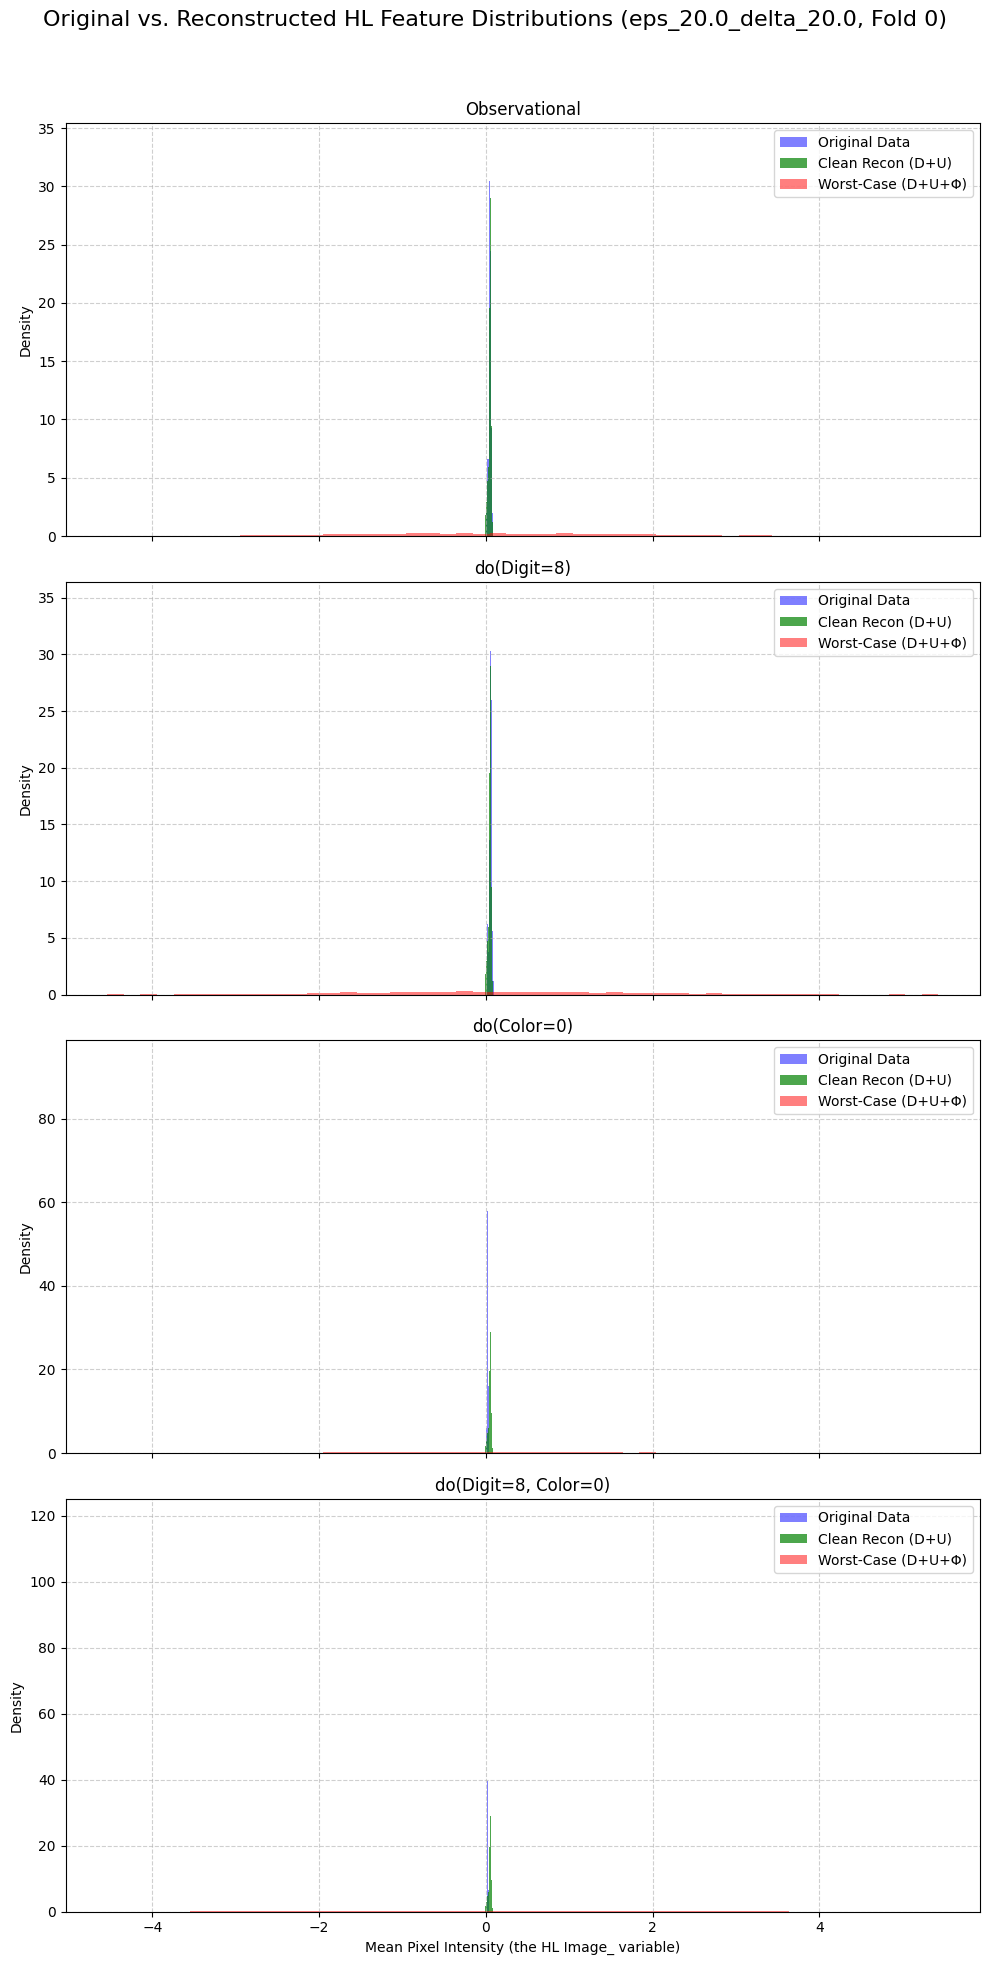


--- Statistics Comparison (Original vs. Clean Recon vs. Worst-Case) ---

Observational:
  Original Data    : Mean=+0.0473, Std=0.0164
  Clean Recon (D+U): Mean=+0.0469, Std=0.0174 (vs Orig: M diff -0.0004, Std diff +0.0010)
  Worst-Case(D+U+Φ): Mean=+0.0942, Std=1.6101
    => Adversary Shift (Worst - Clean Recon): Mean Shift +0.0472, Std Change +1.5927

do(Digit=8):
  Original Data    : Mean=+0.0553, Std=0.0162
  Clean Recon (D+U): Mean=+0.0469, Std=0.0174 (vs Orig: M diff -0.0084, Std diff +0.0012)
  Worst-Case(D+U+Φ): Mean=+0.0942, Std=1.6101
    => Adversary Shift (Worst - Clean Recon): Mean Shift +0.0472, Std Change +1.5927

do(Color=0):
  Original Data    : Mean=+0.0208, Std=0.0054
  Clean Recon (D+U): Mean=+0.0469, Std=0.0174 (vs Orig: M diff +0.0262, Std diff +0.0120)
  Worst-Case(D+U+Φ): Mean=+0.0942, Std=1.6101
    => Adversary Shift (Worst - Clean Recon): Mean Shift +0.0472, Std Change +1.5927

do(Digit=8, Color=0):
  Original Data    : Mean=+0.0240, Std=0.0044
  Clean Recon

In [127]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import re

# --- Assume these are defined/loaded: ---
# cv_folds, omega, Dll_samples, Dhl_samples
# det_ll_dict, det_hl_dict, U_ll_hat, U_hl_hat
# all_results_diroca (FROM THE DIROCA TRAINING CELL)
# D_HL, C_HL
# ---------------------------------------------

print("\n" + "="*20 + " Plotting HL Distributions (Original vs. Recon vs. Worst) " + "="*20)

# --- 1. Select DiRoCA Run and Fold ---
fold_to_show = 0
fold_key = f'fold_{fold_to_show}'

# --- FIX: Read from all_results_diroca ---
if 'all_results_diroca' not in locals() or not all_results_diroca:
    print("Error: No DiRoCA results found in 'all_results_diroca'. Please run the DiRoCA training cell first.")
else:
    # Find the first DiRoCA run key (e.g., 'eps_20.0_delta_20.0')
    diroca_key_toplevel = next((k for k in all_results_diroca if k.startswith('eps_')), None)

    if diroca_key_toplevel is None:
        print("Error: No valid run key (e.g., 'eps_...') found in 'all_results_diroca'.")
    else:
        print(f"Attempting to access results using key: {diroca_key_toplevel}")
        
        # --- Corrected Access Path ---
        # The key *is* the run key, e.g., 'eps_20.0_delta_20.0'
        # The data structure is {radius_key: {'diroca': {fold_key: ...}}}
        diroca_run_key_internal = diroca_key_toplevel # e.g., 'eps_20.0_delta_20.0'

        if ('diroca' not in all_results_diroca[diroca_key_toplevel] or
                fold_key not in all_results_diroca[diroca_key_toplevel]['diroca'] or
                diroca_run_key_internal not in all_results_diroca[diroca_key_toplevel]['diroca'][fold_key]):
            print(f"Error: Could not find valid DiRoCA results structure for {diroca_key_toplevel} / {fold_key} / {diroca_run_key_internal}")
            run_result = None
        else:
            run_result = all_results_diroca[diroca_key_toplevel]['diroca'][fold_key][diroca_run_key_internal]
            print(f"Using DiRoCA run: {diroca_key_toplevel}")
            if 'error' in run_result:
                print(f"Error recorded in selected DiRoCA run: {run_result['error']}. Cannot plot.")
                run_result = None

        # --- Check if run_result is valid before proceeding ---
        if run_result is not None:
            # --- Ensure final_Phi_hl is a tensor ---
            final_Phi_hl = run_result['final_Phi_hl']
            if not isinstance(final_Phi_hl, torch.Tensor):
                 final_Phi_hl = torch.tensor(final_Phi_hl, dtype=torch.float32)

            train_indices = cv_folds[fold_to_show]['train']
            U_hl_train = U_hl_hat[train_indices] # Shape (N_train, 1)
            det_hl_train_dict = {k: v[train_indices] for k, v in det_hl_dict.items()} # Use full det_hl_dict

            # --- 1a. Find intervention objects ---
            eta_do_digit_8 = None; eta_do_color_0 = None; eta_do_digit_8_color_0 = None
            for eta_key in det_hl_dict.keys():
                 if eta_key is not None and hasattr(eta_key, 'vv'):
                     iv_dict = eta_key.vv()
                     if iv_dict == {D_HL: 8}: eta_do_digit_8 = eta_key
                     elif iv_dict == {C_HL: 0}: eta_do_color_0 = eta_key
                     elif iv_dict == {D_HL: 8, C_HL: 0}: eta_do_digit_8_color_0 = eta_key

            if None in [eta_do_digit_8, eta_do_color_0, eta_do_digit_8_color_0]:
                 print("Warning: Could not find all required intervention objects in det_hl_dict keys.")
            else:
                # --- 2. Calculate Values ---
                hl_feature_values = {}
                interventions_to_plot = {
                    "Observational": None, "do(Digit=8)": eta_do_digit_8,
                    "do(Color=0)": eta_do_color_0, "do(Digit=8, Color=0)": eta_do_digit_8_color_0
                }
                print("Calculating feature values...")
                for name, eta_key in tqdm(interventions_to_plot.items()):
                    if eta_key not in det_hl_train_dict or eta_key not in Dhl_samples:
                        print(f"Skipping {name}: Key {eta_key} missing in data.")
                        continue
                    det_hl_full = det_hl_train_dict[eta_key]
                    det_hl_feature = det_hl_full[:, 20:]
                    original_hl_full = Dhl_samples[eta_key][train_indices]
                    original_hl_feature = original_hl_full[:, 20:]
                    device = det_hl_feature.device
                    U_hl_train_dev = U_hl_train.to(device)
                    final_Phi_hl_dev = final_Phi_hl.to(device)
                    clean_feature = det_hl_feature + U_hl_train_dev
                    worst_case_feature = det_hl_feature + U_hl_train_dev + final_Phi_hl_dev
                    hl_feature_values[name] = {
                        'original': original_hl_feature.cpu().numpy().flatten(),
                        'clean_recon': clean_feature.cpu().numpy().flatten(),
                        'worst_recon': worst_case_feature.cpu().numpy().flatten()
                    }

                # --- 3. Plot Histograms ---
                if not hl_feature_values: print("No values calculated.")
                else:
                    print("Generating comparison plots...")
                    num_valid_plots = len(hl_feature_values)
                    fig, axes = plt.subplots(num_valid_plots, 1, figsize=(10, 5 * num_valid_plots), sharex=True)
                    if num_valid_plots == 1: axes = [axes]
                    fig.suptitle(f'Original vs. Reconstructed HL Feature Distributions ({diroca_key_toplevel}, Fold {fold_to_show})', fontsize=16, y=1.01)
                    plot_idx = 0
                    for name, values in hl_feature_values.items():
                        ax = axes[plot_idx]
                        ax.hist(values['original'], bins=50, alpha=0.5, label='Original Data', density=True, color='blue')
                        ax.hist(values['clean_recon'], bins=50, alpha=0.7, label='Clean Recon (D+U)', density=True, color='green')
                        ax.hist(values['worst_recon'], bins=50, alpha=0.5, label='Worst-Case (D+U+Φ)', density=True, color='red')
                        ax.set_title(name)
                        ax.set_ylabel('Density')
                        ax.legend()
                        ax.grid(True, linestyle='--', alpha=0.6)
                        plot_idx += 1
                    axes[-1].set_xlabel('Mean Pixel Intensity (the HL Image_ variable)')
                    plt.tight_layout(rect=[0, 0.03, 1, 0.99])
                    plt.show()

                    # --- 4. Print Statistics ---
                    print("\n--- Statistics Comparison (Original vs. Clean Recon vs. Worst-Case) ---")
                    for name, values in hl_feature_values.items():
                        print(f"\n{name}:")
                        mean_orig, std_orig = np.mean(values['original']), np.std(values['original'])
                        mean_clean, std_clean = np.mean(values['clean_recon']), np.std(values['clean_recon'])
                        mean_worst, std_worst = np.mean(values['worst_recon']), np.std(values['worst_recon'])
                        print(f"  Original Data    : Mean={mean_orig:+.4f}, Std={std_orig:.4f}")
                        print(f"  Clean Recon (D+U): Mean={mean_clean:+.4f}, Std={std_clean:.4f} (vs Orig: M diff {mean_clean-mean_orig:+.4f}, Std diff {std_clean-std_orig:+.4f})")
                        print(f"  Worst-Case(D+U+Φ): Mean={mean_worst:+.4f}, Std={std_worst:.4f}")
                        print(f"    => Adversary Shift (Worst - Clean Recon): Mean Shift {mean_worst-mean_clean:+.4f}, Std Change {std_worst-std_clean:+.4f}")


==================== Visualizing Adversarial Perturbations (Side-by-Side Comparison) ====================
Attempting to access results using key: eps_20.0_delta_20.0
Using DiRoCA run: eps_20.0_delta_20.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7695334..1.355745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0665737..1.0361935].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8946503..1.2686106].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3314654..1.1297588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71547973..1.2055749].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.06995..1.1091404].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.93063843

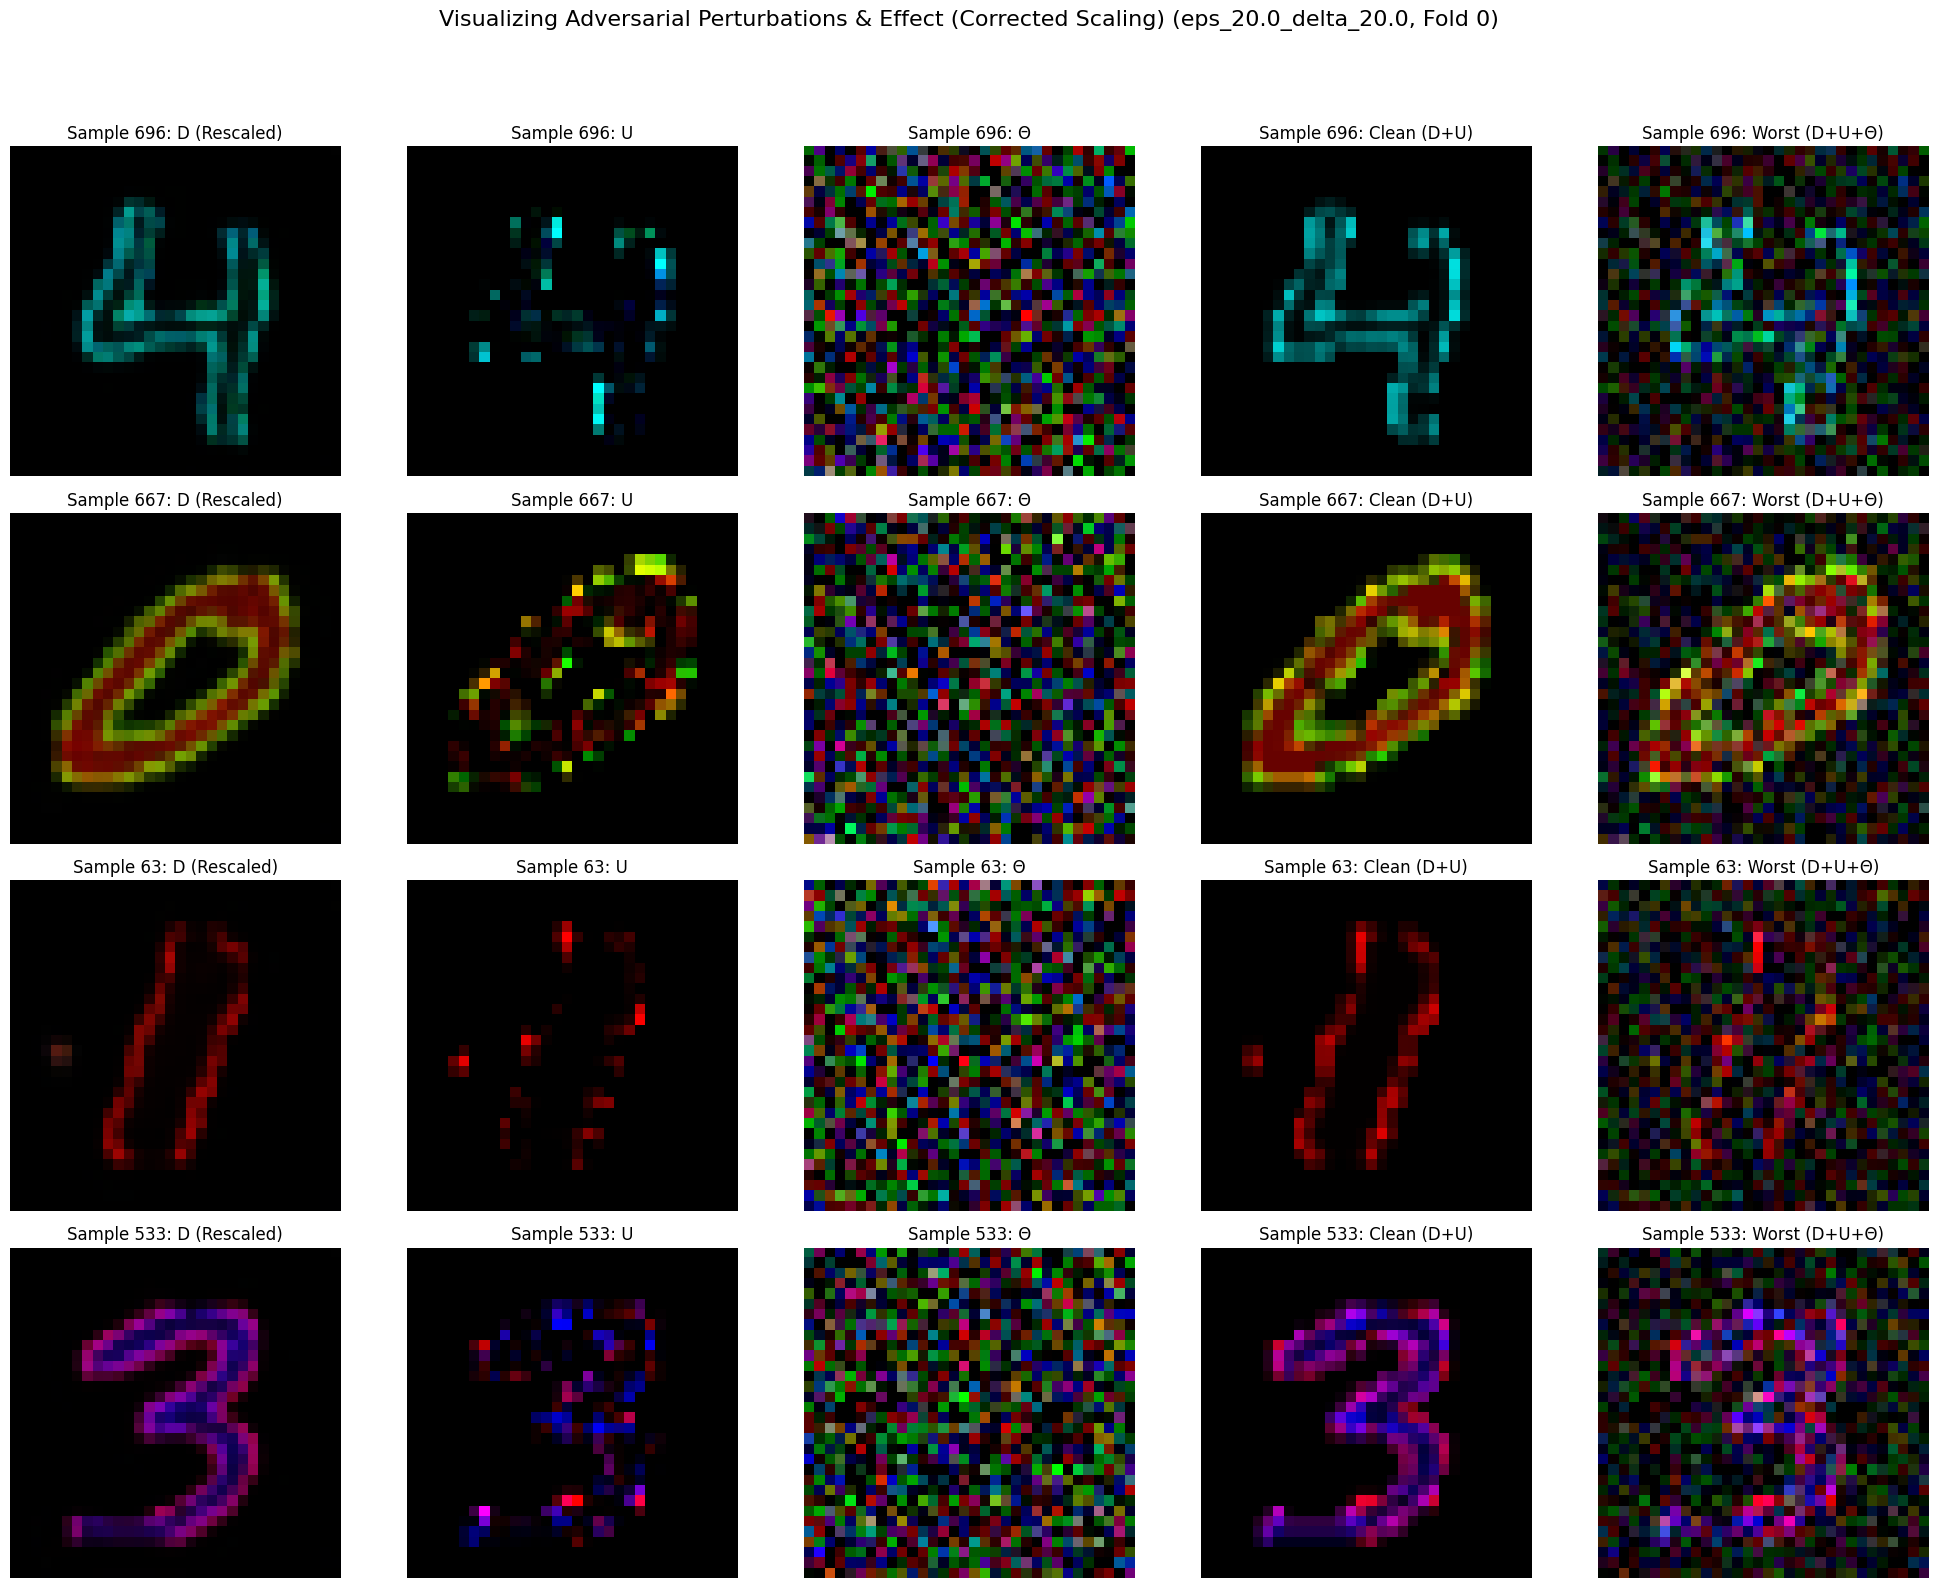


--- Perturbation Analysis (eps_20.0_delta_20.0) ---
  Final Total Frobenius Norm of Theta_ll: 565.685
  Max Allowed Total Frobenius Norm (sqrt(N)*ε): 565.685
  Average Frobenius Norm per Sample: 19.990
  Max Frobenius Norm for a single sample: 22.403


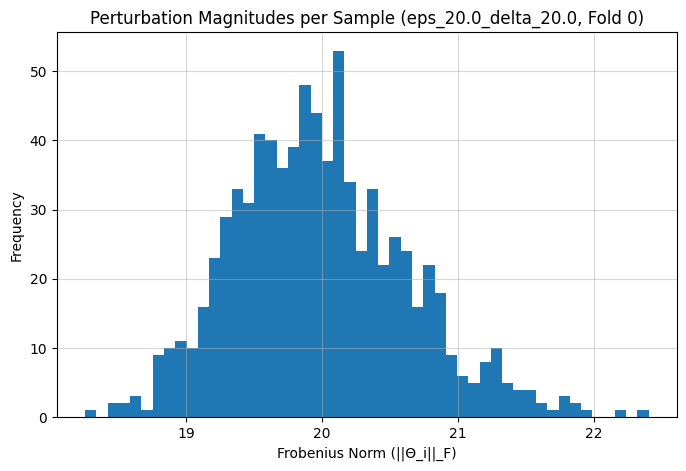

In [128]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import re

# --- Assume these are defined/loaded: ---
# cv_folds, U_ll_hat, det_ll_dict
# all_results_diroca (FROM THE DIROCA TRAINING CELL)
# ---------------------------------------------

print("\n" + "="*20 + " Visualizing Adversarial Perturbations (Side-by-Side Comparison) " + "="*20)

# --- 1. Select a Specific Result to Visualize ---
fold_key_to_show = 'fold_0'
# --- FIX: Read from all_results_diroca ---
if 'all_results_diroca' not in locals() or not all_results_diroca:
    print("Error: No DiRoCA results found in 'all_results_diroca'. Please run the DiRoCA training cell first.")
else:
    # Find the first DiRoCA run key (e.g., 'eps_20.0_delta_20.0')
    diroca_key_toplevel = next((k for k in all_results_diroca if k.startswith('eps_')), None)
    
    if diroca_key_toplevel is None:
        print("Error: No valid run key (e.g., 'eps_...') found in 'all_results_diroca'.")
    else:
        print(f"Attempting to access results using key: {diroca_key_toplevel}")
        
        # --- Corrected Access Path ---
        diroca_run_key_internal = diroca_key_toplevel # Key is the same
        
        if ('diroca' not in all_results_diroca[diroca_key_toplevel] or
                fold_key_to_show not in all_results_diroca[diroca_key_toplevel]['diroca'] or
                diroca_run_key_internal not in all_results_diroca[diroca_key_toplevel]['diroca'][fold_key_to_show]):
            print(f"Error: Could not find valid DiRoCA results structure for {diroca_key_toplevel} / {fold_key_to_show} / {diroca_run_key_internal}")
            run_result = None
        else:
            run_result = all_results_diroca[diroca_key_toplevel]['diroca'][fold_key_to_show][diroca_run_key_internal]
            print(f"Using DiRoCA run: {diroca_key_toplevel}")
            if 'error' in run_result:
                print(f"Error recorded in selected DiRoCA run: {run_result['error']}. Cannot visualize.")
                run_result = None

    # --- Check if run_result is valid before proceeding ---
    if run_result is not None:
        # --- 2. Extract Necessary Data ---
        final_Theta_ll = run_result.get('final_Theta_ll')
        if final_Theta_ll is None:
             print("  Skipping - 'final_Theta_ll' not found in results.")
        else:
            if not isinstance(final_Theta_ll, torch.Tensor): final_Theta_ll = torch.tensor(final_Theta_ll, dtype=torch.float32)
            epsilon_run = run_result['epsilon']
            fold_index = int(fold_key_to_show.split('_')[-1])
            train_indices = cv_folds[fold_index]['train']

            # Use U_ll_hat (original image shape) and U_ll_hat_fixed (flattened)
            U_ll_train_img = U_ll_hat[train_indices]
            U_ll_train_flat = U_ll_hat_fixed[train_indices] # Use the flattened version
            
            det_ll_train_obs = det_ll_dict[None][train_indices]

            # --- 3. Calculate Images ---
            det_pixels_train = det_ll_train_obs[:, :3072] # D in [-1, 1] range
            clean_recon_pixels = det_pixels_train + U_ll_train_flat # D + U
            worst_case_pixels = clean_recon_pixels + final_Theta_ll # (D + U) + Theta

            # --- 4. Select Samples and Reshape Function ---
            num_samples_to_show = 4
            N_train = U_ll_train_flat.shape[0]
            if num_samples_to_show > N_train: num_samples_to_show = N_train
            np.random.seed(fold_index + 42) # Use fixed seed
            sample_indices = np.random.choice(N_train, num_samples_to_show, replace=False)

            def reshape_for_plot(pixel_vector):
                """Reshapes pixel vector (3072,) to (32, 32, 3) for plotting."""
                try:
                    if not isinstance(pixel_vector, torch.Tensor): pixel_vector = torch.tensor(pixel_vector)
                    pixel_vector = pixel_vector.cpu()
                    if pixel_vector.numel() != 3072: return np.zeros((32, 32, 3))
                    img_chw = pixel_vector.view(3, 32, 32)
                    img_hwc = img_chw.permute(1, 2, 0)
                    return img_hwc.numpy()
                except Exception as e: return np.zeros((32, 32, 3))

            def rescale_neg1_1_to_0_1(img_np_neg1_1):
                """Rescales numpy image from [-1, 1] to [0, 1] for imshow."""
                img_rescaled = (img_np_neg1_1 + 1.0) / 2.0
                return np.clip(img_rescaled, 0.0, 1.0)

            # --- 5. Plotting ---
            fig, axes = plt.subplots(num_samples_to_show, 5, figsize=(20, 4 * num_samples_to_show))
            if num_samples_to_show == 1: axes = np.array([axes])
            fig.suptitle(f'Visualizing Adversarial Perturbations & Effect (Corrected Scaling) ({diroca_key_toplevel}, Fold {fold_to_show})', fontsize=16, y=1.02)

            for i, idx in enumerate(sample_indices):
                # Col 1: Deterministic D (Rescaled)
                ax = axes[i, 0]; img_np = reshape_for_plot(det_pixels_train[idx]); ax.imshow(rescale_neg1_1_to_0_1(img_np)); ax.set_title(f'Sample {idx}: D (Rescaled)'); ax.axis('off')
                
                # Col 2: Abduced Noise U (Diverging)
                ax = axes[i, 1]; img_np = reshape_for_plot(U_ll_train_flat[idx]); norm = np.max(np.abs(img_np)) if img_np.size > 0 else 0.1; ax.imshow(img_np, cmap='RdBu_r', vmin=-norm-1e-6, vmax=norm+1e-6); ax.set_title(f'Sample {idx}: U'); ax.axis('off')
                
                # Col 3: Adversary Theta (Diverging)
                ax = axes[i, 2]; img_np = reshape_for_plot(final_Theta_ll[idx]); norm = np.max(np.abs(img_np)) if img_np.size > 0 else 0.1; im = ax.imshow(img_np, cmap='RdBu_r', vmin=-norm-1e-6, vmax=norm+1e-6); ax.set_title(f'Sample {idx}: Θ'); ax.axis('off')

                # Col 4: Clean Reconstructed D+U (Rescaled)
                ax = axes[i, 3]; img_np = reshape_for_plot(clean_recon_pixels[idx]); ax.imshow(rescale_neg1_1_to_0_1(img_np)); ax.set_title(f'Sample {idx}: Clean (D+U)'); ax.axis('off')
                
                # Col 5: Worst-Case D+U+Theta (Rescaled)
                ax = axes[i, 4]; img_np = reshape_for_plot(worst_case_pixels[idx]); ax.imshow(rescale_neg1_1_to_0_1(img_np)); ax.set_title(f'Sample {idx}: Worst (D+U+Θ)'); ax.axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.98])
            plt.show()

            # --- Optional: Analyze Perturbation Magnitude ---
            final_Theta_ll_tensor = final_Theta_ll.cpu()
            theta_norms = torch.norm(final_Theta_ll_tensor, p='fro', dim=1)
            print(f"\n--- Perturbation Analysis ({diroca_key_toplevel}) ---")
            projected_total_frob_norm = torch.norm(final_Theta_ll_tensor, p='fro')
            max_allowed_frob_norm = epsilon_run * np.sqrt(N_train) if epsilon_run > 0 else 0
            print(f"  Final Total Frobenius Norm of Theta_ll: {projected_total_frob_norm:.3f}")
            print(f"  Max Allowed Total Frobenius Norm (sqrt(N)*ε): {max_allowed_frob_norm:.3f}")
            print(f"  Average Frobenius Norm per Sample: {theta_norms.mean():.3f}")
            print(f"  Max Frobenius Norm for a single sample: {theta_norms.max():.3f}")

            plt.figure(figsize=(8, 5))
            plt.hist(theta_norms.numpy(), bins=50)
            plt.title(f"Perturbation Magnitudes per Sample ({diroca_key_toplevel}, Fold {fold_to_show})")
            plt.xlabel("Frobenius Norm (||Θ_i||_F)")
            plt.ylabel("Frequency")
            plt.grid(True, alpha=0.5)
            plt.show()


==================== Plotting HL Distributions (Original vs. Recon vs. Worst) ====================
Attempting to access results using key: eps_20.0_delta_20.0
Using DiRoCA run: eps_20.0_delta_20.0
Calculating feature values...


100%|██████████| 4/4 [00:00<00:00, 1413.89it/s]

Generating comparison plots...


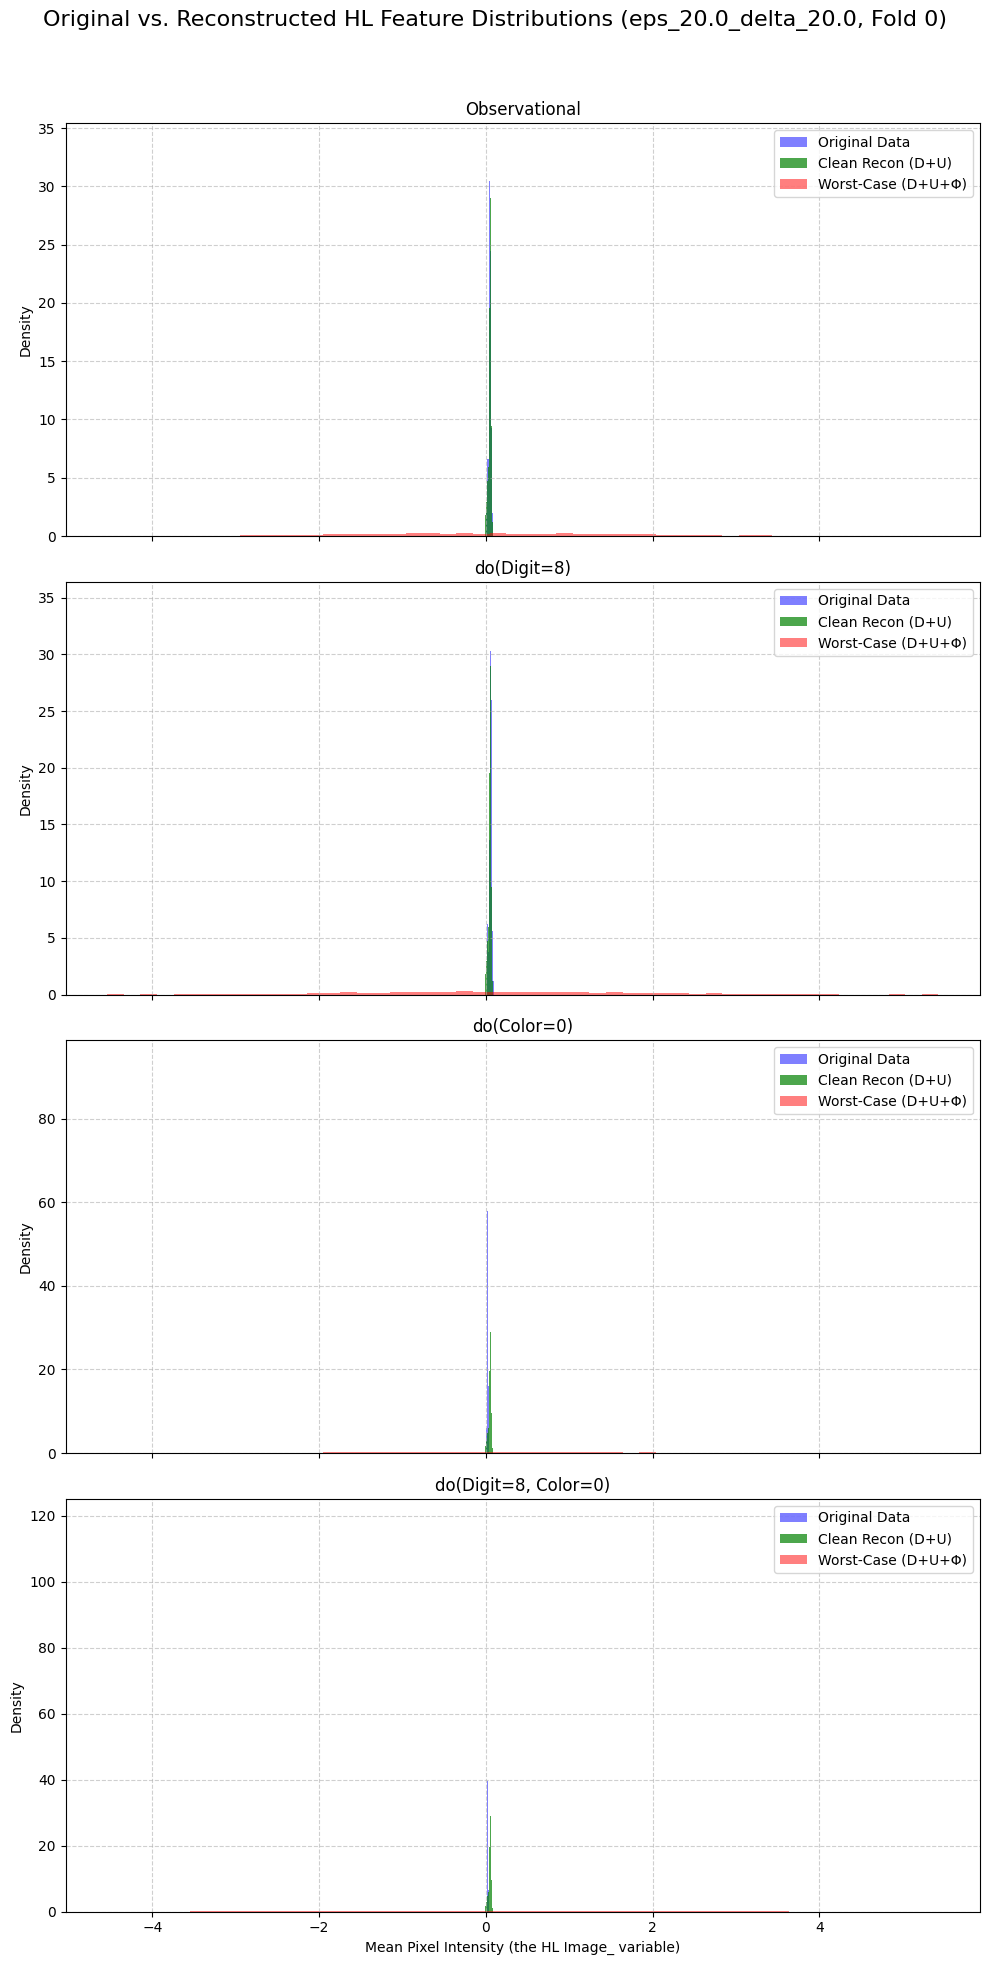


--- Statistics Comparison (Original vs. Clean Recon vs. Worst-Case) ---

Observational:
  Original Data    : Mean=+0.0473, Std=0.0164
  Clean Recon (D+U): Mean=+0.0469, Std=0.0174 (vs Orig: M diff -0.0004, Std diff +0.0010)
  Worst-Case(D+U+Φ): Mean=+0.0942, Std=1.6101
    => Adversary Shift (Worst - Clean Recon): Mean Shift +0.0472, Std Change +1.5927

do(Digit=8):
  Original Data    : Mean=+0.0553, Std=0.0162
  Clean Recon (D+U): Mean=+0.0469, Std=0.0174 (vs Orig: M diff -0.0084, Std diff +0.0012)
  Worst-Case(D+U+Φ): Mean=+0.0942, Std=1.6101
    => Adversary Shift (Worst - Clean Recon): Mean Shift +0.0472, Std Change +1.5927

do(Color=0):
  Original Data    : Mean=+0.0208, Std=0.0054
  Clean Recon (D+U): Mean=+0.0469, Std=0.0174 (vs Orig: M diff +0.0262, Std diff +0.0120)
  Worst-Case(D+U+Φ): Mean=+0.0942, Std=1.6101
    => Adversary Shift (Worst - Clean Recon): Mean Shift +0.0472, Std Change +1.5927

do(Digit=8, Color=0):
  Original Data    : Mean=+0.0240, Std=0.0044
  Clean Recon

In [129]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import re

# --- Assume these are defined/loaded: ---
# cv_folds, omega, Dll_samples, Dhl_samples
# det_ll_dict, det_hl_dict, U_ll_hat, U_hl_hat
# all_results_diroca (FROM THE DIROCA TRAINING CELL)
# D_HL, C_HL (defined previously, e.g., D_HL='Digit_', C_HL='Color_')
# ---------------------------------------------

print("\n" + "="*20 + " Plotting HL Distributions (Original vs. Recon vs. Worst) " + "="*20)

# --- 1. Select DiRoCA Run and Fold ---
fold_to_show = 0
fold_key = f'fold_{fold_to_show}'
# Find the first DiRoCA run key (e.g., 'eps_20.0_delta_20.0')
diroca_key_toplevel = next((k for k in all_results_diroca if k.startswith('eps_')), None)

if diroca_key_toplevel is None:
    print("Error: No DiRoCA results found in 'all_results_diroca'. Please run the DiRoCA training cell first.")
else:
    print(f"Attempting to access results using key: {diroca_key_toplevel}")
    # Extract epsilon/delta from key to form internal key
    match = re.search(r'eps_([\d.]+)_delta_([\d.]+)', diroca_key_toplevel)
    if not match:
        print(f"Error: Could not parse epsilon/delta from key '{diroca_key_toplevel}'.")
        run_result = None
    else:
        epsilon = float(match.group(1)); delta = float(match.group(2))
        diroca_run_key_internal = f'eps_{epsilon}_delta_{delta}'

        # --- Corrected Access Path ---
        # Structure: all_results_diroca[radius_key]['diroca'][fold_key][run_key]
        if ('diroca' not in all_results_diroca[diroca_key_toplevel] or
                fold_key not in all_results_diroca[diroca_key_toplevel]['diroca'] or
                diroca_run_key_internal not in all_results_diroca[diroca_key_toplevel]['diroca'][fold_key]):
            print(f"Error: Could not find valid DiRoCA results structure for {diroca_key_toplevel} / {fold_key} / {diroca_run_key_internal}")
            run_result = None
        else:
            run_result = all_results_diroca[diroca_key_toplevel]['diroca'][fold_key][diroca_run_key_internal]
            print(f"Using DiRoCA run: {diroca_key_toplevel}")
            if 'error' in run_result:
                print(f"Error recorded in selected DiRoCA run: {run_result['error']}. Cannot plot.")
                run_result = None

    # --- Check if run_result is valid before proceeding ---
    if run_result is not None:
        # --- Ensure final_Phi_hl is a tensor ---
        final_Phi_hl = run_result['final_Phi_hl']
        if not isinstance(final_Phi_hl, torch.Tensor):
             final_Phi_hl = torch.tensor(final_Phi_hl, dtype=torch.float32)

        train_indices = cv_folds[fold_to_show]['train']
        U_hl_train = U_hl_hat[train_indices] # Shape (N_train, 1)
        det_hl_train_dict = {k: v[train_indices] for k, v in det_hl_dict.items()} # Use full det_hl_dict

        # --- 1a. Find intervention objects ---
        eta_do_digit_8 = None; eta_do_color_0 = None; eta_do_digit_8_color_0 = None
        for eta_key in det_hl_dict.keys():
             if eta_key is not None and hasattr(eta_key, 'vv'):
                 iv_dict = eta_key.vv()
                 if iv_dict == {D_HL: 8}: eta_do_digit_8 = eta_key
                 elif iv_dict == {C_HL: 0}: eta_do_color_0 = eta_key
                 elif iv_dict == {D_HL: 8, C_HL: 0}: eta_do_digit_8_color_0 = eta_key

        if None in [eta_do_digit_8, eta_do_color_0, eta_do_digit_8_color_0]:
             print("Warning: Could not find all required intervention objects in det_hl_dict keys.")
        else:
            # --- 2. Calculate Values ---
            hl_feature_values = {}
            interventions_to_plot = {
                "Observational": None, "do(Digit=8)": eta_do_digit_8,
                "do(Color=0)": eta_do_color_0, "do(Digit=8, Color=0)": eta_do_digit_8_color_0
            }
            print("Calculating feature values...")
            for name, eta_key in tqdm(interventions_to_plot.items()):
                if eta_key not in det_hl_train_dict or eta_key not in Dhl_samples:
                    print(f"Skipping {name}: Key {eta_key} missing in data.")
                    continue
                det_hl_full = det_hl_train_dict[eta_key]
                det_hl_feature = det_hl_full[:, 20:]
                original_hl_full = Dhl_samples[eta_key][train_indices]
                original_hl_feature = original_hl_full[:, 20:]
                device = det_hl_feature.device
                U_hl_train_dev = U_hl_train.to(device)
                final_Phi_hl_dev = final_Phi_hl.to(device)
                clean_feature = det_hl_feature + U_hl_train_dev
                worst_case_feature = det_hl_feature + U_hl_train_dev + final_Phi_hl_dev
                hl_feature_values[name] = {
                    'original': original_hl_feature.cpu().numpy().flatten(),
                    'clean_recon': clean_feature.cpu().numpy().flatten(),
                    'worst_recon': worst_case_feature.cpu().numpy().flatten()
                }

            # --- 3. Plot Histograms ---
            if not hl_feature_values: print("No values calculated.")
            else:
                print("Generating comparison plots...")
                num_valid_plots = len(hl_feature_values)
                fig, axes = plt.subplots(num_valid_plots, 1, figsize=(10, 5 * num_valid_plots), sharex=True)
                if num_valid_plots == 1: axes = [axes]
                fig.suptitle(f'Original vs. Reconstructed HL Feature Distributions ({diroca_key_toplevel}, Fold {fold_to_show})', fontsize=16, y=1.01)
                plot_idx = 0
                for name, values in hl_feature_values.items():
                    ax = axes[plot_idx]
                    ax.hist(values['original'], bins=50, alpha=0.5, label='Original Data', density=True, color='blue')
                    ax.hist(values['clean_recon'], bins=50, alpha=0.7, label='Clean Recon (D+U)', density=True, color='green')
                    ax.hist(values['worst_recon'], bins=50, alpha=0.5, label='Worst-Case (D+U+Φ)', density=True, color='red')
                    ax.set_title(name)
                    ax.set_ylabel('Density')
                    ax.legend()
                    ax.grid(True, linestyle='--', alpha=0.6)
                    plot_idx += 1
                axes[-1].set_xlabel('Mean Pixel Intensity (the HL Image_ variable)')
                plt.tight_layout(rect=[0, 0.03, 1, 0.99])
                plt.show()

                # --- 4. Print Statistics ---
                print("\n--- Statistics Comparison (Original vs. Clean Recon vs. Worst-Case) ---")
                for name, values in hl_feature_values.items():
                    print(f"\n{name}:")
                    mean_orig, std_orig = np.mean(values['original']), np.std(values['original'])
                    mean_clean, std_clean = np.mean(values['clean_recon']), np.std(values['clean_recon'])
                    mean_worst, std_worst = np.mean(values['worst_recon']), np.std(values['worst_recon'])
                    print(f"  Original Data    : Mean={mean_orig:+.4f}, Std={std_orig:.4f}")
                    print(f"  Clean Recon (D+U): Mean={mean_clean:+.4f}, Std={std_clean:.4f} (vs Orig: M diff {mean_clean-mean_orig:+.4f}, Std diff {std_clean-std_orig:+.4f})")
                    print(f"  Worst-Case(D+U+Φ): Mean={mean_worst:+.4f}, Std={std_worst:.4f}")
                    print(f"    => Adversary Shift (Worst - Clean Recon): Mean Shift {mean_worst-mean_clean:+.4f}, Std Change {std_worst-std_clean:+.4f}")


==================== Visualizing Adversarial Perturbations (Side-by-Side Comparison) ====================
Attempting to access results using key: eps_20.0_delta_20.0
Using DiRoCA run: eps_20.0_delta_20.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7695334..1.355745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0665737..1.0361935].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8946503..1.2686106].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3314654..1.1297588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71547973..1.2055749].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.06995..1.1091404].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.93063843

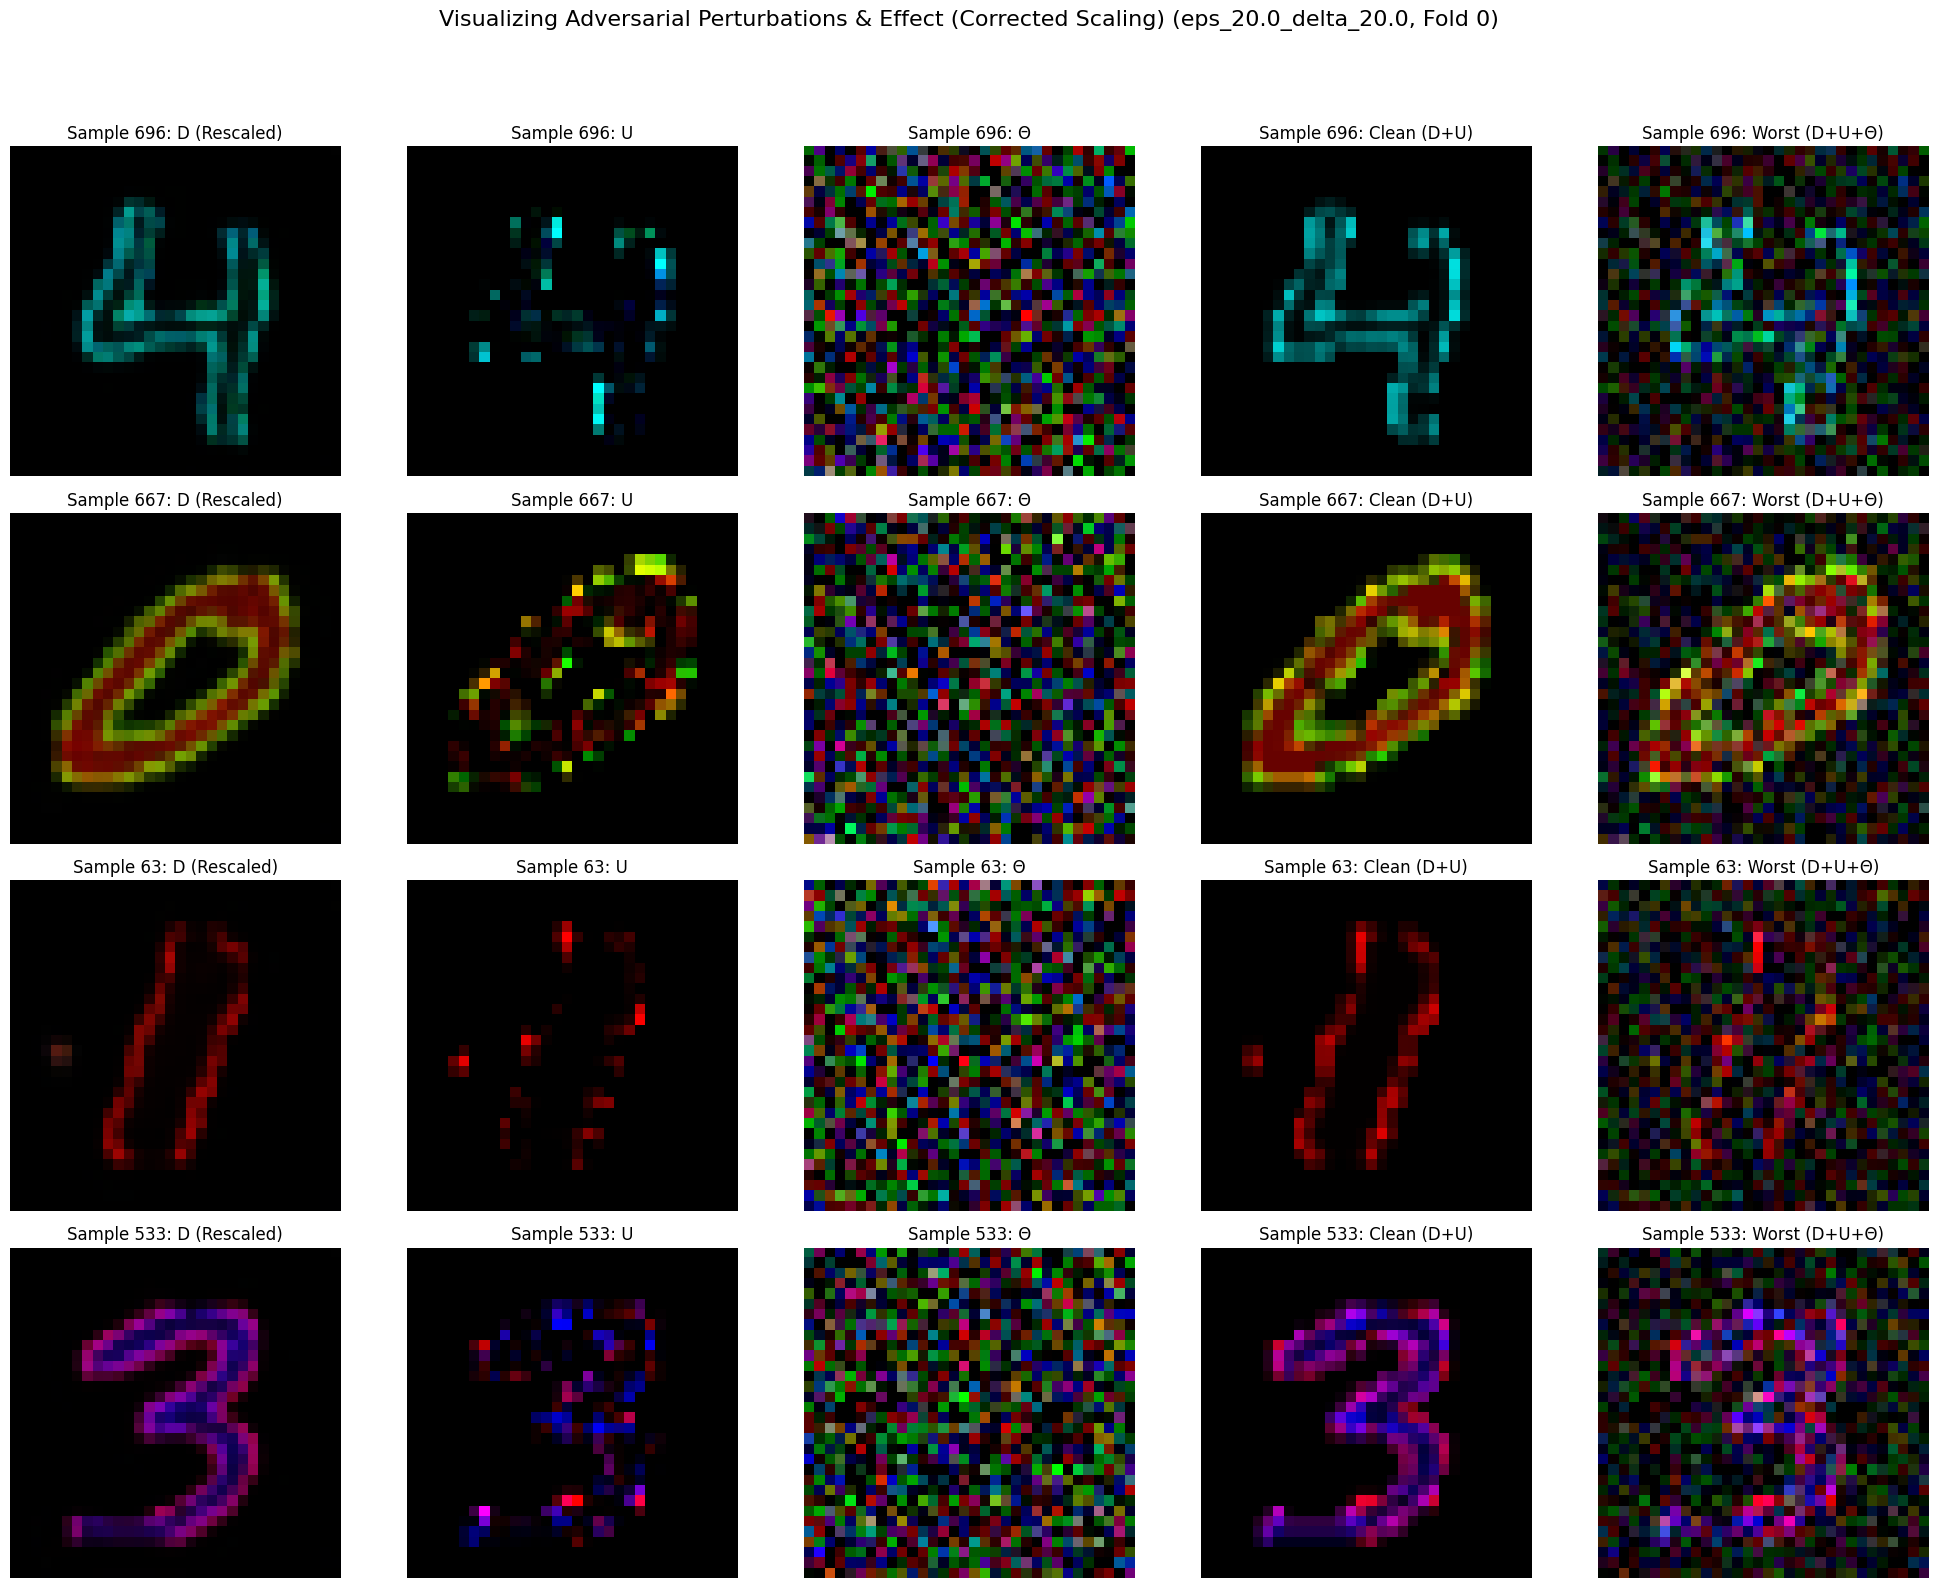


--- Perturbation Analysis (eps_20.0_delta_20.0) ---
  Final Total Frobenius Norm of Theta_ll: 565.685
  Max Allowed Total Frobenius Norm (sqrt(N)*ε): 565.685
  Average Frobenius Norm per Sample: 19.990
  Max Frobenius Norm for a single sample: 22.403


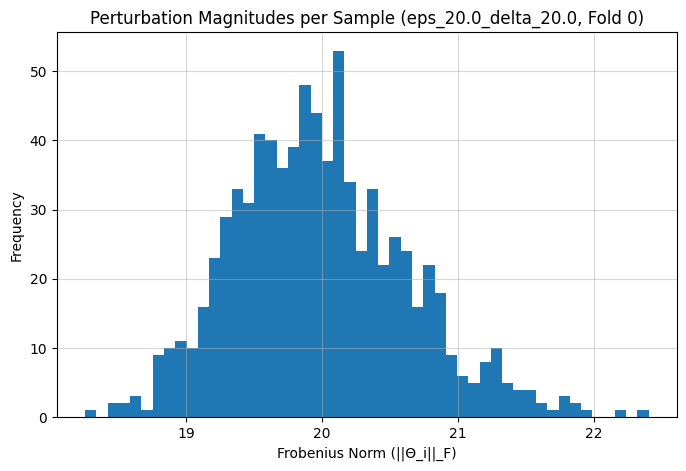

In [130]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import re

# --- Assume these are defined/loaded: ---
# cv_folds, U_ll_hat, U_ll_hat_fixed, det_ll_dict
# all_results_diroca (FROM THE DIROCA TRAINING CELL)
# ---------------------------------------------

print("\n" + "="*20 + " Visualizing Adversarial Perturbations (Side-by-Side Comparison) " + "="*20)

# --- 1. Select a Specific Result to Visualize ---
fold_key_to_show = 'fold_0'
# Find the first DiRoCA run key (e.g., 'eps_20.0_delta_20.0')
diroca_key_toplevel = next((k for k in all_results_diroca if k.startswith('eps_')), None)

if diroca_key_toplevel is None:
    print("Error: No DiRoCA results found in 'all_results_diroca'. Cannot visualize.")
else:
    print(f"Attempting to access results using key: {diroca_key_toplevel}")
    # Extract epsilon/delta from key to form internal key
    match = re.search(r'eps_([\d.]+)_delta_([\d.]+)', diroca_key_toplevel)
    if not match:
        print(f"Error: Could not parse epsilon/delta from key '{diroca_key_toplevel}'.")
        run_result = None
    else:
        epsilon = float(match.group(1)); delta = float(match.group(2))
        diroca_run_key_internal = f'eps_{epsilon}_delta_{delta}'
        
        # --- Corrected Access Path ---
        if ('diroca' not in all_results_diroca[diroca_key_toplevel] or
                fold_key_to_show not in all_results_diroca[diroca_key_toplevel]['diroca'] or
                diroca_run_key_internal not in all_results_diroca[diroca_key_toplevel]['diroca'][fold_key_to_show]):
            print(f"Error: Could not find valid DiRoCA results structure.")
            run_result = None
        else:
            run_result = all_results_diroca[diroca_key_toplevel]['diroca'][fold_key_to_show][diroca_run_key_internal]
            print(f"Using DiRoCA run: {diroca_key_toplevel}")
            if 'error' in run_result:
                print(f"Error recorded in selected DiRoCA run: {run_result['error']}. Cannot visualize.")
                run_result = None

    if run_result is not None:
        # --- 2. Extract Necessary Data ---
        final_Theta_ll = run_result.get('final_Theta_ll')
        if final_Theta_ll is None:
             print("  Skipping - 'final_Theta_ll' not found in results.")
        else:
            if not isinstance(final_Theta_ll, torch.Tensor): final_Theta_ll = torch.tensor(final_Theta_ll, dtype=torch.float32)
            epsilon_run = run_result['epsilon']
            fold_index = int(fold_key_to_show.split('_')[-1])
            train_indices = cv_folds[fold_index]['train']

            # Use flattened noise
            U_ll_train_flat = U_ll_hat_fixed[train_indices] 
            
            det_ll_train_obs = det_ll_dict[None][train_indices]

            # --- 3. Calculate Images ---
            det_pixels_train = det_ll_train_obs[:, :3072] # D in [-1, 1] range
            clean_recon_pixels = det_pixels_train + U_ll_train_flat # D + U
            worst_case_pixels = clean_recon_pixels + final_Theta_ll # (D + U) + Theta

            # --- 4. Select Samples and Reshape Function ---
            num_samples_to_show = 4
            N_train = U_ll_train_flat.shape[0]
            if num_samples_to_show > N_train: num_samples_to_show = N_train
            np.random.seed(fold_index + 42) # Use fixed seed
            sample_indices = np.random.choice(N_train, num_samples_to_show, replace=False)

            def reshape_for_plot(pixel_vector):
                """Reshapes pixel vector (3072,) to (32, 32, 3) for plotting."""
                try:
                    if not isinstance(pixel_vector, torch.Tensor): pixel_vector = torch.tensor(pixel_vector)
                    pixel_vector = pixel_vector.cpu()
                    if pixel_vector.numel() != 3072: return np.zeros((32, 32, 3))
                    img_chw = pixel_vector.view(3, 32, 32)
                    img_hwc = img_chw.permute(1, 2, 0)
                    return img_hwc.numpy()
                except Exception as e: return np.zeros((32, 32, 3))

            def rescale_neg1_1_to_0_1(img_np_neg1_1):
                """Rescales numpy image from [-1, 1] to [0, 1] for imshow."""
                img_rescaled = (img_np_neg1_1 + 1.0) / 2.0
                return np.clip(img_rescaled, 0.0, 1.0)

            # --- 5. Plotting ---
            fig, axes = plt.subplots(num_samples_to_show, 5, figsize=(20, 4 * num_samples_to_show))
            if num_samples_to_show == 1: axes = np.array([axes])
            fig.suptitle(f'Visualizing Adversarial Perturbations & Effect (Corrected Scaling) ({diroca_key_toplevel}, Fold {fold_to_show})', fontsize=16, y=1.02)

            for i, idx in enumerate(sample_indices):
                # Col 1: Deterministic D (Rescaled)
                ax = axes[i, 0]; img_np = reshape_for_plot(det_pixels_train[idx]); ax.imshow(rescale_neg1_1_to_0_1(img_np)); ax.set_title(f'Sample {idx}: D (Rescaled)'); ax.axis('off')
                
                # Col 2: Abduced Noise U (Diverging)
                ax = axes[i, 1]; img_np = reshape_for_plot(U_ll_train_flat[idx]); norm = np.max(np.abs(img_np)) if img_np.size > 0 else 0.1; ax.imshow(img_np, cmap='RdBu_r', vmin=-norm-1e-6, vmax=norm+1e-6); ax.set_title(f'Sample {idx}: U'); ax.axis('off')
                
                # Col 3: Adversary Theta (Diverging)
                ax = axes[i, 2]; img_np = reshape_for_plot(final_Theta_ll[idx]); norm_pert = np.max(np.abs(img_np)) if img_np.size > 0 else 0.1; im = ax.imshow(img_np, cmap='RdBu_r', vmin=-norm_pert-1e-6, vmax=norm_pert+1e-6); ax.set_title(f'Sample {idx}: Θ'); ax.axis('off')

                # Col 4: Clean Reconstructed D+U (Rescaled)
                ax = axes[i, 3]; img_np = reshape_for_plot(clean_recon_pixels[idx]); ax.imshow(rescale_neg1_1_to_0_1(img_np)); ax.set_title(f'Sample {idx}: Clean (D+U)'); ax.axis('off')
                
                # Col 5: Worst-Case D+U+Theta (Rescaled)
                ax = axes[i, 4]; img_np = reshape_for_plot(worst_case_pixels[idx]); ax.imshow(rescale_neg1_1_to_0_1(img_np)); ax.set_title(f'Sample {idx}: Worst (D+U+Θ)'); ax.axis('off')

            plt.tight_layout(rect=[0, 0.03, 1, 0.98])
            plt.show()

            # --- Optional: Analyze Perturbation Magnitude ---
            final_Theta_ll_tensor = final_Theta_ll.cpu()
            theta_norms = torch.norm(final_Theta_ll_tensor, p='fro', dim=1)
            print(f"\n--- Perturbation Analysis ({diroca_key_toplevel}) ---")
            projected_total_frob_norm = torch.norm(final_Theta_ll_tensor, p='fro')
            max_allowed_frob_norm = epsilon_run * np.sqrt(N_train) if epsilon_run > 0 else 0
            print(f"  Final Total Frobenius Norm of Theta_ll: {projected_total_frob_norm:.3f}")
            print(f"  Max Allowed Total Frobenius Norm (sqrt(N)*ε): {max_allowed_frob_norm:.3f}")
            print(f"  Average Frobenius Norm per Sample: {theta_norms.mean():.3f}")
            print(f"  Max Frobenius Norm for a single sample: {theta_norms.max():.3f}")

            plt.figure(figsize=(8, 5))
            plt.hist(theta_norms.numpy(), bins=50)
            plt.title(f"Perturbation Magnitudes per Sample ({diroca_key_toplevel}, Fold {fold_to_show})")
            plt.xlabel("Frobenius Norm (||Θ_i||_F)")
            plt.ylabel("Frequency")
            plt.grid(True, alpha=0.5)
            plt.show()